In [1]:
import os
import math
import gymnasium as gym  # Import gymnasium and alias it as gym for convenience
from gymnasium import spaces
from typing import Any, Dict
import numpy as np
import pandas as pd
import random
import geopandas as gpd
from shapely import geometry
from shapely.geometry import LineString, Point
from utils import *
from langchain_openai import ChatOpenAI
# Load the autoreload extension, which watches imports for changes
%load_ext autoreload 
# Automatically reload any module when its source file changes
%autoreload 2 
pd.set_option('display.max_columns', 100)
from haversine import haversine, Unit
import warnings
# Suppress all warning messages to keep output clean
warnings.filterwarnings('ignore') 
# Enable TensorBoard magic for live RL training metrics
%load_ext tensorboard

from datetime import datetime
import torch
import torch.nn as nn
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(0)
    torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [2]:
featurefile = pd.read_csv('featurefile_transformed_2.csv')
featurefile.head()

,Unnamed: 0,filenames,resolvedflight,flightstarttime_original_res,original_resstart_lat,original_resstart_lon,original_resend_lat,distfrombound_TCP,original_resend_lon,resflight_offset,flightstarttime_original_unres,original_unresstart_lat,original_unresstart_lon,original_unresend_lat,original_unresend_lon,unresflight_offset,initialhead_resolved,initialhead_unresolved,conflict_angle,mantoconflict_dunres,mantoconflict_dres,tcp_direction,unrsolvedflight_dirn,d_bound_manstart,d_bound_CPA,neighbouring_ac,meandistance,timetoresolution,d_resstart_CPA,headingAngle,crosstrack_dist_max,mergewp_name,mergept_TCPdist,resolved_ac,manstrt_time,manstrt_res_lon,mansrtr_res_lat,resflight_CPA_lon,resflight_CPA_lat,unresflight_CPA_lon,unresflight_CPA_lat,maxcrosstrack_time,maxcrosstrack_lon,maxcrosstrack_lat,mergept_time,mergept_lon,mergept_lat,CPA_orig_maneuvered,original_resstart_lat_T,original_resend_lat_T,original_unresstart_lat_T,original_unresend_lat_T,manstart_res_lat_T,maxcrosstrack_lat_T,original_resstart_lon_T,original_resend_lon_T,original_unresstart_lon_T,original_unresend_lon_T,manstart_res_lon_T,maxcrosstrack_lon_T,NAME,LAT,LON,lon_T,lat_T
0,0,170321set1_1_KL01.csv_1_3K00.csv,170321set1_1_KL01.csv,14:00:40,4.57262,106.403,2.50410,19.14,106.548,22,14:02:30,3.72198,107.306,1.60220,103.998,0,170,249,79.82,44.747429,48.740609,-1,-1,4.53,30.28,0,0.00,6.17,46,160,6.13,OMLIV,38.60,farther,14:04:30,106.245,4.14306,106.382,3.38520,106.382,3.38520,14:09:15,106.450,3.57772,14:14:20,106.469,2.93461,6.77,89.3155,37.60250,68.0495,15.05500,78.57650,64.44300,68.06,70.96,86.12,19.96,64.90,69.00,ONAPO,3.353889,106.387778,67.755556,58.847222
1,1,170321set1_1_SQ20.csv_1_QR21.csv,170321set1_1_SQ20.csv,14:14:40,3.72198,107.306,1.60220,21.03,103.998,77,14:21:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,59.616039,63.374070,-1,-1,37.54,19.74,1,92.54,8.08,61,210,13.65,WP071,78.58,farther,14:24:20,106.169,3.26591,105.220,2.90634,105.220,2.90634,14:27:25,105.955,2.94447,14:37:45,104.670,2.69183,11.12,68.0495,15.05500,38.0890,54.57425,56.64775,48.61175,86.12,19.96,70.70,22.84,63.38,59.10,LIPRO,2.895000,105.190833,43.816667,47.375000
2,2,170321set1_1_QR31.csv_1_3K30.csv,170321set1_1_QR31.csv,14:21:55,3.72198,107.306,3.40823,21.62,103.908,37,14:25:00,4.57262,106.403,2.56699,104.093,0,267,231,36.20,43.565178,49.890922,1,1,36.23,24.73,3,57.40,6.08,46,330,12.32,VISAT,79.24,farther,14:32:15,106.029,3.51914,105.269,3.47690,105.269,3.47690,14:34:30,105.837,3.71123,14:44:55,104.544,3.44267,15.09,68.0495,60.20575,89.3155,39.17475,62.97850,67.78075,86.12,18.16,68.06,21.86,60.58,56.74,MABAL,3.473889,105.209722,44.194444,61.847222
3,3,170321set1_1_KL41.csv_1_TR40.csv,170321set1_1_KL41.csv,14:29:40,4.57262,106.403,2.50410,31.44,106.548,0,14:28:55,4.19994,105.012,2.35462,107.115,9,170,131,37.29,66.980781,60.068521,1,1,13.24,10.51,4,78.15,8.33,62,230,18.20,OMLIV,48.69,closer,14:35:30,106.280,3.89266,106.480,2.86689,106.480,2.86689,14:38:35,106.032,3.60852,14:45:00,106.466,2.92278,6.07,89.3155,37.60250,79.9985,33.86550,72.31650,65.21300,68.06,70.96,40.24,82.30,65.60,60.64,OMLIV,2.919722,106.469722,69.394444,47.993056
4,4,170321set1_1_GA50.csv_1_3K51.csv,170321set1_1_GA50.csv,14:35:10,3.72198,107.306,1.60220,21.36,103.998,83,14:42:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,57.068835,57.016036,-1,-1,36.44,18.66,3,70.06,7.50,56,210,12.45,WP071,73.51,closer,14:45:40,106.070,3.22811,105.191,2.89499,105.191,2.89499,14:48:30,105.872,2.93408,14:58:10,104.671,2.69216,6.84,68.0495,15.05500,38.0890,54.57425,55.70275,48.35200,86.12,19.96,70.70,22.84,61.40,57.44,LIPRO,2.895000,105.190833,43.816667,47.375000


delta_heading = featurefile['initialhead_resolved'] - featurefile['headingAngle']
delta_heading.unique()

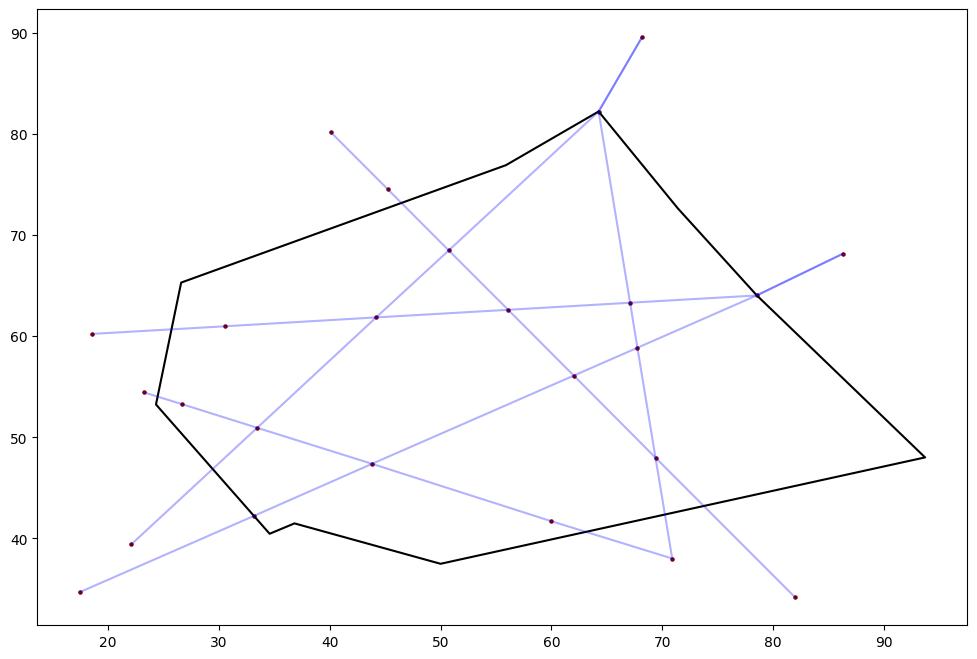

In [3]:
a = plot_sector()

class Ownship:
    def __init__(self, start_x, start_y, heading, speed, offset, original_path, destination):
        self.start_x = start_x
        self.start_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.offset = offset
        self.destination = destination
        self.pathlist = []
        self.original_path = original_path
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:    
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y
    
class Intruder:
    def __init__(self, start_x, start_y, offset, heading, speed, destination):
        self.start_x = start_x
        self.stat_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.destination = destination
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y


In [4]:
class Agent():
    """
    The Agent class encapsulates the state and parameters for two aircraft in a conflict scenario: the “ownship” (o_) 
    and the “intruder” (i_). Its __init__ method calls a helper to load all scenario data (paths, headings, start/destination
    points, scaled offsets, etc.) for one scenario from our DataFrame, then organizes that into easy-to-use attributes. It 
    also computes fixed speeds and the number of time-steps to reach each aircraft’s first conflict point (“offset”), and 
    prepares a LineString for the ATCO-approved path.

        # 1) Pull all relevant scenario arrays/values for ownship (o_*) and intruder (i_*).
        #    get_conflict_scenario returns:
        #    - o_resolved_path: list of [x, y] for ATCO-approved ownship route
        #    - o_unres_path:   list of [x, y] for original ownship route before conflict resolution
        #    - o_heading:      initial ownship heading (radians)
        #    - o_startposition:ownship start [x, y]
        #    - o_offset_dist_scaled: distance ownship travels before conflict point (scaled)
        #    - o_destination:  ownship destination [x, y]
        #    - i_path:         intruder path coordinates list
        #    - i_headinglist:  list of heading angles for intruder at each step
        #    - i_startposition:intruder start [x, y]
        #    - i_offset_dist_scaled: intruder’s scaled offset distance
        #    - i_destination:  intruder destination [x, y]
        #    - fileinfo:       metadata about this scenario (e.g., filename, index)
    """
    def __init__(self):
        o_resolved_path, o_unres_path, o_heading, o_startposition, o_offset_dist_scaled, o_destination, \
        i_path, i_headinglist, i_startposition, i_offset_dist_scaled, i_destination, fileinfo = get_conflict_scenario(featurefile)
        # 2) Store ownship’s “resolved” (ATCO-approved) vs. “unresolved” paths
        self.o_resolved_path = o_resolved_path
        self.o_unresolved_path = o_unres_path
        # 3) Initial and current heading for ownship
        self.o_initial_heading = o_heading
        self.o_heading = o_heading
        # 4) Start position (tuple) vs. mutable position list
        self.o_start = tuple(o_startposition)
        self.o_position = o_startposition
        # 5) Distance until conflict (“offset”), scaled for ownship
        self.o_offset_dist = o_offset_dist_scaled
        # 6) Final waypoint for ownship
        self.o_destination = o_destination
        # 7) Record the trajectory we’ll actually fly (starts with the initial point)
        self.o_newpathlist = [self.o_position]
        # 8) Create a geometric LineString of the ATCO-approved path
        self.ATCO_path_linestring = LineString(o_resolved_path)
        # 9) Intruder’s per-step headings and start/position
        self.i_headinglist = i_headinglist
        self.i_start = tuple(i_startposition)
        self.i_position = i_startposition
        # 10) Intruder’s original path, offset distance, and destination
        self.i_path = i_path
        self.i_offset_dist = i_offset_dist_scaled
        self.i_destination = i_destination
        # 11) Fixed speeds for both aircraft (units per time-step)
        self.o_speed = 2
        self.i_speed = 2
        # 12) Number of steps before each reaches the conflict “offset”
        self.o_offset = int(np.ceil(self.o_offset_dist/self.o_speed))
        self.i_offset = int(np.ceil(self.i_offset_dist/self.i_speed))
        # 13) Counter for how many heading changes (“actions”) we’ve applied
        self.n_actions = 0
        # 14) Store scenario metadata for later (e.g., plotting titles)
        self.fileinfo = fileinfo
        # print(self.o_offset, self.i_offset)


    def step(self, n_step, new_heading):
        # Prepare placeholders for new x,y positions
        xo, yo, xi, yi = 0, 0, 0, 0
        # --- Move the ownship ---
        # If we haven’t passed the intruder’s delay yet, keep ownship at its start point
        if n_step <= self.i_offset:
            self.o_position = self.o_start
        else:
            # Otherwise, point the ownship in the new_heading direction    
            self.o_heading = new_heading
            # Move forward by o_speed in the x-direction, then force x inside [15,100]
            xo = np.clip(self.o_position[0] + self.o_speed *np.cos(new_heading), 15, 100)
            # Move forward by o_speed in the y-direction, then force y inside [15,100]
            yo = np.clip(self.o_position[1] + self.o_speed *np.sin(new_heading), 15, 100)
            # xo = self.o_unresolved_path[n_step - self.i_offset][0]
            # yo = self.o_unresolved_path[n_step - self.i_offset][1]

            # Update the ownship’s position
            self.o_position = [xo,yo]
        # Save this ownship point so we can draw its path later    
        self.o_newpathlist.append([xo,yo])

        # print('offset',self.i_offset)
        # Before the ownship’s delay is up, keep intruder at its start  
        if n_step <= self.o_offset:
            self.i_position = self.i_start
        # While the intruder still has heading steps left:
        elif len(self.i_path)+ self.o_offset > n_step > self.o_offset:
            # Move in x by i_speed along that heading, keep x inside [15,100]
            xi = np.clip(self.i_position[0] + self.i_speed *np.cos(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            # Move in y by i_speed along that heading, keep y inside [15,100]
            yi = np.clip(self.i_position[1] + self.i_speed *np.sin(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            # Update the intruder’s position
            self.i_position = [xi, yi]
        else:
            # After the intruder’s whole path is done, jump to its destination
            self.i_position = self.i_destination
        # Return the new ownship and intruder positions
        return self.o_position, self.i_position
        

In [5]:
A = Agent()

In [6]:
class StructuredEnv(gym.Env):
    """
    This constructor sets up our custom Gym environment. It takes in a list of reward-weight parameters, 
    creates a fresh Agent. It initializes step and reward counters, then defines how many actions are possible 
    and what shape/value-ranges our observations will have. This tells any RL algorithm how to talk to our environment.
    """
    SAFE_R = 5 # Minimum safe separation distance between aircraft
    MAX_STEP = 60 # Maximum number of time-steps per episode

    def __init__(self, Reward_Params= [-1, -1, -1, -1, -1, 1]):
        # 1) Store the list of six reward-component weights (a1…a6)
        self.Reward_Params = Reward_Params
        # 2) Create a new conflict-scenario agent (ownship + intruder)
        self.agent = Agent()
        # 3) Initialize the reward from the last step, the current step counter and the accumulated total reward
        self.reward = 0
        self.n_step = 0
        self.total_reward = 0
        # 4) Determine how many numbers our observation vector will have by calling observation_func once 
        # (it returns a numpy array)
        n_observations = np.size(self.observation_func())
        # 5) Define the action space: 13 discrete choices (turn left/right by various small angles,
        #    or keep heading straight)
        self.action_space = spaces.Discrete(13)
        # 6) Define the observation space: a Box of length n_observations,
        #    with each entry allowed between –100 and +120 
        # is just telling Gym “Expect every observation to be a length-n_observations vector of floats, 
        #  where each float sits between –100 and +120.”      
        self.observation_space = spaces.Box(low = -100, high = 120, shape= (n_observations, ), dtype = np.float64)

    def reset(self, seed=None, options=None):
        """
        The reset method is called at the start of each episode to bring the environment back to its initial state. 
        It optionally seeds randomness, creates a fresh Agent (ownship + intruder), zeroes out all counters 
        and rewards, computes the very first observation, and returns that observation along with an empty info dictionary.
        """
        super().reset(seed=seed) # Call parent reset if you pass seed/options
        # Create a new Agent instance for each reset
        self.agent = Agent() 
        # Initialize counters and rewards, Clear out the last step reward 
        self.reward = 0 
        self.n_step = 0
        self.total_reward = 0
        # Compute the initial observation vector from the fresh agent state
        observation = self.observation_func()
        # Gym’s `reset` requires an `info` dict (we have no extra data to return)
        info = {} 
        # Return the tuple (observation, info)
        # This is the standard return format for Gym environments
        # The observation is the initial state of the environment, and info is an empty dictionary
        return observation, info 

    def step(self, action):
        """
        Given an action (one of 13 discrete turn adjustments), 
        it advances the global time-step, converts that action into a small heading change for the ownship, 
        updates both aircraft positions via the Agent.step call, checks if the episode should end 
        (because both planes reached their goals, came too close, moved away, or exceeded the maximum steps), 
        computes the reward based on all those factors, and finally returns the new observation, the step reward, 
        and flags indicating whether the episode terminated or was truncated.

        We chose 0.175/2 because:
        0.175 radians is about 10° (since 1° ≈ 0.01745 rad).
        By dividing by 2, you get ≈0.0875 rad, which is about 5°.
        That way each “1-step” in your discrete action corresponds to a 5° turn. 
        Multiplying that base step by 0–6 (or –6 to –1) then gives you turns of 0°, ±5°, ±10°, … up to ±30° per time-step.
        """
        # 1) Advance the step counter
        self.n_step += 1
        
        # 2) Prepare termination/truncation flags
        terminated = False
        truncated = False
        # 3) Compute the new ownship heading from the discrete action:
        ownship_heading = self.agent.o_heading
        if action < 7:
            # Actions 0–6 turn right by (action * Δ)
            angle = action * (0.175/2)
        else:
            # Actions 7–12 turn left by ((action - 6) * Δ)
            angle = (action - 6) * -(0.175/2)

        ownship_heading = ownship_heading + angle
        # 4) Move both aircraft one step using the new heading for ownship
        self.agent.step(self.n_step, ownship_heading) # new location for ownship 

        # 5) Measure distances for termination checks:
        #    - First extract the points 
        #    - Ownship to its destination
        #    - Intruder to its destination
        #    - Separation between the two aircraft
        p1 = self.agent.o_position
        o_destination = self.agent.o_destination
        p2 = self.agent.i_position
        i_destination = self.agent.i_destination
        dist1_to_dest = np.linalg.norm(np.array(p1) - np.array(o_destination))
        dist2_to_dest = np.linalg.norm(np.array(p2) - np.array(i_destination))
        sep_dist = np.linalg.norm(np.array(p1) - np.array(p2))

        # 6) Terminate if both reached within 5 units of their goals
        if (dist1_to_dest < 5) and (dist2_to_dest < 5):
            terminated = True
        
        # 7) Terminate if they come closer than SAFE_R (collision risk)
        if (sep_dist < self.SAFE_R):
            terminated = True

        # 8) Terminate if ownship is moving away from its goal by more than a small threshold
        threshold = 0.1
        if len(self.agent.o_newpathlist) > 2: # Ensure there's a previous point to compare
            previous_location = np.array(self.agent.o_newpathlist[-2])
            o_current_location = np.array(self.agent.o_position)
            prev_distance = np.linalg.norm(o_destination - previous_location)
            current_distance = np.linalg.norm(o_destination - o_current_location)
            if prev_distance - current_distance < -threshold:
                terminated = True # Punish for moving away

        # 9) Truncate if we exceed MAX_STEP
        if self.n_step >= self.MAX_STEP:
            truncated = True
        
        # 10) Compute the reward, passing a combined “done” flag
        combined_done_for_reward_func = terminated or truncated
        self.reward = self.reward_func(combined_done_for_reward_func)
        self.total_reward += self.reward
        
        # 11) Build next observation and empty info dict
        observation = self.observation_func()
        info = {}
        # 12) Return the Gym-standard 5-tuple
        return observation, self.reward, terminated, truncated, info # Return 5 values

            
    def reward_func(self, done):
        """ 
        This method computes the scalar reward at each step by combining several components—step penalty, 
        trajectory deviation, loss-of-separation penalty/bonus, failure-to-reach penalty, and success bonus—each 
        weighted by the six parameters a1…a6. If the episode has ended (done=True), additional terms (e.g., whether
        we collided or reached the goal) are applied. The final reward is the weighted sum plus any extra “moving-back” 
        penalty.

        """
        # 1) Unpack the six weights from the environment’s configuration        
        a1 = self.Reward_Params[0]
        a2 = self.Reward_Params[1]
        a3 = self.Reward_Params[2]
        a4 = self.Reward_Params[3]
        a5 = self.Reward_Params[4]
        a6 = self.Reward_Params[5]
        
        # 2) Base costs or rewards (initialized here)
        Reward_Step = 0.01 # small per-step penalty to encourage faster resolution
        Moving_back_reward = 0 # penalty if ownship moves away from its goal
        CTDreward = 0 # placeholder for distance-from-original-path reward (unused)
        reward_traj_dev = 0 # trajectory deviation reward


        # 3) Compute deviation from the ATCO-approved path:
        #    • Create a Point for ownship’s current pos
        #    • Compute its distance to the approved LineString (in same units)
        #    • Scale by 20/1000 to form the deviation reward
        o_destination = np.array(self.agent.o_destination)       
        o_current_location = Point(self.agent.o_position)
        ATCO_path_linestring = self.agent.ATCO_path_linestring
        dist = o_current_location.distance(ATCO_path_linestring)
        reward_traj_dev =  20 * (dist/1000)
        # 4) Combine any CTDreward (currently zero) with the trajectory deviation
        Reward_Deviation = CTDreward +  reward_traj_dev # This is negative, so it penalizes deviation
        
        # 5) Initialize other components
        Reward_LOS = 0
        Reward_Maneuvering = 0
        Reward_Not_Reached = 0
        Reward_Reached =0

        # 6) Distance between ownship and intruder (for LOS/collision)
        dis1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position))
        
        Reward_LOS = 0
        threshold = 0.1
        # 7) Only apply certain rewards/penalties once the episode is done
        if done:
            # 7a) Collision or near-miss bonus/penalty: if we ended due to separation breach
            if (dis1 < self.SAFE_R) :
                Reward_LOS = 10 # This is a negative reward, so it penalizes loss of separation

            # 7b) If we reached the maximum number of steps without reaching the destination
            if self.n_step == self.MAX_STEP:
                # Penalize based on how far ownship still is from its destination
                current_location = self.agent.o_position
                dist_o_d = np.linalg.norm(np.array(o_destination) - np.array(current_location))
                Reward_Not_Reached = (dist_o_d/10) # Penalize for not reaching destination

            # 7c) Penalty if the ownship just moved away from its destination in final step (done in the else part)
            if len(self.agent.o_newpathlist) <=2:
                pass
            else:
                # Grab the second-to-last position we recorded for ownship
                previous_location = np.array(self.agent.o_newpathlist[-2])
                # Grab the current position of ownship
                o_current_location = np.array(self.agent.o_position)
                # Compute distance from that previous point to the destination
                prev_distance = np.linalg.norm(o_destination - previous_location)
                # Compute distance from the final point to the destination
                current_distance = np.linalg.norm(o_destination - o_current_location)
                # If current_distance > prev_distance by more than `threshold`,
                # it means ownship moved away. We then set a penalty:
                if prev_distance - current_distance < -threshold:
                    Moving_back_reward =  -20
               

            #reaching destination
            p1 = self.agent.o_position
            o_destination = self.agent.o_destination
            p2 = self.agent.i_position
            
            i_destination = self.agent.i_destination
            # 7d) Success bonus or failure penalty upon reaching ownship destination (else condition)
            dist1 = np.linalg.norm(np.array(p1) - np.array(o_destination))
            # dist2 = np.linalg.norm(np.array(p2) - np.array(i_destination))
            if (dist1 < 5): # reaching destination
                Reward_Reached = 10
            else:
                Reward_Reached = - dist1/10 # penalize for not reaching destination (proportional to remaining distance)

        reward = a1 * Reward_Step + a2 *Reward_Deviation + a3 * Reward_LOS + \
                    a5 * Reward_Not_Reached + a6 * Reward_Reached + Moving_back_reward 
        return reward        


    def observation_func(self):
        """
        This method gathers all the state information we want the agent to “see” at each step,
        packs it into a flat NumPy array, and returns it. It includes the ownship’s and intruder’s positions,
        the ownship’s destination, pairwise distances (between aircraft and to each destination), how far the ownship
        has strayed from its original and ATCO-approved paths, and the ownship’s current heading.

        The observation vector contains, in order:
            Ownship’s X and Y position
            Intruder’s X and Y position
            Ownship’s destination X and Y
            Distance between ownship and intruder
            Distance from ownship to its destination
            Distance from intruder to its destination
            Distance from ownship to its original (unresolved) path
            Distance from ownship to the ATCO-approved path
            Ownship’s current heading angle
        """
        observation  = []

        observation.append(self.agent.o_position[0])
        observation.append(self.agent.o_position[1])
        observation.append(self.agent.i_position[0])
        observation.append(self.agent.i_position[1])
        observation.append(self.agent.o_destination[0])
        observation.append(self.agent.o_destination[1])
        # observation.append(self.agent.i_destination[0])
        # observation.append(self.agent.i_destination[1])
    

        dist1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position)) 
        dist_o_d = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.o_destination))
        dist_i_d = np.linalg.norm(np.array(self.agent.i_position) - np.array(self.agent.i_destination))

        # Distance between ownship and intruder
        observation.append(dist1)  
        # Distance from ownship to its destination
        observation.append(dist_o_d)
        # Distance from intruder to its destination
        observation.append(dist_i_d)
        # individual coordinates

        current_location = Point(self.agent.o_position)
        # How far ownship is from its ORIGINAL unresolved path
        CTD_distance  = current_location.distance(LineString(self.agent.o_unresolved_path))
        # How far ownship is from the ATCO-approved path
        dist_from_ATCO_path = current_location.distance(self.agent.ATCO_path_linestring)

        observation.append(CTD_distance) #
        observation.append(dist_from_ATCO_path)

        # Ownship’s current heading angle (radians)
        observation.append(self.agent.o_heading)     
        
        # Convert to a NumPy array and return
        observation = np.array(observation)
        return observation

   
    def render(self, show = False, folder = './Images/'):
        """
        The render method draws a snapshot of the current episode on top of our sector plot, marking both aircraft’s 
        start, current, and destination points, the ATCO-approved path, and safety circles. It can either display the 
        figure interactively or save it to disk. The close method is a no-op placeholder for any future cleanup.
        """
        # fig, ax = plt.subplots(figsize = (14, 11))
        # print("Ownship", self.agent.o_start)
        # print("intruder", self.agent.i_start)
        # print(self.agent.fileinfo)

        # 1) Draw the static sector background
        figure = plot_sector() # Call our helper to redraw boundaries/waypoints
        ax = figure.gca()  # Grab the current Axes for plotting overlays
        # ax.scatter(50,50, s = 200)
        
        # 2)Plot ownship’s current position (black dot), Plot ownship’s start (black triangle), Plot ownship’s destination (black star)
        ax.scatter(self.agent.o_position[0], self.agent.o_position[1], c = 'black', s = 40)
        ax.scatter(self.agent.o_start[0], self.agent.o_start[1] , c = 'black', s = 50, marker = '^')
        ax.scatter(self.agent.o_destination[0], self.agent.o_destination[1], c = 'black', s = 20, marker= '*')

        # 3) Plot intruder’s current position (maroon dot), Plot intruder’s start (maroon triangle), Plot intruder’s destination (maroon star)
        ax.scatter(self.agent.i_position[0], self.agent.i_position[1], c = 'maroon', s = 40)
        ax.scatter(self.agent.i_start[0], self.agent.i_start[1] , c = 'maroon', s = 50, marker = '^')
        ax.scatter(self.agent.i_destination[0], self.agent.i_destination[1], c = 'maroon', s = 20, marker= '*')
        x, y = [],[]
        for i in range(len(self.agent.o_unresolved_path)):
            x.append(self.agent.o_unresolved_path[i][0])    
            y.append(self.agent.o_unresolved_path[i][1])
            
        # ax.plot(x,y, linewidth = 1, color = 'grey')
        #add circle to the destination
        
        # 4) Draw the ATCO-approved path as a dashed maroon line
        x_, y_ = self.agent.ATCO_path_linestring.xy
        ax.plot(x_, y_, color = 'maroon',linestyle = '--', alpha = 1)

        # 5) Add translucent safety circles around each destination
        circle1 = plt.Circle((self.agent.o_destination[0], self.agent.o_destination[1]), 5, color = 'black',\
                              alpha = 0.2)
        circle2 = plt.Circle((self.agent.i_destination[0], self.agent.i_destination[1]), 5, color = 'maroon',\
                              alpha = 0.5)
        ax.add_patch(circle1)
        ax.add_patch(circle2)
        # 6) Annotate title with step number, recent reward, totals, headings, and offsets
        ax.set_title("Step {} - Reward {:.3f} - Total Reward {:.3f} - headings{}  - offsets(O:I){}".format(self.n_step,self.reward,\
                                                                            self.total_reward,\
                                                                                ((self.agent.o_initial_heading) ,\
                                                                                     np.round(math.degrees(self.agent.o_heading),2)),\
                                                                                        (self.agent.o_offset, self.agent.i_offset)))

        # ax.axis('scaled')
        
        # 7) Display the plot or save it to a file
        if show:
            plt.show()
        else:
            # Save the plot as a PNG file named by step number
            plt.savefig(folder + "image_{:0>3}.png".format(self.n_step)) 
            print(folder + "image_{:0>3}.png".format(self.n_step))

        return figure

    def close(self):
        # Placeholder for any cleanup (e.g., closing files or windows). Currently does nothing.
        pass

In [7]:
from stable_baselines3.common.env_checker import check_env
env = StructuredEnv()
check_env(env)

./Images/image_000.png


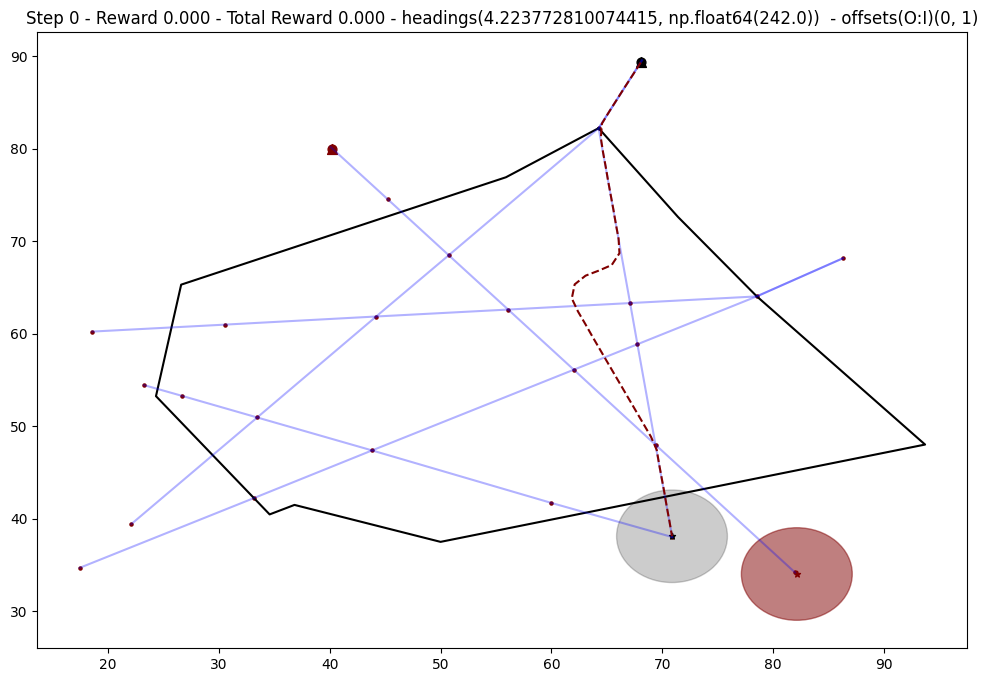

In [8]:
# Quick smoke test: reset, render one frame, then close3 
env.reset() # Reset the environment to its initial state
env.render() # Draw and save the first frame
env.close() # Close the environment (no-op here, but good practice)

In [9]:
# Sanity check: print the observation vector shape and values
env.observation_func()

array([6.80600000e+01, 8.93007500e+01, 4.02400000e+01, 7.99985000e+01,
       7.08800000e+01, 3.81035000e+01, 2.93340119e+01, 5.12748555e+01,
       6.22011962e+01, 6.92064196e-03, 0.00000000e+00, 4.22377281e+00])

Overview of the Training & Evaluation Pipeline
This final section shows how we hook our custom environment into Stable-Baselines3’s PPO agent, train it, save the model, evaluate its performance, generate rollout animations, and finally launch TensorBoard to visualize training metrics.

 CHECKING THE PERCENTAGE OF SCENARIOS HAVING CONFLICTS
env = env
 Visualize 1 episode using the trained policy and store the image into selected folder
res = []
for trial in range(100):
    obs = env.reset()
    for i in range(60):
        # Take a random action
        action = 0
        obs, reward, done, info = env.step(action)
        
        # Render the game
        if done == True:
            if reward <= -5:
                res.append(1)
            else:
                res.append(0)
            break

res = np.mean(res)
print('res', res)

## PPO PyTorch Implementation

In [10]:

from tensorboardX import SummaryWriter
run_name = "PPO_v2"  
log_dir  = f"./log/PPO/{run_name}"
writer   = SummaryWriter(log_dir)
%tensorboard --logdir ./log/PPO/ --host localhost --port 8040

Reusing TensorBoard on port 8040 (pid 380178), started 7 days, 2:34:21 ago. (Use '!kill 380178' to kill it.)

PyTorch version V4 - Following are the changes made on top of the previous version for smoother convergence:
- Used GAE(λ) + normalize advantages: We switched from raw Monte-Carlo returns to GAE and now only normalize advantages, which cuts variance in the policy gradient a lot.
- Mini-batch updates (with shuffling) + multiple epochs: Instead of one big full-batch step, we split each rollout into mini-batches and do a few passes (K_epochs=5). This steadies updates and avoids overfitting a single batch.
- Gradient clipping: We clip grads at 0.5 so no single update can “explode” the policy.
- Lower learning rates: lr_actor=2e-4, lr_critic=8e-4 (down from 3e-4 / 1e-3) to make each step gentler.
- Deterministic evaluation (argmax): During eval only, we pick the most likely action instead of sampling, so the eval curve reflects policy quality—not randomness.
- Observation normalization
- Reward normalization (per update batch): We standardize rewards within each update to keep target scales consistent for the value loss.

In [11]:
def _atomic_torch_save(obj, path: str):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)

def save_training_checkpoint(path: str, agent, time_step: int, episode: int):
    ckpt = {
        # models
        "policy": agent.policy.state_dict(),
        "policy_old": agent.policy_old.state_dict(),
        "optimizer": agent.optimizer.state_dict(),
        # obs normalizer
        "obs_mean": agent.obs_rms.mean.detach().cpu(),
        "obs_var":  agent.obs_rms.var.detach().cpu(),
        "obs_count": float(agent.obs_rms.count),
        # counters
        "time_step": int(time_step),
        "episode": int(episode),
        # RNG states (optional but useful)
        "torch_rng": torch.get_rng_state(),
        "numpy_rng": np.random.get_state(),
        "py_rng":    random.getstate(),
        "cuda_rng":  torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        # (optional) hyperparams snapshot if you want
        "hparams": {
            "gamma": agent.gamma,
            "K_epochs": agent.K_epochs,
            "eps_clip": agent.eps_clip,
            "mb_size": agent.mb_size,
            "gae_lambda": agent.gae_lambda,
        },
    }
    _atomic_torch_save(ckpt, path)

def load_training_checkpoint(path: str, agent, device):
    ckpt = torch.load(path, map_location=device)

    agent.policy.load_state_dict(ckpt["policy"])
    agent.policy_old.load_state_dict(ckpt["policy_old"])
    agent.optimizer.load_state_dict(ckpt["optimizer"])

    agent.obs_rms.mean  = ckpt["obs_mean"].to(device)
    agent.obs_rms.var   = ckpt["obs_var"].to(device)
    agent.obs_rms.count = ckpt["obs_count"]

    # restore RNG states (optional)
    torch.set_rng_state(ckpt["torch_rng"])
    if torch.cuda.is_available() and ckpt.get("cuda_rng") is not None:
        torch.cuda.set_rng_state_all(ckpt["cuda_rng"])
    np.random.set_state(ckpt["numpy_rng"])
    random.setstate(ckpt["py_rng"])

    return int(ckpt["time_step"]), int(ckpt["episode"])


In [12]:
# 0. Utilities: Running Mean/Std for Obs Normalization
class RunningMeanStd:
    """Track running mean and variance of observations."""
    def __init__(self, shape, eps: float = 1e-4):
        self.mean  = torch.zeros(shape, dtype=torch.float32, device=device)
        self.var   = torch.ones(shape,  dtype=torch.float32, device=device)
        self.count = eps

    @torch.no_grad()
    def update(self, x: torch.Tensor):
        # x: (..., shape)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        batch_mean = x.mean(dim=0)
        batch_var  = x.var(dim=0, unbiased=False)
        batch_count = x.shape[0]
        delta = batch_mean - self.mean
        tot_count = self.count + batch_count
        new_mean = self.mean + delta * (batch_count / tot_count)
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + (delta ** 2) * self.count * batch_count / tot_count
        new_var = M2 / tot_count
        self.mean, self.var, self.count = new_mean, new_var, tot_count

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / torch.sqrt(self.var + 1e-8)

# 1. Rollout Buffer
class RolloutBuffer:
    def __init__(self):
        self.states       = []  # list of torch tensors (normalized obs) on device
        self.actions      = []  # list of torch tensors on device
        self.logprobs     = []  # list of torch tensors on device
        self.state_values = []  # list of torch tensors on device
        self.rewards      = []  # list of floats
        self.is_terminals = []  # list of bools

    def clear(self):
        # Reset all buffer lists by reinitializing
        self.__init__()

# 2. Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Shared feature extractor
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64),         nn.Tanh()
        )
        # Policy head: outputs action probabilities for discrete actions
        self.actor = nn.Sequential(
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        # Critic head: outputs state-value estimate
        self.critic = nn.Linear(64, 1)

    def act(self, state):
        # Given a single (normalized) state tensor (shape [state_dim]), sample an action
        features     = self.net(state)
        action_probs = self.actor(features)
        dist         = Categorical(action_probs)

        action      = dist.sample()
        action_logp = dist.log_prob(action)
        value       = self.critic(features)
        return action.detach(), action_logp.detach(), value.detach()

    def evaluate(self, states, actions):
        # Given batches of (normalized) states and actions, compute:
        # - log-probabilities of those actions
        # - state-value estimates
        # - policy entropy for exploration bonus
        features        = self.net(states)
        action_probs    = self.actor(features)
        dist            = Categorical(action_probs)

        action_logprobs = dist.log_prob(actions)
        dist_entropy    = dist.entropy()
        state_values    = self.critic(features).squeeze(-1)
        return action_logprobs, state_values, dist_entropy

# 3. PPO Agent Wrapper
class PPO:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr_actor=2e-4,
        lr_critic=8e-4,
        gamma=0.99,
        K_epochs=5,
        eps_clip=0.2,
        mb_size=256,
        gae_lambda=0.95,
        normalize_reward=True,
    ):
        self.gamma      = gamma
        self.eps_clip   = eps_clip
        self.K_epochs   = K_epochs
        self.mb_size    = mb_size
        self.gae_lambda = gae_lambda
        self.normalize_reward = normalize_reward

        self.buffer = RolloutBuffer()

        # Observation normalizer
        self.obs_rms = RunningMeanStd(shape=state_dim)

        # Initialize current & old policy networks on device
        self.policy     = ActorCritic(state_dim, action_dim).to(device)
        self.policy_old = ActorCritic(state_dim, action_dim).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())

        # Optimizer for actor and critic parameters
        self.optimizer = torch.optim.Adam([
            {'params': self.policy.net.parameters(),   'lr': lr_actor},
            {'params': self.policy.actor.parameters(), 'lr': lr_actor},
            {'params': self.policy.critic.parameters(),'lr': lr_critic},
        ])
        self.MseLoss = nn.MSELoss()

    def _normalize_obs_train(self, state_tensor: torch.Tensor) -> torch.Tensor:
        # Update running stats with current state, then normalize
        self.obs_rms.update(state_tensor)
        return self.obs_rms.normalize(state_tensor)

    def _normalize_obs_eval(self, state_tensor: torch.Tensor) -> torch.Tensor:
        # Use current running stats, do NOT update during evaluation
        return self.obs_rms.normalize(state_tensor)

    def select_action(self, state):
        # Convert raw state to tensor on device and normalize (train-time)
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
        norm_state   = self._normalize_obs_train(state_tensor)
        action, logp, value = self.policy_old.act(norm_state)

        # Store tensors directly (already on device)
        self.buffer.states.append(norm_state)
        self.buffer.actions.append(action)
        self.buffer.logprobs.append(logp)
        self.buffer.state_values.append(value)

        return action.cpu().item()

    def update(self):
        """ PPO update with GAE(λ), advantage normalization, mini-batches, grad clipping, and reward normalization. """
        # ---- Stack rollout tensors (on device) ----
        states      = torch.stack(self.buffer.states,       dim=0)  # (T, obs_dim) normalized
        actions     = torch.stack(self.buffer.actions,      dim=0)  # (T,)
        old_logprob = torch.stack(self.buffer.logprobs,     dim=0)  # (T,)
        values      = torch.stack(self.buffer.state_values, dim=0).squeeze(-1)  # (T,)
        rewards_raw = torch.tensor(self.buffer.rewards, dtype=torch.float32, device=device)  # r_t
        dones       = torch.tensor(self.buffer.is_terminals, dtype=torch.float32, device=device)  # 1 if terminal else 0

        # ---- Reward normalization (per-batch) ----
        if self.normalize_reward:
            r_mean = rewards_raw.mean()
            r_std  = rewards_raw.std(unbiased=False)
            rewards = (rewards_raw - r_mean) / (r_std + 1e-8)
        else:
            rewards = rewards_raw

        # ---- GAE(λ) advantages using (normalized) rewards ----
        T = rewards.size(0)
        advantages = torch.zeros(T, dtype=torch.float32, device=device)
        last_gae = 0.0
        values_ext = torch.cat([values, torch.zeros(1, device=device)], dim=0)  # bootstrap 0 at end
        for t in reversed(range(T)):
            next_value = values_ext[t + 1]
            delta = rewards[t] + self.gamma * next_value * (1.0 - dones[t]) - values[t]
            last_gae = delta + self.gamma * self.gae_lambda * (1.0 - dones[t]) * last_gae
            advantages[t] = last_gae
        returns = advantages + values  # targets for value loss

        # ---- Normalize advantages only ----
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ---- Mini-batch SGD over K epochs ----
        batch_size = states.size(0)
        mb_size = min(self.mb_size, batch_size)
        for _ in range(self.K_epochs):
            idx = torch.randperm(batch_size, device=device)
            for start in range(0, batch_size, mb_size):
                mb_idx = idx[start:start + mb_size]
                mb_states   = states[mb_idx]
                mb_actions  = actions[mb_idx]
                mb_old_logp = old_logprob[mb_idx]
                mb_adv      = advantages[mb_idx]
                mb_returns  = returns[mb_idx]

                logprobs, state_vals, entropy = self.policy.evaluate(mb_states, mb_actions)
                ratios = torch.exp(logprobs - mb_old_logp.detach())
                surr1  = ratios * mb_adv
                surr2  = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * mb_adv

                policy_loss   = -torch.min(surr1, surr2).mean()
                value_loss    = self.MseLoss(state_vals, mb_returns)
                entropy_bonus = -0.01 * entropy.mean()

                loss = policy_loss + 0.5 * value_loss + entropy_bonus

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
                self.optimizer.step()

        # ---- Sync old policy and clear buffer ----
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.buffer.clear()

    def save(self, path):
        torch.save(self.policy_old.state_dict(), path)

    def load(self, path):
        state_dict = torch.load(path, map_location=device)
        self.policy_old.load_state_dict(state_dict)
        self.policy.load_state_dict(state_dict)

# 4. Evaluation Function
def evaluate_policy(agent, env, n_episodes=10):
    """Deterministic evaluation (argmax over action probs) for smoother curves.
    Uses observation normalization stats but does not update them.
    """
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_ret = 0.0
        while not done:
            state_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
            norm_state   = agent._normalize_obs_eval(state_tensor)
            with torch.no_grad():
                features = agent.policy_old.net(norm_state)
                probs    = agent.policy_old.actor(features)
                action   = torch.argmax(probs, dim=-1).item()
            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_ret += reward
        returns.append(ep_ret)
    return np.mean(returns), np.std(returns)

In [82]:
# Logging & Checkpointing setup
run_name       = "PPO_v3"
log_dir        = f"./log/PPO/{run_name}"
best_model_path = os.path.join(log_dir, "best_model.pth")
last_ckpt_path  = os.path.join(log_dir, "last.ckpt")
os.makedirs(log_dir, exist_ok=True)

# Initialize env and agent (same as before)
env        = StructuredEnv()
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.n
ppo_agent  = PPO(state_dim, action_dim,
                 lr_actor=2e-4, lr_critic=8e-4,
                 gamma=0.99, K_epochs=5, eps_clip=0.2,
                 mb_size=256, gae_lambda=0.95,
                 normalize_reward=True)

# Training trackers
time_step        = 0
episode          = 0
best_mean_reward = -math.inf
start_time       = datetime.now()

# --- Resume if last.ckpt exists ---
if os.path.exists(last_ckpt_path):
    time_step, episode = load_training_checkpoint(last_ckpt_path, ppo_agent, device)
    print(f"Resumed from {last_ckpt_path} at step {time_step}, episode {episode}")

NameError: name 'load_training_checkpoint' is not defined

Training Code

In [83]:
# # Base Prompt with 3 derived signals

# from dataclasses import dataclass
# from typing import Optional, List, Sequence
# import math
# import numpy as np
# from collections import deque


# def _delta_heading_deg(h_res: float, h_unres: float) -> float:
#     """Signed smallest-angle difference (deg) resolved − unresolved in (−180, 180]."""
#     d = (h_res - h_unres + 180.0) % 360.0 - 180.0
#     return d

# def _mag_to_bin_deg(deg: float) -> int:
#     """Map any |deg| to {0,5,10,15,20,25,30}, capped at 30."""
#     k = round(abs(deg) / 5.0)
#     k = max(0, min(6, k))
#     return 5 * k

# # --- Small typed view over your observation vector ---
# @dataclass
# class ObsSnapshot:
#     own_x: float
#     own_y: float
#     intr_x: float
#     intr_y: float
#     dest_x: float
#     dest_y: float
#     sep_oi: float
#     dist_o_dest: float
#     dist_i_dest: float
#     ctd_dist: float
#     dist_to_atco_path: float
#     own_heading_rad: float
#     step: Optional[int] = None

#     @staticmethod
#     def from_vector(vec: np.ndarray, step: Optional[int] = None) -> "ObsSnapshot":
#         """
#         Maps env.observation_func() vector (current ordering) into fields.
#         Index map:
#           0..1: own (x,y)
#           2..3: intruder (x,y)
#           4..5: own destination (x,y)
#           6:    separation own↔intruder
#           7:    own→dest distance
#           8:    intr→dest distance
#           9:    cross-track to original path
#           10:   distance to ATCO path
#           11:   own heading (radians)
#         """
#         return ObsSnapshot(
#             own_x=float(vec[0]),
#             own_y=float(vec[1]),
#             intr_x=float(vec[2]),
#             intr_y=float(vec[3]),
#             dest_x=float(vec[4]),
#             dest_y=float(vec[5]),
#             sep_oi=float(vec[6]),
#             dist_o_dest=float(vec[7]),
#             dist_i_dest=float(vec[8]),
#             ctd_dist=float(vec[9]),
#             dist_to_atco_path=float(vec[10]),
#             own_heading_rad=float(vec[11]),
#             step=step,
#         )

# def _rad2deg(r: float) -> float:
#     return float(r) * 180.0 / math.pi

# def _wrap_deg(a: float) -> float:
#     """Wrap any angle in degrees to (-180, 180]."""
#     return ((a + 180.0) % 360.0) - 180.0

# def _bearing_deg(dy: float, dx: float) -> float:
#     """atan2(dy, dx) in degrees."""
#     return math.degrees(math.atan2(dy, dx))

# def _side_word(x: float, left="left", right="right", center="centerline") -> str:
#     if x > 0: return left
#     if x < 0: return right
#     return center

# def _ahead_or_behind(abs_deg: float) -> str:
#     return "ahead" if abs_deg < 90.0 else "abeam/behind"

# # --- Extensible builder: now includes derived signals; history/BC stats can be added later.
# class BasePromptBuilder:
#     def __init__(self):
#         self._bc_text_cache: Optional[str] = None  # Placeholder for future BC baseline text
    
#     def _instructions_text(self) -> str:
#         return (
#         "ROLE: You are an ATCO planning assistant for a single sector. "
#         "Read the situation (current observation, recent history, ATCO baseline stats) and:\n"
#         "  (1) summarize the current scenario, and\n"
#         "  (2) recommend a discrete heading change.\n\n"
#         "ASSUMPTIONS:\n"
#         "- Distances are in scenario units. One 'step' is one environment step.\n"
#         "- Headings: 0° = east; positive = left/CCW; negative = right/CW.\n"
#         "- Intruder relative bearing is from ownship’s nose; |bearing| near 0° is higher risk.\n\n"
#         "DECISION CUES (do not output intermediate math):\n"
#         "- Separation drift (last step) and net change over the fixed history window of 5.\n"
#         "- Intruder relative bearing magnitude/side and whether it’s moving toward/away from the nose.\n"
#         "- Heading error to destination and notable cross-track deviation.\n"
#         "- Typical turn magnitudes from ATCO baseline (context only).\n\n"
#         "MANEUVER (DISCRETE ONLY):\n"
#         "- Choose the heading change strictly from: "
#         "[-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30] (degrees). "
#         "Use + for left/CCW, − for right/CW. If uncertain or not needed, use 0.\n\n"
#         "OUTPUT:\n"
#         "- Return EXACTLY ONE JSON object, no backticks, no extra prose, no extra fields.\n"
#         "- TTCP and separation are computed elsewhere: do NOT guess them. Set them to null.\n\n"
#         "FORMAT EXAMPLE (follow this structure exactly):\n"
#         "{\n"
#         '  "answer": {\n'
#         '    "scenario_summary": "<1–3 sentences on geometry and risk>",\n'
#         '    "metrics": {\n'
#         '      "ttcp": null,\n'
#         '      "separation_distance": null\n'
#         '    },\n'
#         '    "maneuver": {\n'
#         '      "heading_change_deg": -10\n'
#         '    }\n'
#         "  }\n"
#         "}\n\n"
#         "=========================\n"
#         "Current observation, derived signals, and recent history are:\n"
#         )

#     # Public entrypoint (stable API)
#     def build_base_prompt(
#         self,
#         obs_vector: np.ndarray,
#         *,
#         step: Optional[int] = None,
#         prev_obs_vector: Optional[np.ndarray] = None,
#         prev_step: Optional[int] = None,
#         history_vectors: Optional[Sequence[np.ndarray]] = None,  # <-- NEW
#         history_steps:   Optional[Sequence[int]] = None,         # <-- NEW
#     ) -> str:
#         snap = ObsSnapshot.from_vector(obs_vector, step=step)
#         prev = ObsSnapshot.from_vector(prev_obs_vector, step=prev_step) if prev_obs_vector is not None else None

#         # Build history snapshots (oldest → newest). History should NOT include 'snap' itself.
#         hist_snaps: List[ObsSnapshot] = []
#         if history_vectors is not None:
#             if history_steps is not None and len(history_steps) != len(history_vectors):
#                 raise ValueError("history_steps must match history_vectors length")
#             for i, v in enumerate(history_vectors):
#                 s_i = history_steps[i] if history_steps is not None else None
#                 hist_snaps.append(ObsSnapshot.from_vector(v, step=s_i))

#         parts = [
#             self._instructions_text(),
#             self._current_observation_text(snap),
#             self._derived_signals_text(snap, prev),
#             self._kinematics_text(snap, prev),
#             self._recent_history_text(hist_snaps, current=snap),   # <-- NEW (only prints if history given)
#             self._bc_baseline_text(csv_path="featurefile_transformed_2.csv"),                           
#         ]
#         return "\n\n".join(p for p in parts if p)

#     def _kinematics_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
#         """
#         Speeds and TTCP-to-CPA from current & previous snapshots.
#         Units: scenario-units per step (1 step = 2 minutes).
#         TTCP: time (in steps) to closest approach assuming constant velocity & straight lines.
#         """
#         if prev is None:
#             return ("Kinematics (needs a previous observation to compute):\n"
#                     "- Ownship speed: N/A\n- Intruder speed: N/A\n"
#                     "- Relative speed: N/A\n- TTCP (to CPA): N/A")

#         # Δt in steps (fallback to 1 if step indices missing or equal)
#         dt_steps = 1
#         if s.step is not None and prev.step is not None and s.step != prev.step:
#             dt_steps = max(1, s.step - prev.step)

#         # Position deltas
#         dx_o = s.own_x  - prev.own_x
#         dy_o = s.own_y  - prev.own_y
#         dx_i = s.intr_x - prev.intr_x
#         dy_i = s.intr_y - prev.intr_y

#         # Speeds (scenario-units per step)
#         v_o = math.hypot(dx_o, dy_o) / dt_steps
#         v_i = math.hypot(dx_i, dy_i) / dt_steps

#         # Relative position r (intruder relative to ownship) at current step
#         rx = s.intr_x - s.own_x
#         ry = s.intr_y - s.own_y

#         # Relative velocity v_rel = v_i - v_o
#         vrx = (dx_i - dx_o) / dt_steps
#         vry = (dy_i - dy_o) / dt_steps
#         vrel_mag2 = vrx*vrx + vry*vry

#         # TTCP-to-CPA (in steps): t* = - (r · v_rel) / |v_rel|^2, clamped to >= 0
#         if vrel_mag2 > 0:
#             t_star = - (rx*vrx + ry*vry) / vrel_mag2
#             ttcp_steps = max(0.0, t_star)
#             ttcp_minutes = 2.0 * ttcp_steps  # 1 step = 2 minutes
#             ttcp_text = f"{ttcp_steps:.2f} steps (~{ttcp_minutes:.1f} min)"
#         else:
#             ttcp_text = "N/A (relative speed ~ 0)"

#         rel_speed = math.sqrt(vrel_mag2)

#         lines = []
#         lines.append("Kinematics (scenario-units per step; 1 step = 2 min):")
#         lines.append(f"- Ownship speed: {v_o:.3f}")
#         lines.append(f"- Intruder speed: {v_i:.3f}")
#         lines.append(f"- Relative speed |v_rel|: {rel_speed:.3f}")
#         lines.append(f"- TTCP (to CPA): {ttcp_text}")
#         return "\n".join(lines)

#     def _current_observation_text(self, s: ObsSnapshot) -> str:
#         lines = []
#         lines.append("Current situation (all numbers are in scenario units):")
#         if s.step is not None:
#             lines.append(f"- Step index: {s.step}")
#         lines.append(f"- Ownship position: x={s.own_x:.1f}, y={s.own_y:.1f}")
#         lines.append(f"- Intruder position: x={s.intr_x:.1f}, y={s.intr_y:.1f}")
#         lines.append(f"- Ownship destination: x={s.dest_x:.1f}, y={s.dest_y:.1f}")
#         lines.append(f"- Separation (ownship ↔ intruder): {s.sep_oi:.2f}")
#         lines.append(f"- Distances: ownship→dest={s.dist_o_dest:.2f}, intruder→dest={s.dist_i_dest:.2f}")
#         lines.append(f"- Deviation: cross-track-to-original={s.ctd_dist:.2f}, distance-to-ATCO-path={s.dist_to_atco_path:.2f}")
#         lines.append(f"- Ownship heading: {_rad2deg(s.own_heading_rad):.1f}° (0°=east, positive is counter-clockwise)")
#         return "\n".join(lines)

#     def _derived_signals_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
#         """
#         Three simple, informative signals:
#           1) heading_error_to_dest_deg
#           2) bearing_error_to_intr_deg
#           3) sep_trend_per_step (requires previous obs; otherwise N/A)
#         """
#         own_heading_deg = _rad2deg(s.own_heading_rad)

#         # 1) Heading error to destination
#         heading_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
#         heading_error_to_dest_deg = _wrap_deg(heading_to_dest_deg - own_heading_deg)

#         # 2) Bearing error to intruder
#         own_to_intr_angle_deg = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
#         bearing_error_to_intr_deg = _wrap_deg(own_to_intr_angle_deg - own_heading_deg)
#         intr_pos_rel = _ahead_or_behind(abs(bearing_error_to_intr_deg))

#         # 3) Separation trend per step (Δsep)
#         if prev is not None:
#             sep_trend = s.sep_oi - prev.sep_oi  # negative = closing, positive = opening
#             sep_trend_text = f"{sep_trend:+.3f} per step ({'closing' if sep_trend < 0 else 'opening' if sep_trend > 0 else 'steady'})"
#         else:
#             sep_trend_text = "N/A (no previous observation)"

#         lines = []
#         lines.append("Derived signals (simple math, for decision support):")
#         lines.append(f"- Heading error to destination: {heading_error_to_dest_deg:+.1f}° "
#                      f"(destination is to your {_side_word(heading_error_to_dest_deg)})")
#         lines.append(f"- Bearing error to intruder:   {bearing_error_to_intr_deg:+.1f}° "
#                      f"(intruder is to your {_side_word(bearing_error_to_intr_deg)}; {intr_pos_rel})")
#         lines.append(f"- Separation trend (Δsep):      {sep_trend_text}")
#         return "\n".join(lines)

#     # ---- Stubs to fill later ----
#     # NOTE: make sure you have: from typing import List

#     def _recent_history_text(self, hist_snaps: List[ObsSnapshot], *, current: ObsSnapshot) -> str:
#         """
#         Simple-language trend summary over a fixed history window of size K=5 (oldest → current).
#         """
#         K = 5
#         if len(hist_snaps) < K:
#             return ""

#         window = hist_snaps[-K:]
#         oldest = window[0]
#         newest = window[-1]

#         def heading_err_to_dest_deg(s: ObsSnapshot) -> float:
#             own_h_deg = _rad2deg(s.own_heading_rad)
#             head_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
#             return _wrap_deg(head_to_dest_deg - own_h_deg)

#         def rel_bearing_to_intr_deg(s: ObsSnapshot) -> float:
#             own_h_deg = _rad2deg(s.own_heading_rad)
#             b = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
#             return _wrap_deg(b - own_h_deg)

#         # Helpers to use friendlier words
#         def _closer_or_farther(x: float) -> str:
#             return "getting closer" if x < 0 else "moving farther apart" if x > 0 else "no change"

#         def _path_side(deg: float) -> str:
#             if deg > 0: return "left of the direct path"
#             if deg < 0: return "right of the direct path"
#             return "exactly on the direct path"

#         def _nose_quadrant(deg: float) -> str:
#             a = abs(deg)
#             side = "left" if deg > 0 else "right" if deg < 0 else ""
#             if a < 10:
#                 return "dead-ahead"
#             elif a < 90:
#                 return f"{side}-front" if side else "ahead"
#             else:
#                 return f"{side}-side/behind" if side else "side/behind"

#         # ---- 1) Separation ----
#         sep_start = float(oldest.sep_oi)
#         sep_prev  = float(newest.sep_oi)
#         sep_now   = float(current.sep_oi)

#         sep_net   = sep_now - sep_start
#         sep_last  = sep_now - sep_prev

#         # ---- 2) Heading alignment to destination ----
#         he_start = heading_err_to_dest_deg(oldest)
#         he_prev  = heading_err_to_dest_deg(newest)
#         he_now   = heading_err_to_dest_deg(current)

#         he_net   = he_now - he_start
#         he_last  = he_now - he_prev

#         align_trend = "better aligned than at the start" if abs(he_now) < abs(he_start) \
#                     else "worse aligned than at the start" if abs(he_now) > abs(he_start) \
#                     else "same alignment as at the start"

#         # ---- 3) Intruder relative bearing (vs nose) ----
#         r_start = rel_bearing_to_intr_deg(oldest)
#         r_prev  = rel_bearing_to_intr_deg(newest)
#         r_now   = rel_bearing_to_intr_deg(current)

#         rmag_net  = abs(r_now) - abs(r_start)   # <0 toward nose, >0 away
#         rmag_last = abs(r_now) - abs(r_prev)

#         t_old = f"t={oldest.step}" if oldest.step is not None else "oldest"
#         t_cur = f"t={current.step}" if current.step is not None else "current"

#         lines = []
#         lines.append(f"Last {K} steps ({t_old} → {t_cur}):")

#         # Separation — plain language first, numbers in parentheses
#         lines.append(
#             f"- Distance between aircraft: {sep_start:.2f} → {sep_now:.2f} "
#             f"({sep_net:+.2f}; {_closer_or_farther(sep_net)}). "
#             f"Last step: {sep_last:+.2f} ({_closer_or_farther(sep_last)})."
#         )

#         # Destination alignment — where you are relative to the direct path
#         lines.append(
#             f"- Facing the destination: now {abs(he_now):.1f}° {_path_side(he_now)} "
#             f"(was {abs(he_start):.1f}° {_path_side(he_start)}). "
#             f"Trend: {align_trend}. Last step change: {he_last:+.1f}°."
#         )

#         # Intruder location relative to nose — quadrant words + nose-angle trend
#         lines.append(
#             f"- Intruder position vs your nose: {r_start:+.1f}° → {r_now:+.1f}° "
#             f"({ _nose_quadrant(r_start) } → { _nose_quadrant(r_now) }). "
#             f"Angle from your nose changed by {rmag_net:+.1f}° "
#             f"({'moving away from nose' if rmag_net > 0 else 'moving toward nose' if rmag_net < 0 else 'no change'}); "
#             f"last step: {rmag_last:+.1f}° "
#             f"({'toward nose' if rmag_last < 0 else 'away from nose' if rmag_last > 0 else 'no change'})."
#         )

#         return "\n".join(lines)


#     # def _bc_baseline_text(
#     #     self,
#     #     df: Optional[pd.DataFrame] = None,
#     #     csv_path: Optional[str] = None,
#     #     *,
#     #     min_bucket_count: int = 5  # kept for API compatibility; unused now
#     # ) -> str:
#     #     """
#     #     ATCO baseline (from behavior-cloning data), cached after first build.

#     #     Metrics included:
#     #     1) Typical turn magnitudes (binned to {0,5,10,15,20,25,30}°)
#     #     2) Cross-track deviation norms (median, p90) from 'crosstrack_dist_max'

#     #     Pass df=... OR csv_path="...". If neither is provided, returns "".
#     #     To refresh, set self._bc_text_cache=None and call again.
#     #     """
#     #     if self._bc_text_cache is not None:
#     #         return self._bc_text_cache

#     #     # ---- load dataframe ----
#     #     if df is None:
#     #         if csv_path is None:
#     #             return ""  # nothing to compute yet
#     #         try:
#     #             df = pd.read_csv(csv_path)
#     #         except Exception as e:
#     #             return f"(BC baseline unavailable: failed to load CSV: {e})"

#     #     lines: List[str] = []
#     #     lines.append("ATCO baseline (from behavior-cloning data):")

#     #     # ---------- 1) Turn magnitude bins ----------
#     #     turn_text = ""
#     #     turn_bins_series = None

#     #     # Preferred: signed delta from initialhead_resolved - initialhead_unresolved
#     #     if {"initialhead_resolved", "initialhead_unresolved"}.issubset(df.columns):
#     #         dtheta = df[["initialhead_resolved", "initialhead_unresolved"]].dropna()
#     #         if len(dtheta):
#     #             signed_delta = dtheta.apply(
#     #                 lambda r: _delta_heading_deg(r["initialhead_resolved"], r["initialhead_unresolved"]),
#     #                 axis=1
#     #             )
#     #             mag_bins = signed_delta.apply(_mag_to_bin_deg)
#     #             turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()
#     #     # Fallback: if 'headingAngle' exists, treat its magnitude as a proxy
#     #     elif "headingAngle" in df.columns:
#     #         mags = pd.to_numeric(df["headingAngle"], errors="coerce").dropna().astype(float).apply(_mag_to_bin_deg)
#     #         if len(mags):
#     #             turn_bins_series = mags.value_counts(normalize=True).sort_index()

#     #     if turn_bins_series is not None and len(turn_bins_series):
#     #         top_bins = turn_bins_series.sort_values(ascending=False).head(3)
#     #         items = ", ".join([f"{int(k)}°≈{v*100:.1f}%" for k, v in top_bins.items()])
#     #         turn_text = f"- Typical turn magnitudes (binned): top bins → {items}."
#     #     else:
#     #         turn_text = "- Typical turn magnitudes (binned): not enough data (need headings)."
#     #     lines.append(turn_text)

#     #     # ---------- 2) Cross-track deviation norms ----------
#     #     xtrk_text = ""
#     #     col = "crosstrack_dist_max"
#     #     if col in df.columns:
#     #         series = pd.to_numeric(df[col], errors="coerce").dropna()
#     #         if len(series):
#     #             med = series.median()
#     #             p90 = series.quantile(0.90)
#     #             xtrk_text = f"- Cross-track deviation (max): median≈{med:.2f}, p90≈{p90:.2f}."
#     #         else:
#     #             xtrk_text = "- Cross-track deviation (max): no valid values."
#     #     else:
#     #         xtrk_text = f"- Cross-track deviation (max): column '{col}' not found."
#     #     lines.append(xtrk_text)

#     #     text = "\n".join(lines)
#     #     self._bc_text_cache = text
#     #     return text
#     def _bc_baseline_text(
#         self,
#         df: Optional[pd.DataFrame] = None,
#         csv_path: Optional[str] = None,
#         *,
#         min_bucket_count: int = 5  # kept for API compatibility; unused now
#     ) -> str:
#         """
#         ATCO baseline (from behavior-cloning data), cached after first build.

#         Summaries included (timings in environment steps; assume 1 step = 2 minutes):
#         1) Distribution of turn magnitudes (0–30° by 5°) + small/large share
#         2) Cross-track deviation percentiles (p10,p25,p50,p75,p90)
#         3) When first turn typically starts (steps) + coarse histogram
#         4) When merge-back typically starts (steps) + coarse histogram
#         5) Typical off-route delay = merge-back − first-turn (steps)
#         """
#         if self._bc_text_cache is not None:
#             return self._bc_text_cache

#         # ---- load dataframe ----
#         if df is None:
#             if csv_path is None:
#                 return ""  # nothing to compute yet
#             try:
#                 df = pd.read_csv(csv_path)
#             except Exception as e:
#                 return f"(BC baseline unavailable: failed to load CSV: {e})"

#         lines: List[str] = []
#         lines.append("ATCO baseline (from behavior-cloning data):")

#         # -------------------- helpers --------------------
#         STEP_MINUTES = 2.0  # 2 minutes per environment step

#         def _wrap_signed_deg(d):
#             # Wrap to (-180, 180]
#             return (d + 180.0) % 360.0 - 180.0

#         def _to_time(s):
#             # Parse "HH:MM:SS" (returns NaT if bad)
#             return pd.to_datetime(s, format="%H:%M:%S", errors="coerce")

#         def _diff_steps(start_s, event_s):
#             # Steps from start to event (handles cross-midnight). Integer steps by rounding.
#             start_t = _to_time(start_s)
#             event_t = _to_time(event_s)
#             if pd.isna(start_t) or pd.isna(event_t):
#                 return np.nan
#             delta = (event_t - start_t).total_seconds()
#             if delta < 0:
#                 delta += 24 * 3600
#             return int(round(delta / (STEP_MINUTES * 60.0)))

#         def _hist_str(series_steps: pd.Series) -> str:
#             # Coarse, decision-friendly bins
#             if series_steps.empty:
#                 return "n/a"
#             bins = [-0.5, 2.5, 5.5, 10.5, 15.5, 20.5, np.inf]
#             labels = ["0–2", "3–5", "6–10", "11–15", "16–20", "21+"]
#             vc = pd.cut(series_steps.astype(float), bins=bins, labels=labels).value_counts(normalize=True).reindex(labels, fill_value=0.0)
#             return ", ".join(f"{lab}: {pct*100:.0f}%" for lab, pct in vc.items())

#         # -------------------- 1) Turn magnitude distribution --------------------
#         turn_bins_series = None
#         if {"initialhead_resolved", "initialhead_unresolved"}.issubset(df.columns):
#             cols = df[["initialhead_resolved", "initialhead_unresolved"]].dropna()
#             if len(cols):
#                 d_signed = cols.apply(lambda r: _wrap_signed_deg(float(r["initialhead_resolved"]) - float(r["initialhead_unresolved"])), axis=1)
#                 mag_bins = d_signed.abs().apply(lambda x: min(30, int(round(x / 5.0) * 5)))  # 0..30 step 5
#                 turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()
#         elif "headingAngle" in df.columns:
#             s = pd.to_numeric(df["headingAngle"], errors="coerce").dropna().astype(float).abs()
#             if len(s):
#                 mag_bins = s.apply(lambda x: min(30, int(round(x / 5.0) * 5)))
#                 turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()

#         if turn_bins_series is not None and len(turn_bins_series):
#             all_bins = [0, 5, 10, 15, 20, 25, 30]
#             dist_str = ", ".join(f"{b}°:{turn_bins_series.get(b, 0.0)*100:.0f}%" for b in all_bins)
#             small_share = sum(turn_bins_series.get(b, 0.0) for b in [0, 5, 10]) * 100.0
#             large_share = sum(turn_bins_series.get(b, 0.0) for b in [20, 25, 30]) * 100.0
#             top2 = turn_bins_series.sort_values(ascending=False).head(2)
#             top_str = ", ".join(f"{int(k)}° ({v*100:.0f}%)" for k, v in top2.items())
#             lines.append(
#                 "- Turn magnitudes (how big the first turn usually is): "
#                 f"{dist_str}. Most common bins → {top_str}. "
#                 f"Rule-of-thumb: small turns (≤10°) ≈ {small_share:.0f}% of cases; large turns (≥20°) ≈ {large_share:.0f}%. "
#                 "If geometry is mild, prefer smaller bins; use larger bins when conflicts are more acute."
#             )
#         else:
#             lines.append("- Turn magnitudes: not enough data to estimate typical bins.")

#         # -------------------- 2) Cross-track deviation percentiles --------------------
#         if "crosstrack_dist_max" in df.columns:
#             s = pd.to_numeric(df["crosstrack_dist_max"], errors="coerce").dropna().astype(float)
#             if len(s):
#                 q = s.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
#                 lines.append(
#                     "- Off-route distance after turning (max cross-track): "
#                     f"p10≈{q.loc[0.10]:.2f}, p25≈{q.loc[0.25]:.2f}, p50≈{q.loc[0.50]:.2f}, "
#                     f"p75≈{q.loc[0.75]:.2f}, p90≈{q.loc[0.90]:.2f}. "
#                     "Interpretation: staying near the median is “typical”; exceeding p90 is “unusual” and may be too wide."
#                 )
#             else:
#                 lines.append("- Off-route distance: no valid values.")
#         else:
#             lines.append("- Off-route distance: column 'crosstrack_dist_max' not found.")

#         # -------------------- 3) When first turn starts (steps) --------------------
#         start_time = None
#         if "flightstarttime_original_res" in df.columns:
#             start_time = df["flightstarttime_original_res"].copy()
#             if "flightstarttime_original_unres" in df.columns:
#                 start_time = start_time.fillna(df["flightstarttime_original_unres"])
#         elif "flightstarttime_original_unres" in df.columns:
#             start_time = df["flightstarttime_original_unres"].copy()

#         first_turn_steps = pd.Series(dtype=float)
#         merge_back_steps = pd.Series(dtype=float)

#         if start_time is not None and "manstrt_time" in df.columns:
#             first_turn_steps = start_time.combine(df["manstrt_time"], _diff_steps).dropna().astype(int)
#         if start_time is not None and "mergept_time" in df.columns:
#             merge_back_steps = start_time.combine(df["mergept_time"], _diff_steps).dropna().astype(int)

#         if len(first_turn_steps):
#             p25 = int(first_turn_steps.quantile(0.25))
#             p50 = int(first_turn_steps.quantile(0.50))
#             p75 = int(first_turn_steps.quantile(0.75))
#             p80 = int(first_turn_steps.quantile(0.80))
#             lines.append(
#                 "- When to start the first turn (relative to scenario start, in steps): "
#                 f"typical median ≈ {p50} steps (50% of cases fall between {p25}–{p75}). "
#                 f"About 80% of flights have started by ≈ {p80} steps. "
#                 f"Quick guide: ≤{p25} = early, {p25}–{p75} = typical window, ≥{p75} = late. "
#                 f"Histogram → { _hist_str(first_turn_steps) }."
#             )
#         else:
#             lines.append("- First-turn timing: not enough data.")

#         # -------------------- 4) When merge-back starts (steps) --------------------
#         if len(merge_back_steps):
#             p25 = int(merge_back_steps.quantile(0.25))
#             p50 = int(merge_back_steps.quantile(0.50))
#             p75 = int(merge_back_steps.quantile(0.75))
#             p80 = int(merge_back_steps.quantile(0.80))
#             lines.append(
#                 "- When to merge back (rejoin the original route, in steps): "
#                 f"median ≈ {p50} steps (p25–p75 {p25}–{p75}); ≈80% have merged by {p80} steps. "
#                 f"Stay alert if merge-back is later than ~{p75} steps; that is later than typical. "
#                 f"Histogram → { _hist_str(merge_back_steps) }."
#             )
#         else:
#             lines.append("- Merge-back timing: not enough data.")

#         # -------------------- 5) Off-route delay (merge-back − first-turn) --------------------
#         if len(first_turn_steps) and len(merge_back_steps):
#             tmp = pd.DataFrame({"ft": first_turn_steps, "mb": merge_back_steps}).dropna()
#             if len(tmp):
#                 delay = (tmp["mb"] - tmp["ft"]).astype(int)
#                 d_p25 = int(delay.quantile(0.25)); d_p50 = int(delay.quantile(0.50)); d_p75 = int(delay.quantile(0.75))
#                 lines.append(
#                     "- How long aircraft usually remain off-route (delay in steps): "
#                     f"median ≈ {d_p50} (p25–p75 {d_p25}–{d_p75}). "
#                     "Use this as a rough dwell time before planning the merge-back."
#                 )
#             else:
#                 lines.append("- Off-route delay: not enough overlapping rows with both events.")
#         else:
#             lines.append("- Off-route delay: incomplete timing data to compute delay.")

#         # -------------------- Decision hints (baseline-only) --------------------
#         lines.append(
#             "Baseline decision hints: "
#             "start turns inside the typical window; prefer smaller bins when geometry is mild; "
#             "avoid cross-track values beyond p90 unless necessary; plan merge-back near the typical delay window."
#         )

#         text = "\n".join(lines)
#         self._bc_text_cache = text
#         return text


Base prompt without the comments

In [13]:
# Base Prompt with 3 derived signals
from dataclasses import dataclass
from typing import Optional, List, Sequence
import math
import numpy as np
from collections import deque

# --- Small typed view over your observation vector ---
@dataclass
class ObsSnapshot:
    own_x: float
    own_y: float
    intr_x: float
    intr_y: float
    dest_x: float
    dest_y: float
    sep_oi: float
    dist_o_dest: float
    dist_i_dest: float
    ctd_dist: float
    dist_to_atco_path: float
    own_heading_rad: float
    step: Optional[int] = None

    @staticmethod
    def from_vector(vec: np.ndarray, step: Optional[int] = None) -> "ObsSnapshot":
        """
        Maps env.observation_func() vector (current ordering) into fields.
        Index map:
          0..1: own (x,y)
          2..3: intruder (x,y)
          4..5: own destination (x,y)
          6:    separation own↔intruder
          7:    own→dest distance
          8:    intr→dest distance
          9:    cross-track to original path
          10:   distance to ATCO path
          11:   own heading (radians)
        """
        return ObsSnapshot(
            own_x=float(vec[0]),
            own_y=float(vec[1]),
            intr_x=float(vec[2]),
            intr_y=float(vec[3]),
            dest_x=float(vec[4]),
            dest_y=float(vec[5]),
            sep_oi=float(vec[6]),
            dist_o_dest=float(vec[7]),
            dist_i_dest=float(vec[8]),
            ctd_dist=float(vec[9]),
            dist_to_atco_path=float(vec[10]),
            own_heading_rad=float(vec[11]),
            step=step,
        )

def _rad2deg(r: float) -> float:
    return float(r) * 180.0 / math.pi

def _wrap_deg(a: float) -> float:
    """Wrap any angle in degrees to (-180, 180]."""
    return ((a + 180.0) % 360.0) - 180.0

def _bearing_deg(dy: float, dx: float) -> float:
    """atan2(dy, dx) in degrees."""
    return math.degrees(math.atan2(dy, dx))

def _side_word(x: float, left="left", right="right", center="centerline") -> str:
    if x > 0: return left
    if x < 0: return right
    return center

def _ahead_or_behind(abs_deg: float) -> str:
    return "ahead" if abs_deg < 90.0 else "abeam/behind"

# --- Extensible builder: now includes derived signals; history/BC stats can be added later.
class BasePromptBuilder:
    def __init__(self):
        self._bc_text_cache: Optional[str] = None  # Placeholder for future BC baseline text
        self._last_kinematics: Optional[dict] = None  # <— ADD
    
    def _instructions_text(self) -> str:
        return (
        "ROLE: You are an ATCO planning assistant for a single sector. Your job is to navigate the ownship aircraft safely towards its destination while managing an intruder aircraft.\n"
        "Pay close attention to the current step index, TTCP and destination coordinates of the ownship. Try to navigate the ownship towards its destination by suggesting a discrete heading change and hold duration.\n"
        "We will provide context about the current situation and the aircraft's states in previous 5 time steps. Observe it to do the following.\n" \
        "We have also included derived signals and human baseline behavior stats for your reference so that a helpful manoeuver can be suggested.\n"
        "  (1) summarize the current scenario, by carefully observing the current observation and history.\n"
        "  (2) recommend ONE discrete heading change and a hold duration for the current phase.\n\n"

        "As a controller, you will follow this FOUR-PHASE PLAN (controller will provide PHASE STATE below):\n"
        "- WAIT_TURN (N1): Observe only. Command must be 0°; choose how long to hold (watch) before any turn.\n"
        "- EXECUTE_TURN (N2): Make a single discrete turn that starts opening separation; then hold it for a few steps.\n"
        "- MERGE_BACK (N3): Turn to reduce cross-track and rejoin toward route/destination; then hold.\n"
        "- CRUISE (N4): Fly straight (0°) unless a small correction (±5/±10°) is needed for alignment; then hold.\n\n"

        "ASSUMPTIONS:\n"
        "- Distances are in scenario units. One 'step' is one environment step.\n"
        "- Headings: 0° = east; positive = left/CCW; negative = right/CW.\n"
        "- Intruder relative bearing is from ownship’s nose; smaller |bearing| is more nose-on (riskier).\n\n"

        "DECISION CUES (do not output intermediate math):\n"
        "- Separation drift (last step) and net change over the fixed history window of 5.\n"
        "- Intruder relative bearing magnitude/side and whether it’s moving toward/away from the nose.\n"
        "- Heading error to destination and notable cross-track deviation.\n"
        "- Typical turn magnitudes/timings from ATCO baseline (context only).\n\n"

        "DISCRETE ACTION SET (bins):\n"
        "- Allowed heading_change_deg ∈ [-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]. "
        "If uncertain, prefer smaller bins (5–15°) unless geometry/TTCP is acute.\n"
        "- If your internal estimate is not in the set, SNAP to the nearest bin.\n\n"

        "PHASE-SPECIFIC RULES (mandatory):\n"
        "- WAIT_TURN: heading_change_deg must be 0. Choose hold_steps only (how long to keep watching).\n"
        "- EXECUTE_TURN: choose sign that turns AWAY from the intruder’s side (push intruder off the nose). "
        "Choose the SMALLEST bin likely to open separation; larger bins are acceptable if separation is very low or TTCP is very short.\n"
        "- MERGE_BACK: choose a turn that reduces cross-track and points back toward the approved/original route or destination.\n"
        "- CRUISE: prefer 0°. Use a small correction (±5/±10°) only if needed for final alignment.\n\n"

        "HOLD SEMANTICS (important):\n"
        "- The heading_change_deg is applied ONCE now. After that, we will keep flying the new heading for "
        "hold_steps FUTURE steps (integer ≥ 0). If hold_steps=0, no extra holding.\n\n"

        "OUTPUT (strict):\n"
        "- Return EXACTLY ONE JSON object, no backticks, no extra prose, no extra fields.\n"
        "- TTCP and separation are computed elsewhere: set them to null.\n\n"

        "FORMAT EXAMPLE (follow this structure exactly):\n"
        "{\n"
        '  "answer": {\n'
        '    "scenario_summary": "<1–3 sentences on geometry and risk>",\n'
        '    "metrics": {\n'
        '      "ttcp": null,\n'
        '      "separation_distance": null\n'
        '    },\n'
        '    "maneuver": {\n'
        '      "phase": "EXECUTE_TURN",\n'
        '      "heading_change_deg": -10,\n'
        '      "hold_steps": 4\n'
        '    }\n'
        "  }\n"
        "}\n\n"
        "A PHASE STATE block will be provided below. Use it to decide within the rules above.\n"
        "=========================\n"
        "Current observation, derived signals, and recent history are:\n"
    )

    # Public entrypoint (stable API)
    def build_base_prompt(
        self,
        obs_vector: np.ndarray,
        *,
        step: Optional[int] = None,
        prev_obs_vector: Optional[np.ndarray] = None,
        prev_step: Optional[int] = None,
        history_vectors: Optional[Sequence[np.ndarray]] = None,  # <-- NEW
        history_steps:   Optional[Sequence[int]] = None,         # <-- NEW
    ) -> str:
        snap = ObsSnapshot.from_vector(obs_vector, step=step)
        prev = ObsSnapshot.from_vector(prev_obs_vector, step=prev_step) if prev_obs_vector is not None else None

        # Build history snapshots (oldest → newest). History should NOT include 'snap' itself.
        hist_snaps: List[ObsSnapshot] = []
        if history_vectors is not None:
            if history_steps is not None and len(history_steps) != len(history_vectors):
                raise ValueError("history_steps must match history_vectors length")
            for i, v in enumerate(history_vectors):
                s_i = history_steps[i] if history_steps is not None else None
                hist_snaps.append(ObsSnapshot.from_vector(v, step=s_i))

        parts = [
            self._instructions_text(),
            self._current_observation_text(snap),
            self._derived_signals_text(snap, prev),
            self._kinematics_text(snap, prev),
            self._recent_history_text(hist_snaps, current=snap),   # <-- NEW (only prints if history given)
            self._bc_baseline_text(csv_path="featurefile_transformed_2.csv"),                           
        ]
        return "\n\n".join(p for p in parts if p)

    @property
    def last_kinematics(self) -> Optional[dict]:
        """
        Returns the last computed kinematics as a dictionary.
        This is useful for debugging or further processing.
        """
        return self._last_kinematics
    
    def _kinematics_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
        """
        Speeds and TTCP-to-CPA from current & previous snapshots.
        Units: scenario-units per step (1 step = 2 minutes).
        TTCP: time (in steps) to closest approach assuming constant velocity & straight lines.
        """
        if prev is None:
            self._last_kinematics = {
                "ttcp_steps": None,
                "own_speed": None,
                "intr_speed": None,
                "rel_speed": None,
                "sep": float(s.sep_oi),
            }
            return ("Kinematics (needs a previous observation to compute):\n"
                    "- Ownship speed: N/A\n- Intruder speed: N/A\n"
                    "- Relative speed: N/A\n- TTCP (to CPA): N/A")

        # Δt in steps (fallback to 1 if step indices missing or equal)
        dt_steps = 1
        if s.step is not None and prev.step is not None and s.step != prev.step:
            dt_steps = max(1, s.step - prev.step)

        # Position deltas
        dx_o = s.own_x  - prev.own_x
        dy_o = s.own_y  - prev.own_y
        dx_i = s.intr_x - prev.intr_x
        dy_i = s.intr_y - prev.intr_y

        # Speeds (scenario-units per step)
        v_o = math.hypot(dx_o, dy_o) / dt_steps
        v_i = math.hypot(dx_i, dy_i) / dt_steps

        # Relative position r (intruder relative to ownship) at current step
        rx = s.intr_x - s.own_x
        ry = s.intr_y - s.own_y

        # Relative velocity v_rel = v_i - v_o
        vrx = (dx_i - dx_o) / dt_steps
        vry = (dy_i - dy_o) / dt_steps
        vrel_mag2 = vrx*vrx + vry*vry

        # TTCP-to-CPA (in steps): t* = - (r · v_rel) / |v_rel|^2, clamped to >= 0
        if vrel_mag2 > 0:
            t_star = - (rx*vrx + ry*vry) / vrel_mag2
            ttcp_steps = max(0.0, t_star)
            ttcp_minutes = 2.0 * ttcp_steps  # 1 step = 2 minutes
            ttcp_text = f"{ttcp_steps:.2f} steps (~{ttcp_minutes:.1f} min)"
        else:
            ttcp_steps = None
            rel_speed = None
            ttcp_text = "N/A (relative speed ~ 0)"

        rel_speed = math.sqrt(vrel_mag2)
        # ---- cache numeric results for the controller ----
        self._last_kinematics = {
            "ttcp_steps": ttcp_steps,
            "own_speed": float(v_o),
            "intr_speed": float(v_i),
            "rel_speed": float(rel_speed) if rel_speed is not None else None,
            "sep": float(s.sep_oi),
        }
        lines = []
        lines.append("Kinematics (scenario-units per step; 1 step = 2 min):")
        lines.append(f"- Ownship speed: {v_o:.3f}")
        lines.append(f"- Intruder speed: {v_i:.3f}")
        lines.append(f"- Relative speed |v_rel|: {rel_speed:.3f}")
        lines.append(f"- TTCP (to CPA): {ttcp_text}")
        return "\n".join(lines)

    def _current_observation_text(self, s: ObsSnapshot) -> str:
        lines = []
        lines.append("Current situation (all numbers are in scenario units):")
        if s.step is not None:
            lines.append(f"- Step index: {s.step}")
        lines.append(f"- Ownship position: x={s.own_x:.1f}, y={s.own_y:.1f}")
        lines.append(f"- Intruder position: x={s.intr_x:.1f}, y={s.intr_y:.1f}")
        lines.append(f"- Ownship destination: x={s.dest_x:.1f}, y={s.dest_y:.1f}")
        lines.append(f"- Separation (ownship ↔ intruder): {s.sep_oi:.2f}")
        lines.append(f"- Distances: ownship→dest={s.dist_o_dest:.2f}, intruder→dest={s.dist_i_dest:.2f}")
        lines.append(f"- Deviation: cross-track-to-original={s.ctd_dist:.2f}, distance-to-ATCO-path={s.dist_to_atco_path:.2f}")
        lines.append(f"- Ownship heading: {_rad2deg(s.own_heading_rad):.1f}° (0°=east, positive is counter-clockwise)")
        return "\n".join(lines)

    def _derived_signals_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
        """
        Three simple, informative signals:
          1) heading_error_to_dest_deg
          2) bearing_error_to_intr_deg
          3) sep_trend_per_step (requires previous obs; otherwise N/A)
        """
        own_heading_deg = _rad2deg(s.own_heading_rad)

        # 1) Heading error to destination
        heading_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
        heading_error_to_dest_deg = _wrap_deg(heading_to_dest_deg - own_heading_deg)

        # 2) Bearing error to intruder
        own_to_intr_angle_deg = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
        bearing_error_to_intr_deg = _wrap_deg(own_to_intr_angle_deg - own_heading_deg)
        intr_pos_rel = _ahead_or_behind(abs(bearing_error_to_intr_deg))

        # 3) Separation trend per step (Δsep)
        if prev is not None:
            sep_trend = s.sep_oi - prev.sep_oi  # negative = closing, positive = opening
            sep_trend_text = f"{sep_trend:+.3f} per step ({'closing' if sep_trend < 0 else 'opening' if sep_trend > 0 else 'steady'})"
        else:
            sep_trend_text = "N/A (no previous observation)"

        lines = []
        lines.append("Derived signals (simple math, for decision support):")
        lines.append(f"- Heading error to destination: {heading_error_to_dest_deg:+.1f}° "
                     f"(destination is to your {_side_word(heading_error_to_dest_deg)})")
        lines.append(f"- Bearing error to intruder:   {bearing_error_to_intr_deg:+.1f}° "
                     f"(intruder is to your {_side_word(bearing_error_to_intr_deg)}; {intr_pos_rel})")
        lines.append(f"- Separation trend (Δsep):      {sep_trend_text}")
        return "\n".join(lines)

    # ---- Stubs to fill later ----
    # NOTE: make sure you have: from typing import List

    def _recent_history_text(self, hist_snaps: List[ObsSnapshot], *, current: ObsSnapshot) -> str:
        """
        Simple-language trend summary over a fixed history window of size K=5 (oldest → current).
        """
        K = 5
        if len(hist_snaps) < K:
            return ""

        window = hist_snaps[-K:]
        oldest = window[0]
        newest = window[-1]

        def heading_err_to_dest_deg(s: ObsSnapshot) -> float:
            own_h_deg = _rad2deg(s.own_heading_rad)
            head_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
            return _wrap_deg(head_to_dest_deg - own_h_deg)

        def rel_bearing_to_intr_deg(s: ObsSnapshot) -> float:
            own_h_deg = _rad2deg(s.own_heading_rad)
            b = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
            return _wrap_deg(b - own_h_deg)

        # Helpers to use friendlier words
        def _closer_or_farther(x: float) -> str:
            return "getting closer" if x < 0 else "moving farther apart" if x > 0 else "no change"

        def _path_side(deg: float) -> str:
            if deg > 0: return "left of the direct path"
            if deg < 0: return "right of the direct path"
            return "exactly on the direct path"

        def _nose_quadrant(deg: float) -> str:
            a = abs(deg)
            side = "left" if deg > 0 else "right" if deg < 0 else ""
            if a < 10:
                return "dead-ahead"
            elif a < 90:
                return f"{side}-front" if side else "ahead"
            else:
                return f"{side}-side/behind" if side else "side/behind"

        # ---- 1) Separation ----
        sep_start = float(oldest.sep_oi)
        sep_prev  = float(newest.sep_oi)
        sep_now   = float(current.sep_oi)

        sep_net   = sep_now - sep_start
        sep_last  = sep_now - sep_prev

        # ---- 2) Heading alignment to destination ----
        he_start = heading_err_to_dest_deg(oldest)
        he_prev  = heading_err_to_dest_deg(newest)
        he_now   = heading_err_to_dest_deg(current)

        he_net   = he_now - he_start
        he_last  = he_now - he_prev

        align_trend = "better aligned than at the start" if abs(he_now) < abs(he_start) \
                    else "worse aligned than at the start" if abs(he_now) > abs(he_start) \
                    else "same alignment as at the start"

        # ---- 3) Intruder relative bearing (vs nose) ----
        r_start = rel_bearing_to_intr_deg(oldest)
        r_prev  = rel_bearing_to_intr_deg(newest)
        r_now   = rel_bearing_to_intr_deg(current)

        rmag_net  = abs(r_now) - abs(r_start)   # <0 toward nose, >0 away
        rmag_last = abs(r_now) - abs(r_prev)

        t_old = f"t={oldest.step}" if oldest.step is not None else "oldest"
        t_cur = f"t={current.step}" if current.step is not None else "current"

        lines = []
        lines.append(f"Last {K} steps ({t_old} → {t_cur}):")

        # Separation — plain language first, numbers in parentheses
        lines.append(
            f"- Distance between aircraft: {sep_start:.2f} → {sep_now:.2f} "
            f"({sep_net:+.2f}; {_closer_or_farther(sep_net)}). "
            f"Last step: {sep_last:+.2f} ({_closer_or_farther(sep_last)})."
        )

        # Destination alignment — where you are relative to the direct path
        lines.append(
            f"- Facing the destination: now {abs(he_now):.1f}° {_path_side(he_now)} "
            f"(was {abs(he_start):.1f}° {_path_side(he_start)}). "
            f"Trend: {align_trend}. Last step change: {he_last:+.1f}°."
        )

        # Intruder location relative to nose — quadrant words + nose-angle trend
        lines.append(
            f"- Intruder position vs your nose: {r_start:+.1f}° → {r_now:+.1f}° "
            f"({ _nose_quadrant(r_start) } → { _nose_quadrant(r_now) }). "
            f"Angle from your nose changed by {rmag_net:+.1f}° "
            f"({'moving away from nose' if rmag_net > 0 else 'moving toward nose' if rmag_net < 0 else 'no change'}); "
            f"last step: {rmag_last:+.1f}° "
            f"({'toward nose' if rmag_last < 0 else 'away from nose' if rmag_last > 0 else 'no change'})."
        )

        return "\n".join(lines)

    def _bc_baseline_text(
        self,
        df: Optional[pd.DataFrame] = None,
        csv_path: Optional[str] = None,
        *,
        min_bucket_count: int = 5  # kept for API compatibility; unused now
    ) -> str:
        """
        ATCO baseline (from behavior-cloning data), cached after first build.

        Summaries included (timings in environment steps; assume 1 step = 2 minutes):
        1) Distribution of turn magnitudes (0–30° by 5°) + small/large share
        2) Cross-track deviation percentiles (p10,p25,p50,p75,p90)
        3) When first turn typically starts (steps) + coarse histogram
        4) When merge-back typically starts (steps) + coarse histogram
        5) Typical off-route delay = merge-back − first-turn (steps)
        """
        if self._bc_text_cache is not None:
            return self._bc_text_cache

        # ---- load dataframe ----
        if df is None:
            if csv_path is None:
                return ""  # nothing to compute yet
            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                return f"(BC baseline unavailable: failed to load CSV: {e})"

        lines: List[str] = []
        lines.append("ATCO baseline (from behavior-cloning data):")

        # -------------------- helpers --------------------
        STEP_MINUTES = 2.0  # 2 minutes per environment step

        def _wrap_signed_deg(d):
            # Wrap to (-180, 180]
            return (d + 180.0) % 360.0 - 180.0

        def _to_time(s):
            # Parse "HH:MM:SS" (returns NaT if bad)
            return pd.to_datetime(s, format="%H:%M:%S", errors="coerce")

        def _diff_steps(start_s, event_s):
            # Steps from start to event (handles cross-midnight). Integer steps by rounding.
            start_t = _to_time(start_s)
            event_t = _to_time(event_s)
            if pd.isna(start_t) or pd.isna(event_t):
                return np.nan
            delta = (event_t - start_t).total_seconds()
            if delta < 0:
                delta += 24 * 3600
            return int(round(delta / (STEP_MINUTES * 60.0)))

        def _hist_str(series_steps: pd.Series) -> str:
            # Coarse, decision-friendly bins
            if series_steps.empty:
                return "n/a"
            bins = [-0.5, 2.5, 5.5, 10.5, 15.5, 20.5, np.inf]
            labels = ["0–2", "3–5", "6–10", "11–15", "16–20", "21+"]
            vc = pd.cut(series_steps.astype(float), bins=bins, labels=labels).value_counts(normalize=True).reindex(labels, fill_value=0.0)
            return ", ".join(f"{lab}: {pct*100:.0f}%" for lab, pct in vc.items())

        # -------------------- 1) Turn magnitude distribution --------------------
        turn_bins_series = None
        if {"initialhead_resolved", "initialhead_unresolved"}.issubset(df.columns):
            cols = df[["initialhead_resolved", "initialhead_unresolved"]].dropna()
            if len(cols):
                d_signed = cols.apply(lambda r: _wrap_signed_deg(float(r["initialhead_resolved"]) - float(r["initialhead_unresolved"])), axis=1)
                mag_bins = d_signed.abs().apply(lambda x: min(30, int(round(x / 5.0) * 5)))  # 0..30 step 5
                turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()
        elif "headingAngle" in df.columns:
            s = pd.to_numeric(df["headingAngle"], errors="coerce").dropna().astype(float).abs()
            if len(s):
                mag_bins = s.apply(lambda x: min(30, int(round(x / 5.0) * 5)))
                turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()

        if turn_bins_series is not None and len(turn_bins_series):
            all_bins = [0, 5, 10, 15, 20, 25, 30]
            dist_str = ", ".join(f"{b}°:{turn_bins_series.get(b, 0.0)*100:.0f}%" for b in all_bins)
            small_share = sum(turn_bins_series.get(b, 0.0) for b in [0, 5, 10]) * 100.0
            large_share = sum(turn_bins_series.get(b, 0.0) for b in [20, 25, 30]) * 100.0
            top2 = turn_bins_series.sort_values(ascending=False).head(2)
            top_str = ", ".join(f"{int(k)}° ({v*100:.0f}%)" for k, v in top2.items())
            lines.append(
                "- Turn magnitudes (how big the first turn usually is): "
                f"{dist_str}. Most common bins → {top_str}. "
                f"Rule-of-thumb: small turns (≤10°) ≈ {small_share:.0f}% of cases; large turns (≥20°) ≈ {large_share:.0f}%. "
                "If geometry is mild, prefer smaller bins; use larger bins when conflicts are more acute."
            )
        else:
            lines.append("- Turn magnitudes: not enough data to estimate typical bins.")

        # -------------------- 2) Cross-track deviation percentiles --------------------
        if "crosstrack_dist_max" in df.columns:
            s = pd.to_numeric(df["crosstrack_dist_max"], errors="coerce").dropna().astype(float)
            if len(s):
                q = s.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
                lines.append(
                    "- Off-route distance after turning (max cross-track): "
                    f"p10≈{q.loc[0.10]:.2f}, p25≈{q.loc[0.25]:.2f}, p50≈{q.loc[0.50]:.2f}, "
                    f"p75≈{q.loc[0.75]:.2f}, p90≈{q.loc[0.90]:.2f}. "
                    "Interpretation: staying near the median is “typical”; exceeding p90 is “unusual” and may be too wide."
                )
            else:
                lines.append("- Off-route distance: no valid values.")
        else:
            lines.append("- Off-route distance: column 'crosstrack_dist_max' not found.")

        # -------------------- 3) When first turn starts (steps) --------------------
        start_time = None
        if "flightstarttime_original_res" in df.columns:
            start_time = df["flightstarttime_original_res"].copy()
            if "flightstarttime_original_unres" in df.columns:
                start_time = start_time.fillna(df["flightstarttime_original_unres"])
        elif "flightstarttime_original_unres" in df.columns:
            start_time = df["flightstarttime_original_unres"].copy()

        first_turn_steps = pd.Series(dtype=float)
        merge_back_steps = pd.Series(dtype=float)

        if start_time is not None and "manstrt_time" in df.columns:
            first_turn_steps = start_time.combine(df["manstrt_time"], _diff_steps).dropna().astype(int)
        if start_time is not None and "mergept_time" in df.columns:
            merge_back_steps = start_time.combine(df["mergept_time"], _diff_steps).dropna().astype(int)

        if len(first_turn_steps):
            p25 = int(first_turn_steps.quantile(0.25))
            p50 = int(first_turn_steps.quantile(0.50))
            p75 = int(first_turn_steps.quantile(0.75))
            p80 = int(first_turn_steps.quantile(0.80))
            lines.append(
                "- When to start the first turn (relative to scenario start, in steps): "
                f"typical median ≈ {p50} steps (50% of cases fall between {p25}–{p75}). "
                f"About 80% of flights have started by ≈ {p80} steps. "
                f"Quick guide: ≤{p25} = early, {p25}–{p75} = typical window, ≥{p75} = late. "
                f"Histogram → { _hist_str(first_turn_steps) }."
            )
        else:
            lines.append("- First-turn timing: not enough data.")

        # -------------------- 4) When merge-back starts (steps) --------------------
        if len(merge_back_steps):
            p25 = int(merge_back_steps.quantile(0.25))
            p50 = int(merge_back_steps.quantile(0.50))
            p75 = int(merge_back_steps.quantile(0.75))
            p80 = int(merge_back_steps.quantile(0.80))
            lines.append(
                "- When to merge back (rejoin the original route, in steps): "
                f"median ≈ {p50} steps (p25–p75 {p25}–{p75}); ≈80% have merged by {p80} steps. "
                f"Stay alert if merge-back is later than ~{p75} steps; that is later than typical. "
                f"Histogram → { _hist_str(merge_back_steps) }."
            )
        else:
            lines.append("- Merge-back timing: not enough data.")

        # -------------------- 5) Off-route delay (merge-back − first-turn) --------------------
        if len(first_turn_steps) and len(merge_back_steps):
            tmp = pd.DataFrame({"ft": first_turn_steps, "mb": merge_back_steps}).dropna()
            if len(tmp):
                delay = (tmp["mb"] - tmp["ft"]).astype(int)
                d_p25 = int(delay.quantile(0.25)); d_p50 = int(delay.quantile(0.50)); d_p75 = int(delay.quantile(0.75))
                lines.append(
                    "- How long aircraft usually remain off-route (delay in steps): "
                    f"median ≈ {d_p50} (p25–p75 {d_p25}–{d_p75}). "
                    "Use this as a rough dwell time before planning the merge-back."
                )
            else:
                lines.append("- Off-route delay: not enough overlapping rows with both events.")
        else:
            lines.append("- Off-route delay: incomplete timing data to compute delay.")

        # -------------------- Decision hints (baseline-only) --------------------
        lines.append(
            "Baseline decision hints: "
            "start turns inside the typical window; prefer smaller bins when geometry is mild; "
            "avoid cross-track values beyond p90 unless necessary; plan merge-back near the typical delay window."
        )

        text = "\n".join(lines)
        self._bc_text_cache = text
        return text


In [14]:
# === Phase 1.2: Attach a PHASE STATE block to the built prompt ===
PHASE_MARKER = "\n=========================\n"
ALLOWED_BINS: List[int] = [-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]

def attach_phase_state_block(
    prompt: str,
    *,
    current_phase: str,          # "WAIT_TURN" | "EXECUTE_TURN" | "MERGE_BACK" | "CRUISE"
    step_index: int,
    allowed_bins: Optional[list] = None,   # default: ALLOWED_BINS from Phase 1.1
    extra_notes: Optional[str] = None
) -> str:
    """
    Inserts a controller-supplied PHASE STATE block right BEFORE the '========================='
    marker that your BasePromptBuilder already emits.

    If the marker isn't found (e.g., different prompt), the block is prepended to the prompt.
    """
    # Defaults from Phase 1.1, if available
    bins = allowed_bins or ALLOWED_BINS

    block_lines = [
        "PHASE STATE (controller-supplied):",
        f"- current_phase: {current_phase}",
        f"- step_index: {step_index}",
        f"- allowed_bins: {bins}",
        "- enforcement:",
        "  - WAIT_TURN: heading_change_deg must be 0",
        "  - EXECUTE_TURN: turn AWAY from intruder’s side; pick the smallest bin that starts opening separation",
        "  - MERGE_BACK: reduce cross-track; point back toward route/destination",
        "  - CRUISE: prefer 0°; allow small correction (±5/±10°) only if needed",
    ]

    if extra_notes:
        block_lines.append(f"- notes: {extra_notes}")

    block = "\n".join(block_lines) + "\n\n"

    # Insert just before the marker, or prepend if marker missing
    idx = prompt.find(PHASE_MARKER)
    if idx == -1:
        return block + prompt
    return prompt[:idx] + block + prompt[idx:]

In [15]:
# pip install python-dotenv langchain-openai
from dotenv import load_dotenv, find_dotenv
from typing import Any, Dict, List
from datetime import datetime, timezone
import os, re, json

# --- Load .env and fetch required env var ---
_ = load_dotenv(find_dotenv(), override=True)

def require_env(name: str) -> str:
    v = os.getenv(name)
    if not v:
        raise RuntimeError(
            f"Missing env var {name}. Create a .env with `{name}=...` "
            "or export it in your shell, then restart the kernel."
        )
    return v

# --- Config: model + policy ---
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_MODEL    = "google/gemini-2.5-flash-lite"
ALLOWED_BINS: List[int] = [-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]

api_key = require_env("OPENROUTER_API_KEY")

# Optional but recommended for OpenRouter analytics/rate limiting context
EXTRA_HEADERS = {
    "HTTP-Referer": "http://localhost",  # replace with your app/site if you have one
    "X-Title": "ATCO-sim"
}

# --- Client ---
llm = ChatOpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=api_key,
    model=OPENROUTER_MODEL,
    temperature=0.2,
    max_tokens=600,
    timeout=60,
    default_headers=EXTRA_HEADERS,  # optional
)

# --- Helpers: files, JSON extraction + validation ---
JSON_OBJECT_RE = re.compile(r"\{.*\}", re.DOTALL)

def _snap_to_allowed_bin(x: float) -> int:
    return min(ALLOWED_BINS, key=lambda b: abs(b - x))

def _coerce_int(v: Any, default: int = 0) -> int:
    try:
        return int(round(float(v)))
    except Exception:
        return default

def _extract_json(text: str) -> Dict[str, Any]:
    m = JSON_OBJECT_RE.search(text.strip())
    if not m:
        raise ValueError("No JSON object found in LLM output.")
    return json.loads(m.group(0))

def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def start_llm_log_dir(base_dir: str = "json_answers") -> str:
    """
    Creates a per-run subfolder (json_answers/run_YYYYMMDDTHHMMSSZ) and returns its path.
    Keeps runs separated and the folder clean.
    """
    _ensure_dir(base_dir)
    run_id = datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%SZ")
    run_dir = os.path.join(base_dir, run_id)
    _ensure_dir(run_dir)
    return run_dir

def _slug(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s).strip("_")

def _save_text(path: str, content: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

def _save_json(path: str, obj: Any) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _validate_and_normalize(payload: Dict[str, Any]) -> Dict[str, Any]:
    """
    Normalizes and prints messages whenever we correct/replace anything.
    Also used by the saver to persist both raw and normalized outputs.
    """
    corrections: List[str] = []

    if "answer" not in payload or not isinstance(payload["answer"], dict):
        raise ValueError("Missing 'answer' object.")

    ans = payload["answer"]

    # scenario_summary
    if "scenario_summary" not in ans:
        corrections.append("scenario_summary missing → set to empty string.")
        ans["scenario_summary"] = ""

    # metrics (ttcp, separation_distance) → float or null
    ans.setdefault("metrics", {})
    metrics = ans["metrics"]
    for k in ("ttcp", "separation_distance"):
        if k in metrics and metrics[k] is not None:
            try:
                metrics[k] = float(metrics[k])
            except Exception:
                corrections.append(f"metrics.{k} not numeric → set to null.")
                metrics[k] = None
        else:
            # If key missing or explicitly null: keep null
            metrics[k] = None

    # maneuver
    ans.setdefault("maneuver", {})
    man = ans["maneuver"]

    # Phase
    allowed_phases = {"WAIT_TURN","EXECUTE_TURN","MERGE_BACK","CRUISE"}
    raw_phase = man.get("phase", "")
    phase = raw_phase if raw_phase in allowed_phases else "WAIT_TURN"
    if raw_phase != phase:
        corrections.append(f"Invalid phase '{raw_phase}' → defaulted to 'WAIT_TURN'.")
    man["phase"] = phase

    # Heading
    raw_h = man.get("heading_change_deg", 0)
    try:
        h = float(raw_h)
    except Exception:
        corrections.append(f"heading_change_deg not numeric ('{raw_h}') → set to 0.")
        h = 0.0
    snapped = _snap_to_allowed_bin(h)
    if int(round(h)) != snapped:
        corrections.append(f"heading_change_deg {h:+.1f}° snapped to nearest bin {snapped:+d}°.")

    # WAIT_TURN must be 0°
    if phase == "WAIT_TURN" and snapped != 0:
        corrections.append(f"WAIT_TURN phase forces heading_change_deg to 0° (was {snapped:+d}°).")
        snapped = 0
    man["heading_change_deg"] = int(snapped)

    # hold_steps (>=0 integer)
    raw_hold = man.get("hold_steps", 0)
    hold = _coerce_int(raw_hold, default=0)
    if isinstance(raw_hold, (str, float)) and hold != raw_hold:
        corrections.append(f"hold_steps coerced to integer ({raw_hold} → {hold}).")
    if hold < 0:
        corrections.append(f"hold_steps negative ({hold}) → set to 0.")
        hold = 0
    man["hold_steps"] = hold

    # Print corrections (if any)
    if corrections:
        print("LLM output normalized:")
        for c in corrections:
            print("  •", c)

    # Exact schema back
    return {"answer": {"scenario_summary": ans["scenario_summary"], "metrics": metrics, "maneuver": man}}

# --- Public wrapper you will call from the controller ---
def call_llm_for_maneuver(prompt_text: str,
                          save_dir: str = "json_answers",
                          tag: str = None,
                          override_metrics: Optional[Dict[str, Any]] = None) -> dict:
    _ensure_dir(save_dir)
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    prefix = f"{ts}_{_slug(tag)}" if tag else ts

    # Save the exact input prompt
    _save_text(os.path.join(save_dir, f"{prefix}.prompt.txt"), prompt_text)

    # Call the model
    resp = llm.invoke(prompt_text)
    raw_text = getattr(resp, "content", str(resp))

    # Save the exact raw output
    # _save_text(os.path.join(save_dir, f"{prefix}.output.txt"), raw_text)

    # Parse/normalize in memory only
    try:
        parsed = _extract_json(raw_text)
    except Exception:
        parsed = {
            "answer": {
                "scenario_summary": "",
                "metrics": {"ttcp": None, "separation_distance": None},
                "maneuver": {"phase": "WAIT_TURN", "heading_change_deg": 0, "hold_steps": 0}
            }
        }
    normalized = _validate_and_normalize(parsed)
    # 4) Inject real metrics (overwrite nulls) and SAVE ONE MERGED JSON
    if override_metrics:
        m = normalized["answer"].setdefault("metrics", {})
        # write only floats/None
        for k in ("ttcp", "separation_distance"):
            if k in override_metrics:
                val = override_metrics[k]
                m[k] = None if val is None else float(val)

    # <- THIS is the file you should open to see real ttcp/separation
    _save_json(os.path.join(save_dir, f"{prefix}.json"), normalized)
    return normalized


In [95]:
# === Phase 3: Minimal controller (FSM + hold semantics) ===
from dataclasses import dataclass
from typing import Deque, Tuple, Any, Dict, List, Optional
from collections import deque
import numpy as np

NEXT_PHASE = {
    "WAIT_TURN":   "EXECUTE_TURN",
    "EXECUTE_TURN":"MERGE_BACK",
    "MERGE_BACK":  "CRUISE",
    "CRUISE":      "CRUISE",
}

@dataclass
class ControllerState:
    phase: str = "WAIT_TURN"
    hold_remaining: int = 0
    last_turn_deg: int = 0  # last non-zero command we applied (for logging)
    step: int = -1

from typing import Tuple, Optional, Deque
import numpy as np
from collections import deque

class LLMGuidanceController:
    """
    Calls the LLM only at the start of each phase (when hold_remaining == 0).
    Applies the chosen heading_change_deg ONCE, then flies straight for `hold_steps` future steps.
    Transitions phases linearly: WAIT_TURN → EXECUTE_TURN → MERGE_BACK → CRUISE.
    """
    def __init__(self, builder: BasePromptBuilder, k_history: int = 5, save_dir: str = "json_answers"):
        self.builder = builder
        self.k_history = int(k_history)
        self.save_dir = save_dir

        self.state = ControllerState()
        self._prev_obs: Optional[np.ndarray] = None
        self._prev_step: Optional[int] = None
        self._hist: Deque[np.ndarray] = deque(maxlen=self.k_history)  # oldest → newest (previous snapshots only)
        self._hist_steps: Deque[int] = deque(maxlen=self.k_history)

    def reset(self, initial_phase: str = "WAIT_TURN"):
        self.state = ControllerState(phase=initial_phase, hold_remaining=0, last_turn_deg=0, step=-1)
        self._prev_obs = None
        self._prev_step = None
        self._hist.clear()
        self._hist_steps.clear()

    def _advance_phase_if_needed(self):
        # Advance *after* a hold completes.
        nxt = NEXT_PHASE.get(self.state.phase, "CRUISE")
        if nxt != self.state.phase:
            print(f"[FSM] Phase {self.state.phase} → {nxt}")
        self.state.phase = nxt

    def _should_call_llm(self) -> bool:
        # Call LLM only when not holding.
        return self.state.hold_remaining == 0

    def _build_prompt(self, obs_vec: np.ndarray, step: int) -> str:
        prompt_core = self.builder.build_base_prompt(
            obs_vector=obs_vec,
            step=step,
            prev_obs_vector=self._prev_obs,
            prev_step=self._prev_step,
            history_vectors=list(self._hist),   # history does NOT include the current obs
            history_steps=list(self._hist_steps)
        )
        return attach_phase_state_block(
            prompt_core,
            current_phase=self.state.phase,
            step_index=step,
            allowed_bins=ALLOWED_BINS,
            extra_notes=None
        )

    # --- REPLACE this method in your class ---
    def next_action(self, obs_vec: np.ndarray, step: int) -> Tuple[int, ControllerState]:
        """
        Returns (heading_delta_deg, ControllerState).
        - Holding: return 0, count down, and (if hold hits 0) advance to next phase.
        - Not holding: call LLM ONCE, save prompt/output, apply one-time turn, set hold for future steps.
        """
        # --- 1) If we're in a hold window, no LLM call, no files written ---
        if not self._should_call_llm():
            self.state.hold_remaining -= 1
            if self.state.hold_remaining == 0:
                # Hold finished → advance phase on next cycle
                self._advance_phase_if_needed()

            # history bookkeeping
            if self._prev_obs is not None:
                self._hist.append(self._prev_obs)
                self._hist_steps.append(self._prev_step if self._prev_step is not None else (step - 1))
            self._prev_obs, self._prev_step = obs_vec.copy(), step
            self.state.step = step

            # No new turn during hold
            return 0, self.state

        # --- 2) Not holding → we need a fresh LLM decision (THIS is the only time we save) ---
        prompt_text = self._build_prompt(obs_vec, step)
        tag = f"t{step:03d}_{self.state.phase.lower()}"
        # read the cached numbers
        nums = self.builder.last_kinematics or {}
        sep_val  = nums.get("sep", float(ObsSnapshot.from_vector(obs_vec, step=step).sep_oi))
        ttcp_val = nums.get("ttcp_steps", None)

        # pass real metrics into your saver/caller
        result = call_llm_for_maneuver(
            prompt_text,
            save_dir=self.save_dir,
            tag=tag,
            override_metrics={
                "separation_distance": sep_val,
                "ttcp": ttcp_val,
            }
        )

        man = result["answer"]["maneuver"]

        # Enforce controller's phase (LLM cannot change it)
        if man.get("phase") != self.state.phase:
            print(f"[NOTE] LLM returned phase '{man.get('phase')}', controller keeps '{self.state.phase}'.")

        # Apply one-time heading change now; then hold for future steps
        turn_now   = int(man.get("heading_change_deg", 0))
        hold_steps = max(0, int(man.get("hold_steps", 0)))
        self.state.last_turn_deg  = turn_now
        self.state.hold_remaining = hold_steps
        self.state.step = step

        # history bookkeeping
        if self._prev_obs is not None:
            self._hist.append(self._prev_obs)
            self._hist_steps.append(self._prev_step if self._prev_step is not None else (step - 1))
        self._prev_obs, self._prev_step = obs_vec.copy(), step

        # Return the one-time command for *this* step
        return turn_now, self.state



LLM-driven RL/frames/image_001.png
LLM-driven RL/frames/image_002.png
LLM-driven RL/frames/image_003.png
LLM-driven RL/frames/image_004.png
LLM-driven RL/frames/image_005.png
[FSM] Phase WAIT_TURN → EXECUTE_TURN
LLM-driven RL/frames/image_006.png
LLM-driven RL/frames/image_007.png
LLM-driven RL/frames/image_008.png
LLM-driven RL/frames/image_009.png
LLM-driven RL/frames/image_010.png
[FSM] Phase EXECUTE_TURN → MERGE_BACK
LLM-driven RL/frames/image_011.png
LLM-driven RL/frames/image_012.png
LLM-driven RL/frames/image_013.png
LLM-driven RL/frames/image_014.png
GIF saved → LLM-driven RL/20250814T075059Z_episode.gif
Done: LLM-driven RL/20250814T075059Z_episode.gif


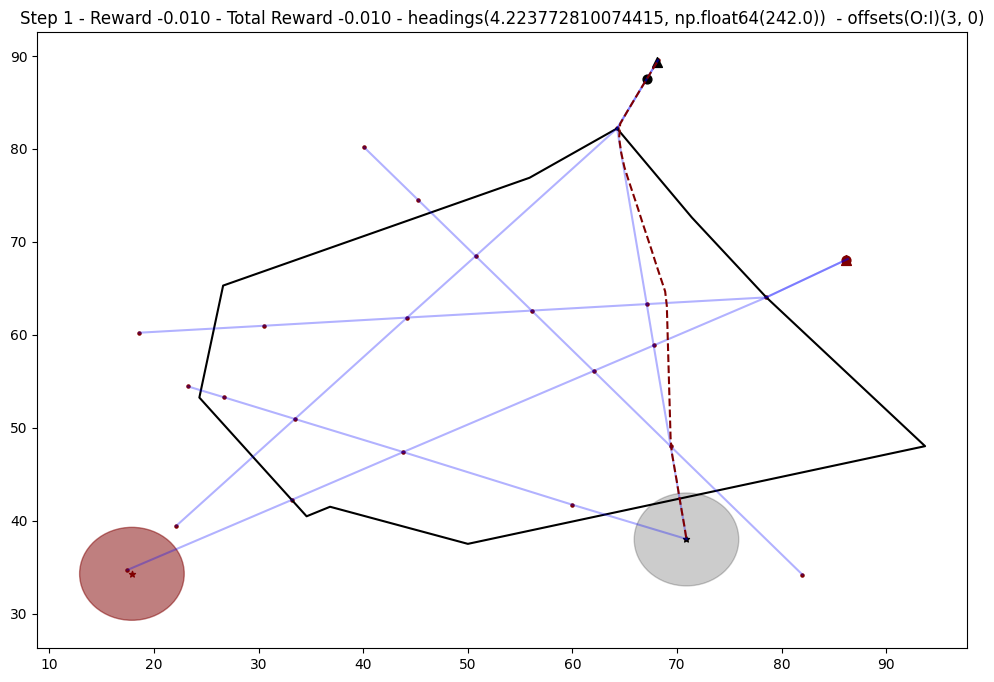

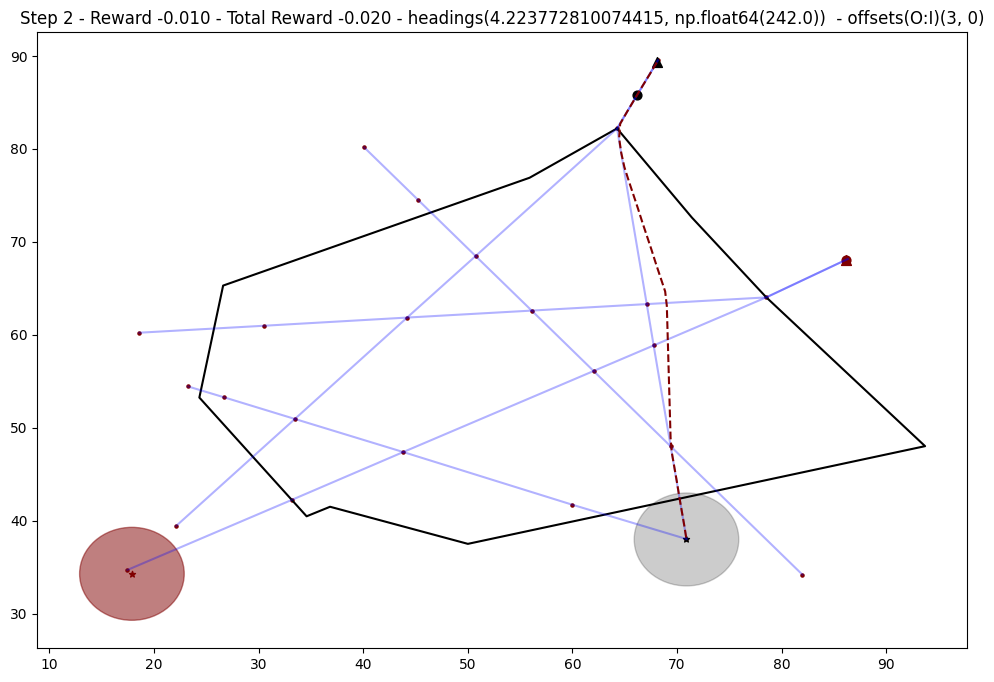

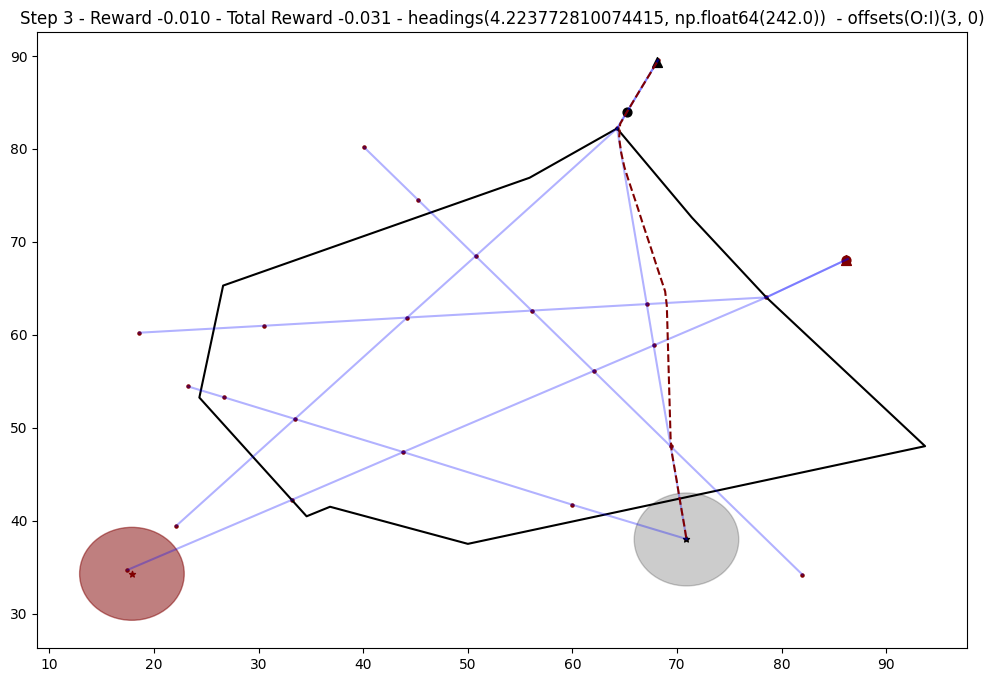

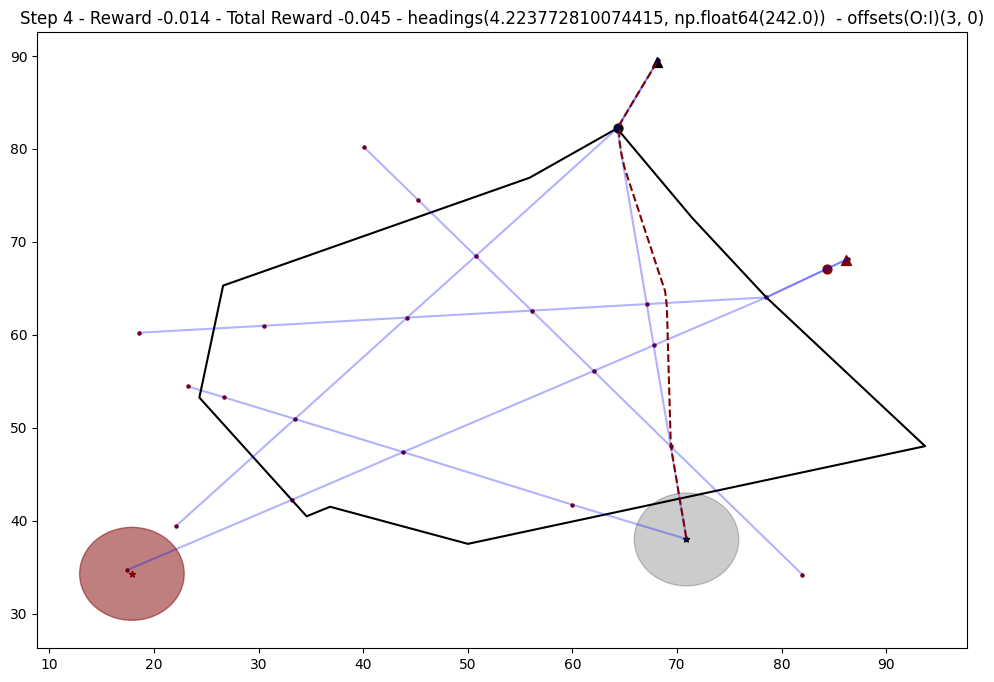

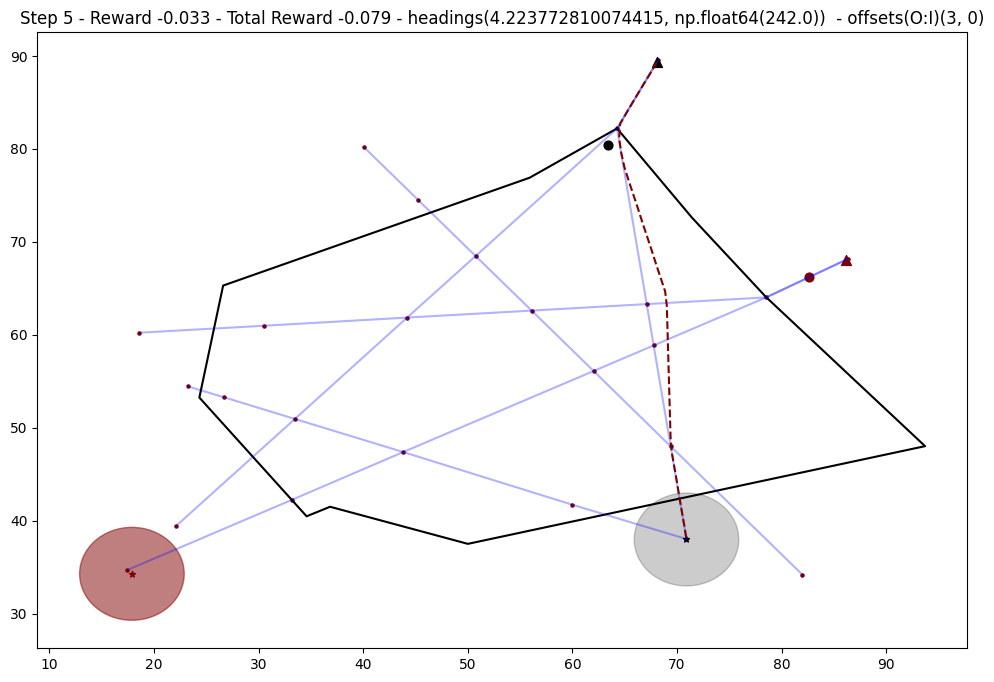

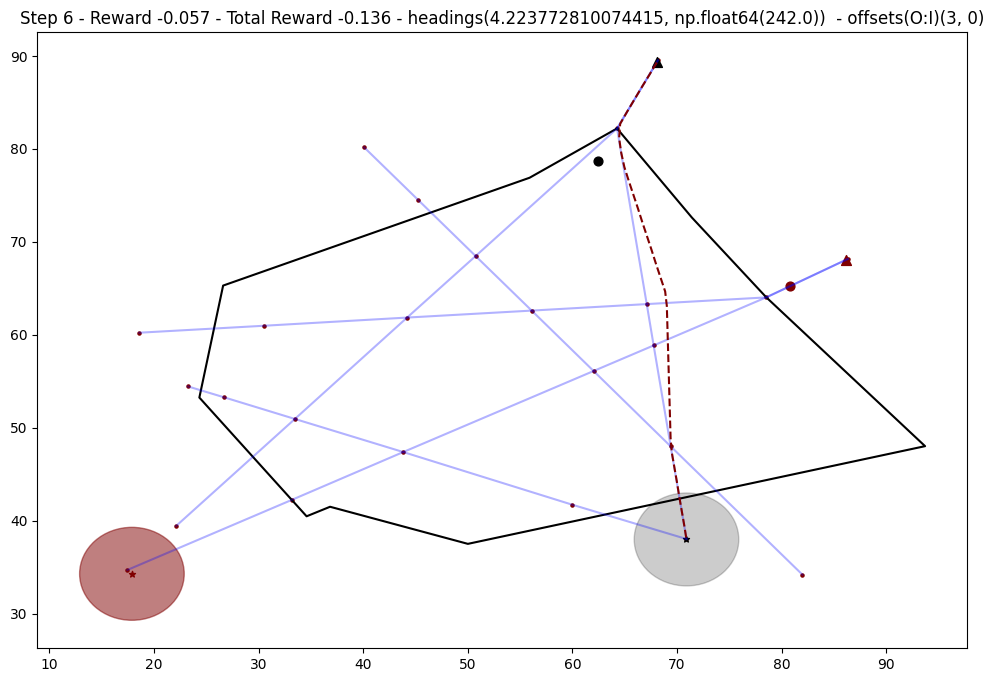

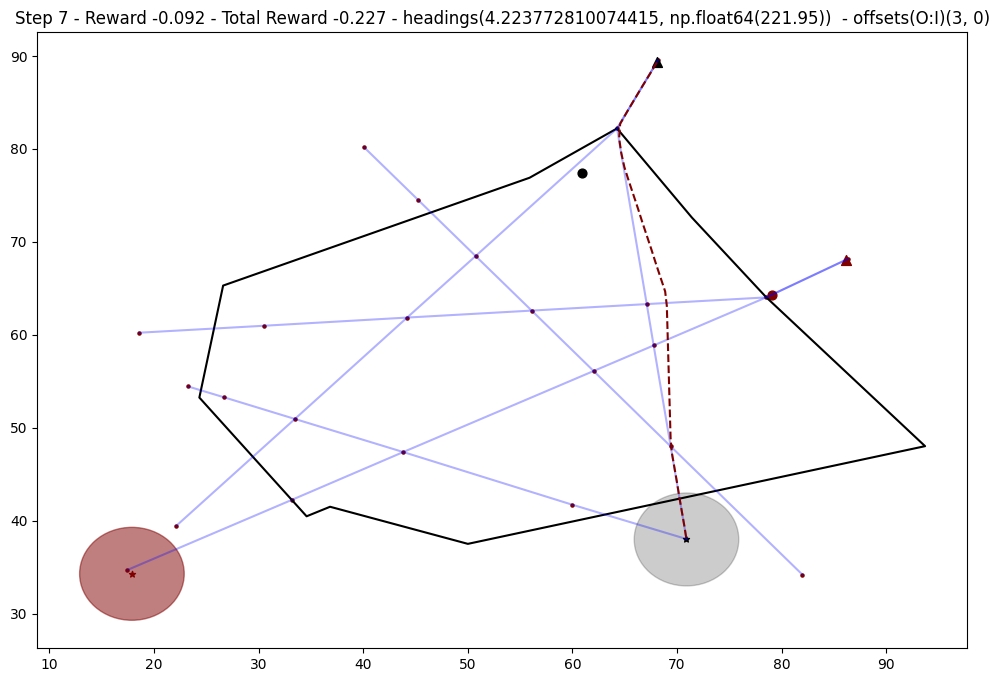

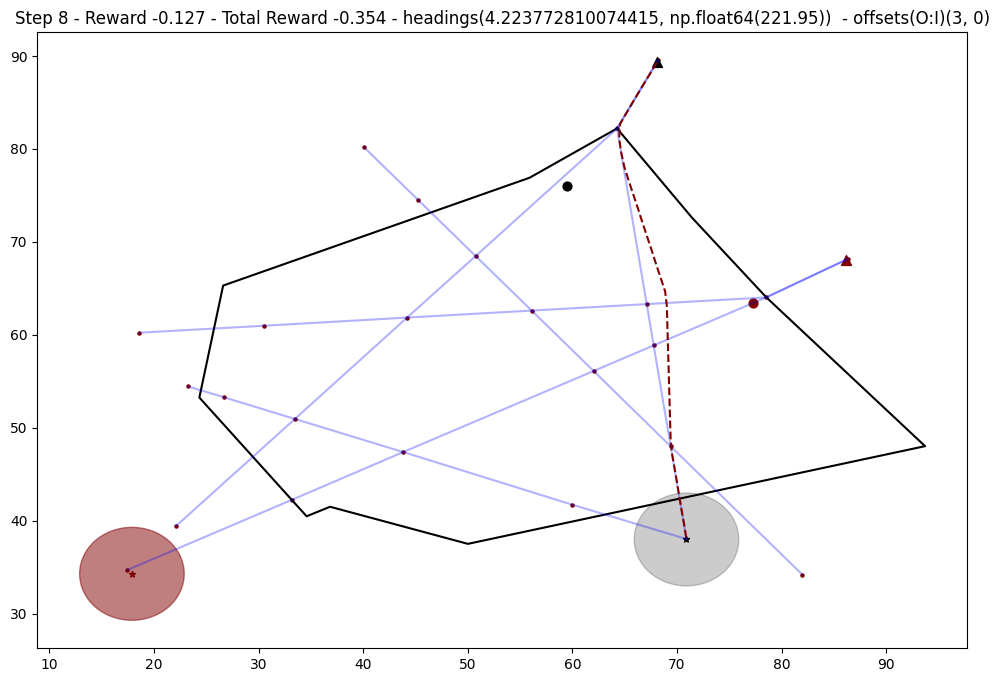

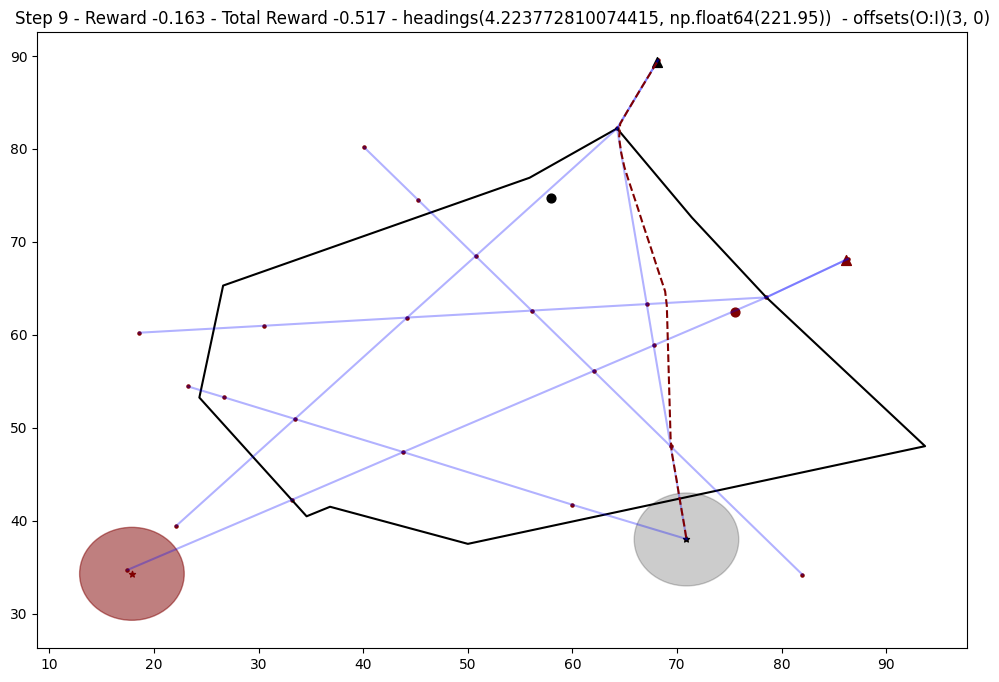

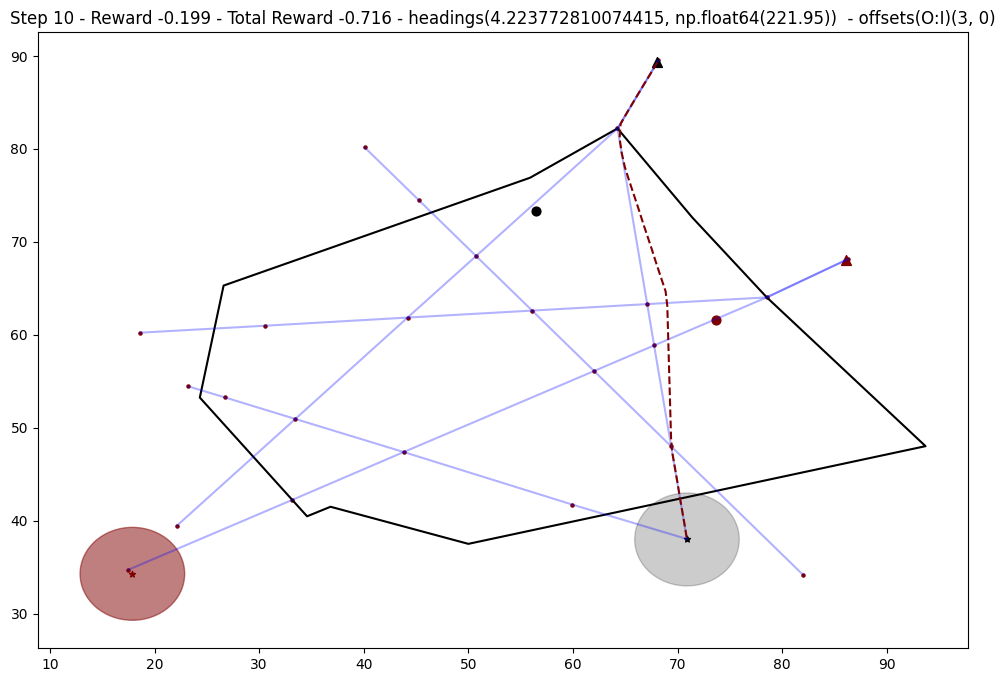

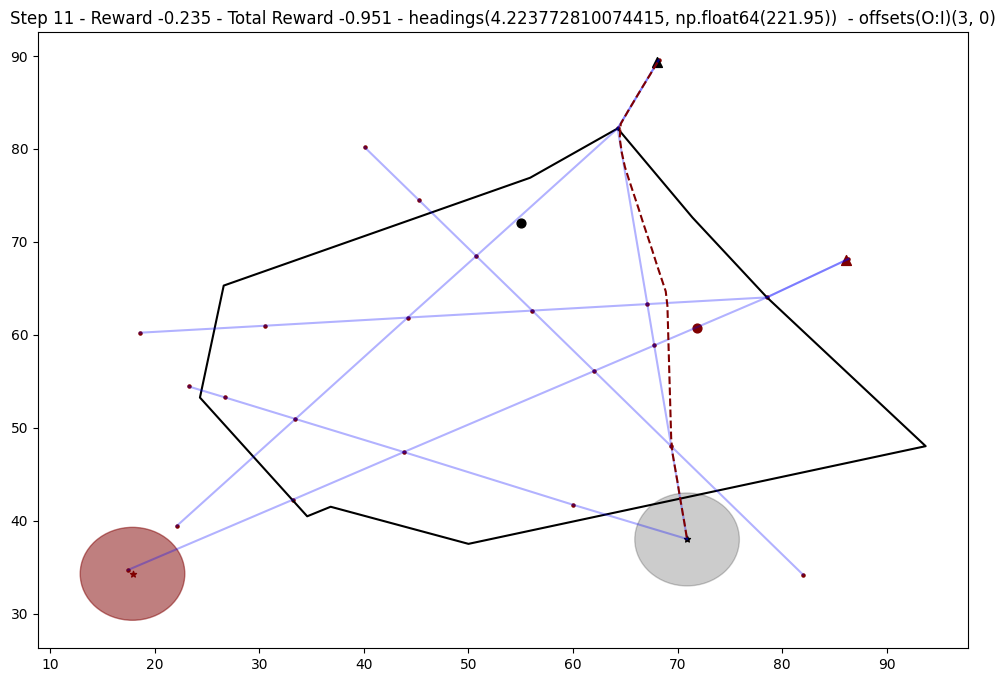

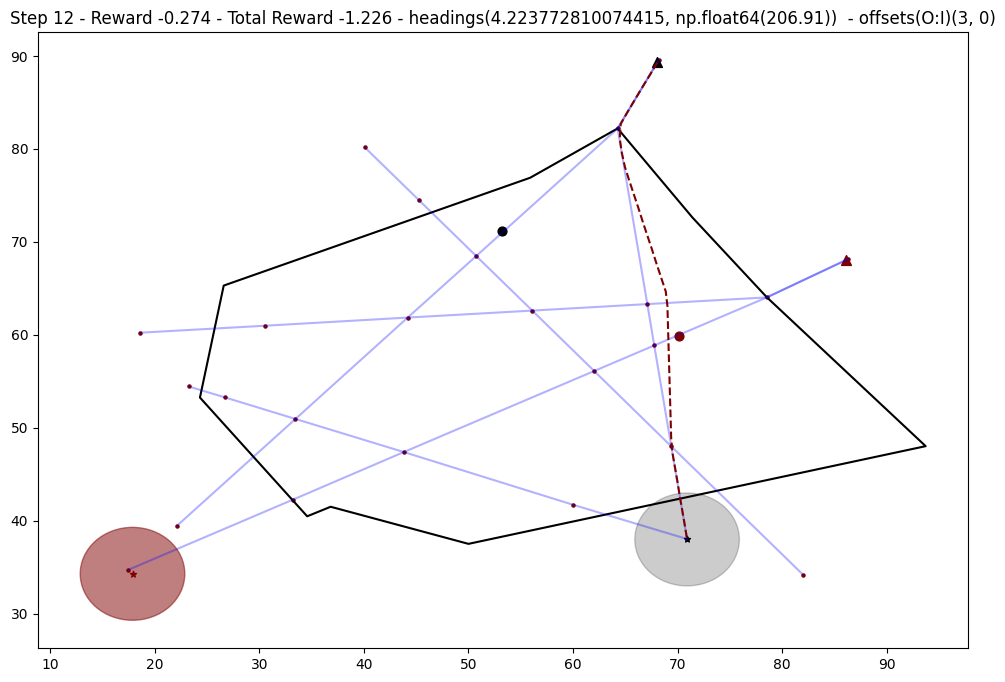

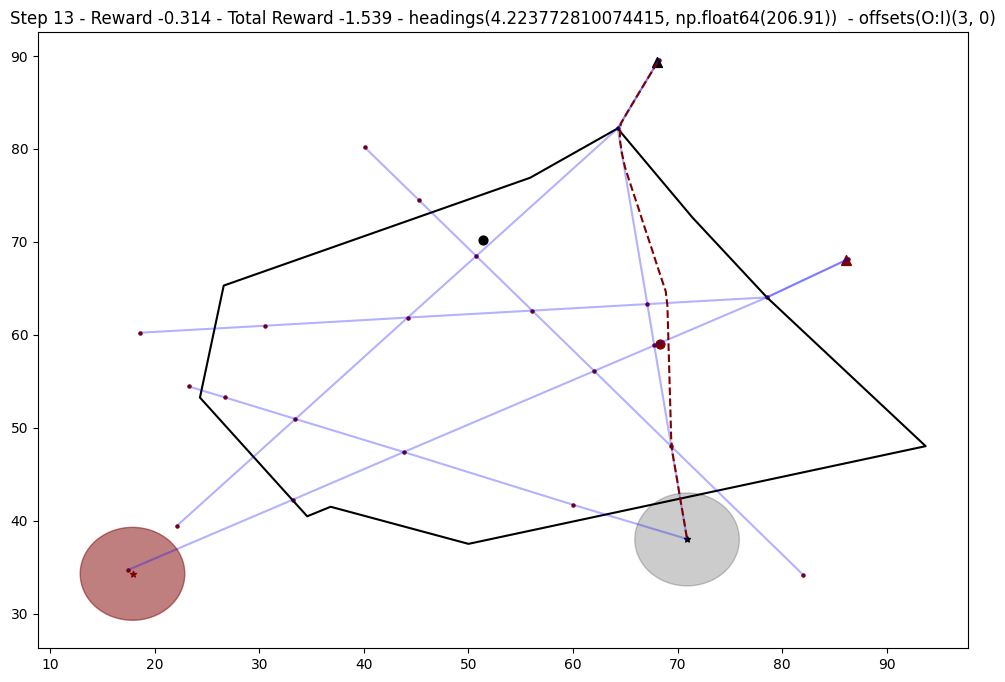

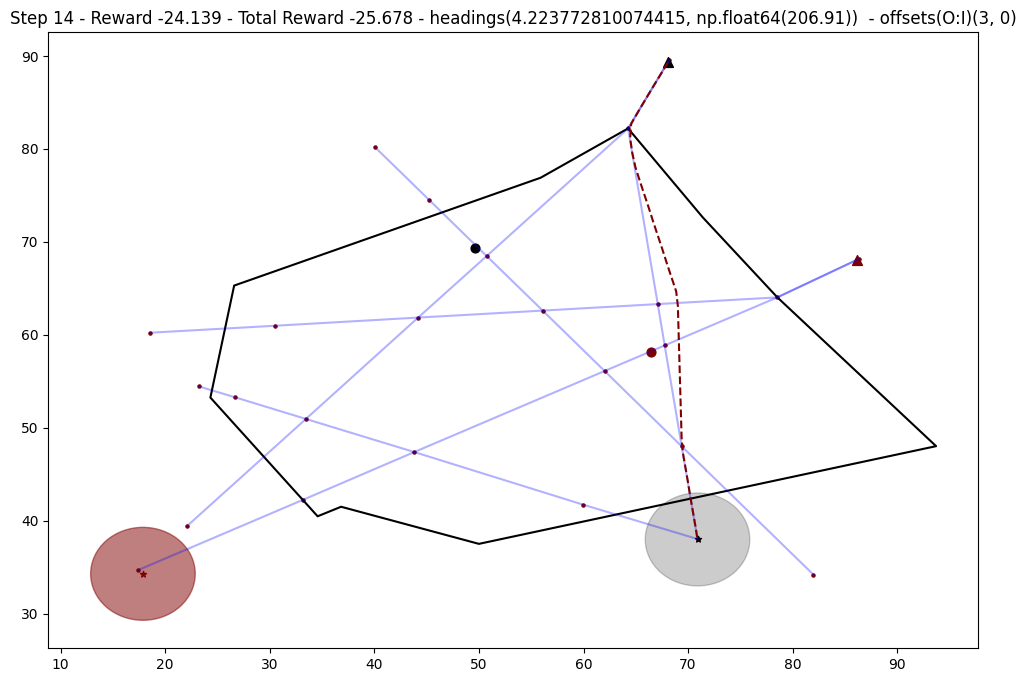

In [ ]:
# --- Phase 3: run an LLM-driven episode and save a GIF ---
import os, glob, shutil
from datetime import datetime, timezone

# --- Mapping: heading delta (deg) -> your env's discrete action index (0..12) ---
# bins are ...,-30,-25,...,0,...,25,30 (5° steps)
def _deg_to_action_idx(delta_deg: int) -> int:
    """Map ±(0,5,...,30)° to env action index:
       0..6 produce +0,+5,...,+30°, 7..12 produce -5,...,-30°."""
    d = int(round(delta_deg))
    if d % 5 != 0 or abs(d) > 30:
        raise ValueError(f"delta must be multiple of 5 and |d|<=30, got {delta_deg}")
    if d >= 0:
        return d // 5           # 0°→0, +5°→1, ..., +30°→6
    else:
        return 6 + (abs(d) // 5)  # -5°→7, ..., -30°→12

def _ensure_clean_dir(path: str):
    os.makedirs(path, exist_ok=True)
    # wipe only PNGs, keep any prior GIFs/logs
    for p in glob.glob(os.path.join(path, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

def _save_gif(frames_dir: str, out_gif_path: str, fps: float = 5.0):
    # lazy import to keep deps light
    try:
        import imageio.v2 as imageio
    except Exception as e:
        raise RuntimeError("imageio is required to write GIFs. Try: pip install imageio") from e

    frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
    if not frames:
        raise RuntimeError(f"No frames found in {frames_dir}. Did env.render() run?")
    images = [imageio.imread(f) for f in frames]
    duration = 1.0 / max(1e-6, fps)  # seconds per frame
    imageio.mimsave(out_gif_path, images, duration=duration)

def run_llm_episode_and_gif(
    *,
    max_steps: int = None,               # default: env.MAX_STEP
    gif_root: str = "LLM-driven RL",     # folder with a space, as requested
    fps: float = 5.0,                    # playback speed
):
    # --- folders ---
    run_dir = start_llm_log_dir(base_dir="json_answers")   # <-- NEW
    frames_dir = os.path.join(gif_root, "frames")
    os.makedirs(gif_root, exist_ok=True)
    _ensure_clean_dir(frames_dir)

    # --- build env / prompt builder / controller ---
    env = StructuredEnv()
    builder = BasePromptBuilder()
    ctl = LLMGuidanceController(builder=builder, k_history=5, save_dir=run_dir)  # <-- pass run_dir
    ctl.reset(initial_phase="WAIT_TURN")

    # --- reset env & get initial obs ---
    obs, _info = env.reset()
    step_cap = max_steps if max_steps is not None else env.MAX_STEP

    # --- loop ---
    terminated = False
    truncated = False
    while not (terminated or truncated):
        # Ask controller what to do for THIS step
        delta_deg, _state = ctl.next_action(obs, step=env.n_step)

        # Convert delta (deg) to your env's discrete action index
        try:
            action_idx = _deg_to_action_idx(delta_deg)
        except ValueError:
            # Safety net: if something odd slips through, do "no change"
            print(f"[WARN] Invalid delta {delta_deg}; sending action 0 (no turn).")
            action_idx = 0

        # Step env
        obs, reward, terminated, truncated, info = env.step(action_idx)

        # Render a frame
        env.render(show=False, folder=frames_dir + "/")

        # Stop if we hit the step cap (extra guard)
        if env.n_step >= step_cap:
            truncated = True

    # --- write GIF ---
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    out_gif = os.path.join(gif_root, f"{ts}_episode.gif")
    _save_gif(frames_dir, out_gif, fps=fps)
    print(f"GIF saved → {out_gif}")
    return out_gif

# ---- RUN ONCE (creates frames + GIF) ----
gif_path = run_llm_episode_and_gif(fps=5.0)  # ~5 frames/sec
print("Done:", gif_path)

NoLLM/frames/image_001.png
NoLLM/frames/image_002.png
NoLLM/frames/image_003.png
NoLLM/frames/image_004.png
NoLLM/frames/image_005.png
NoLLM/frames/image_006.png
NoLLM/frames/image_007.png
NoLLM/frames/image_008.png
NoLLM/frames/image_009.png
NoLLM/frames/image_010.png
NoLLM/frames/image_011.png
NoLLM/frames/image_012.png
NoLLM/frames/image_013.png
NoLLM/frames/image_014.png
NoLLM/frames/image_015.png
NoLLM/frames/image_016.png
NoLLM/frames/image_017.png
NoLLM/frames/image_018.png
NoLLM/frames/image_019.png
NoLLM/frames/image_020.png
GIF saved → NoLLM/20250814T093959Z_no_llm.gif
Done: NoLLM/20250814T093959Z_no_llm.gif


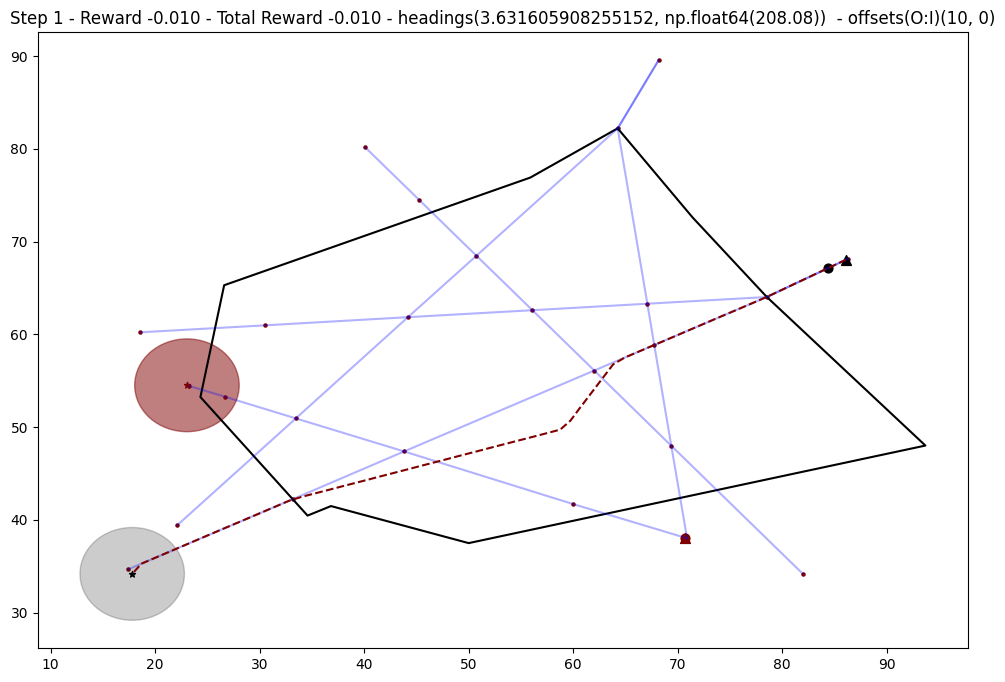

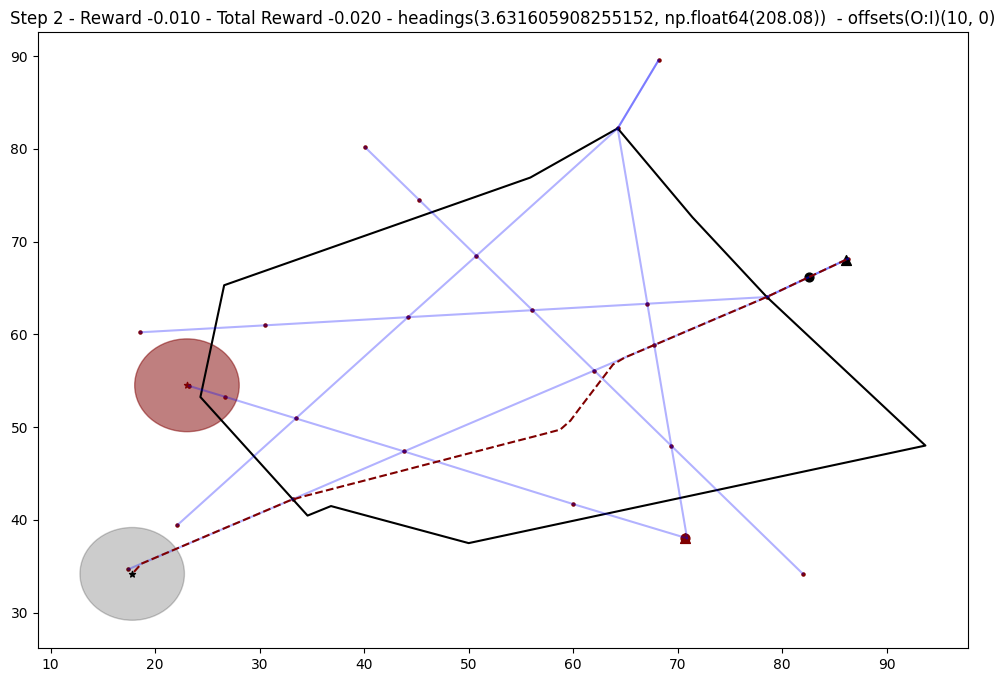

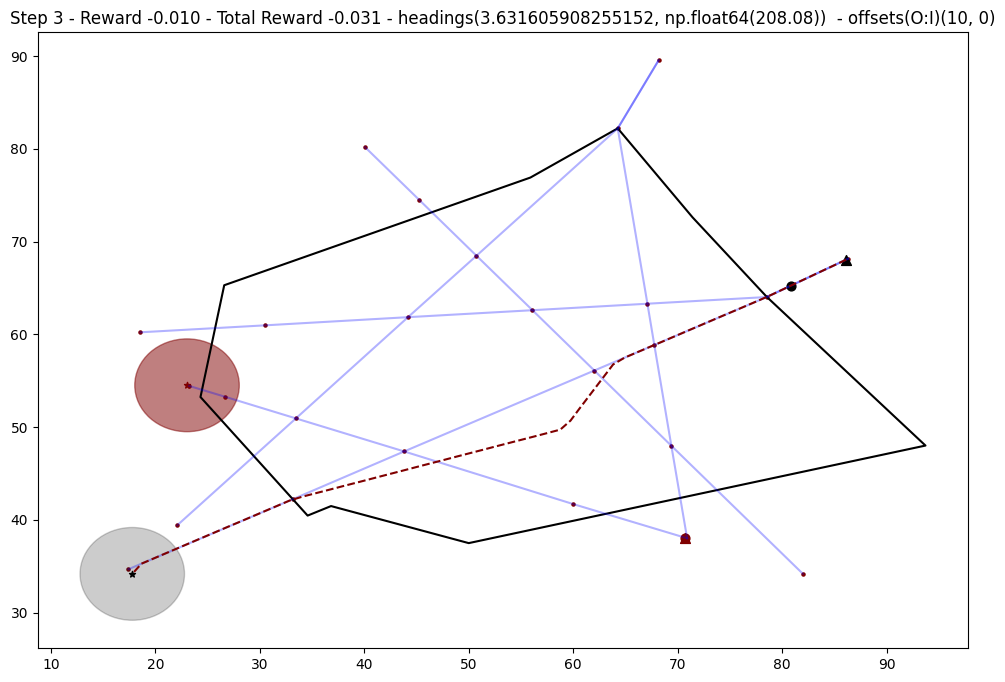

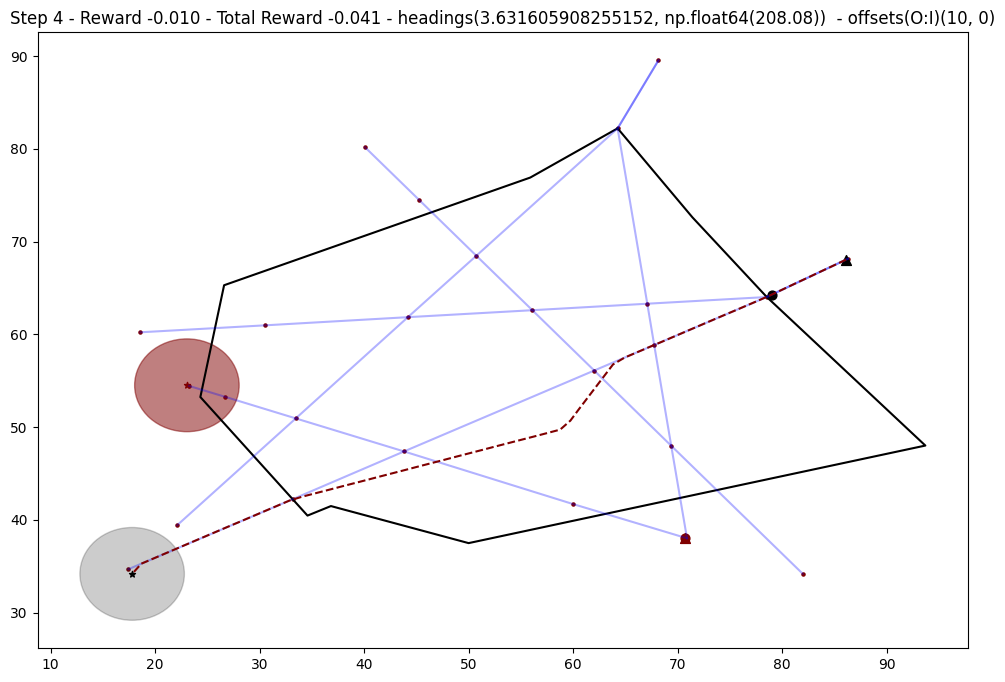

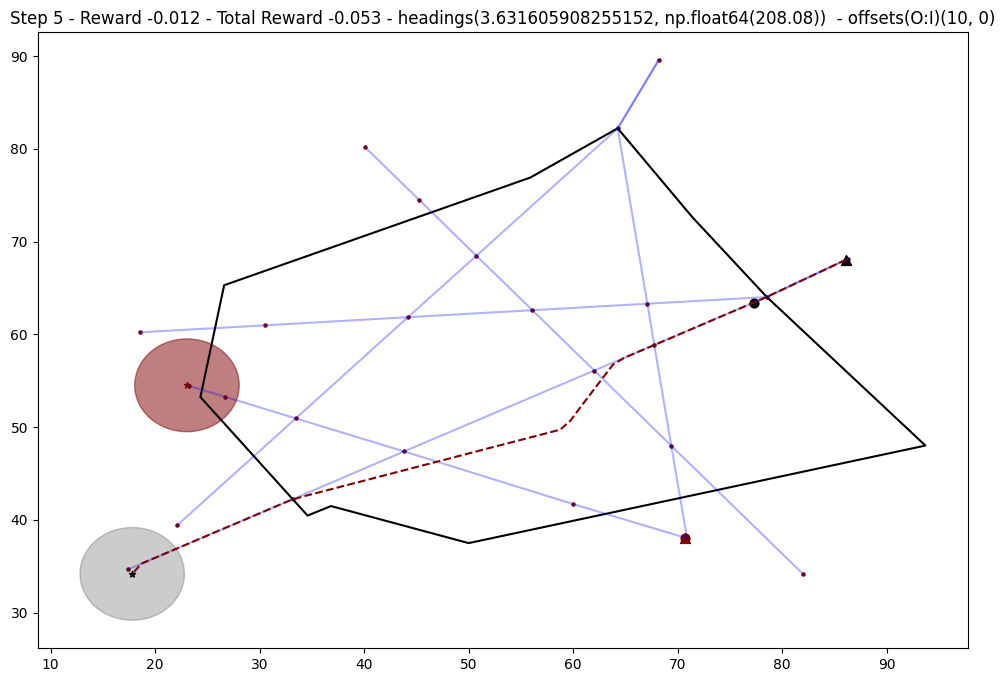

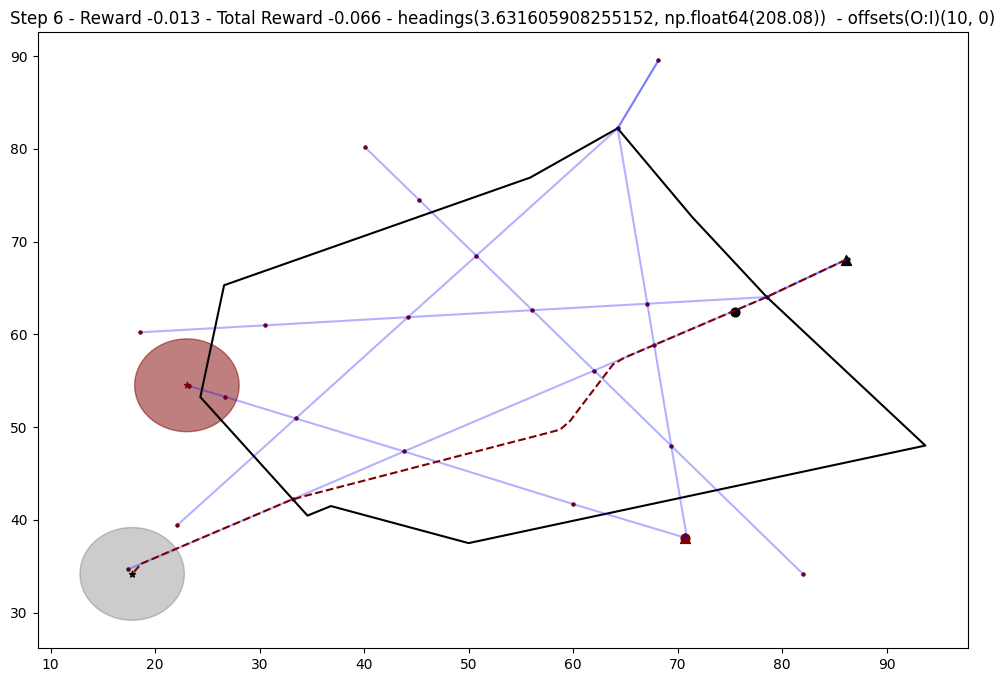

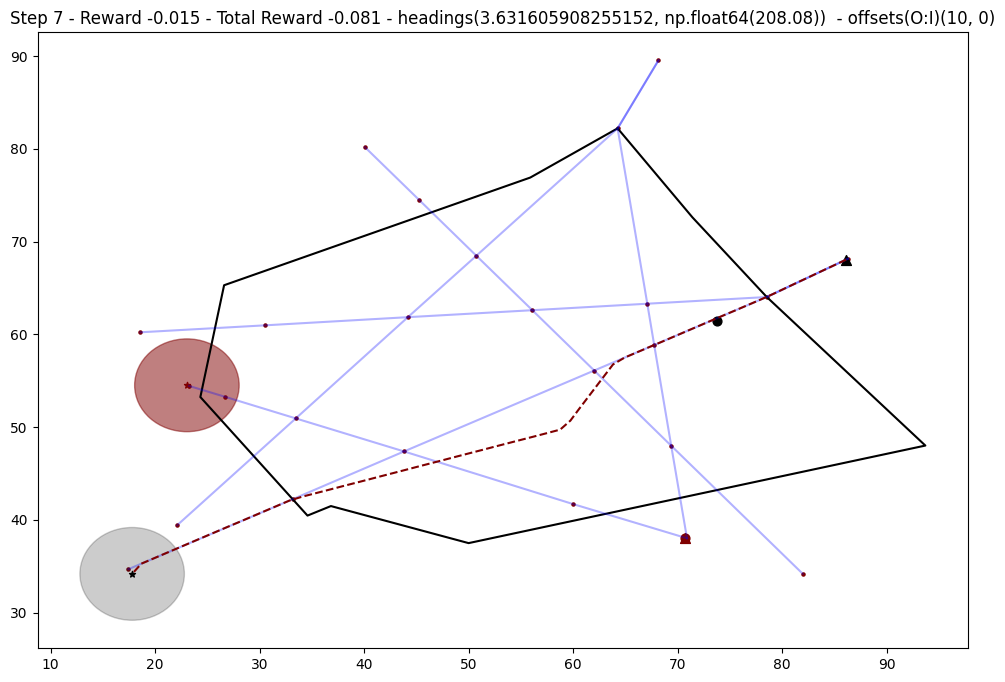

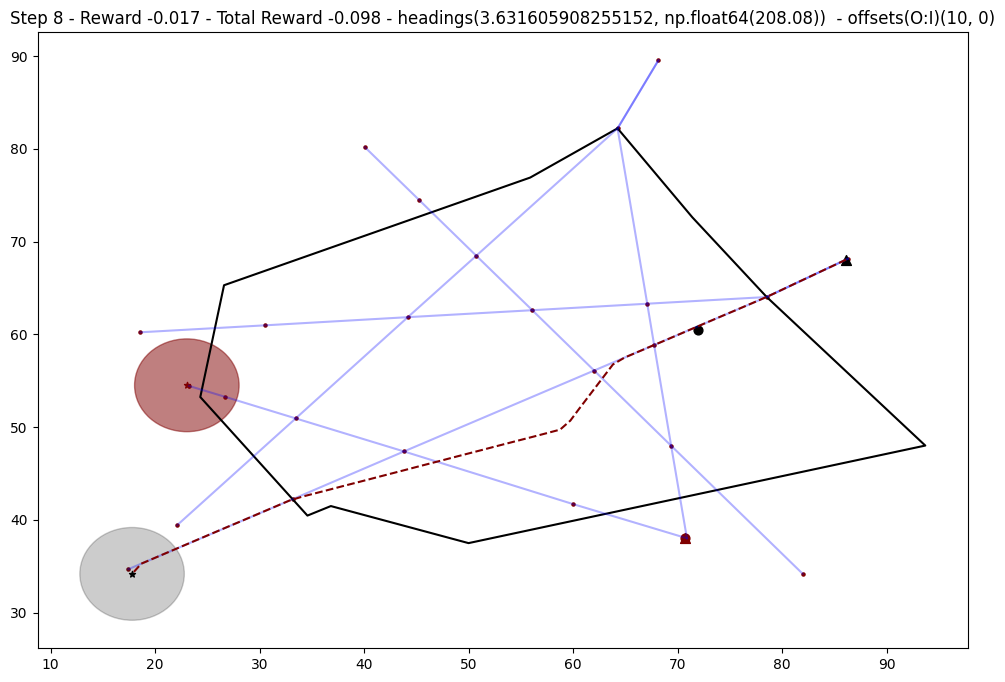

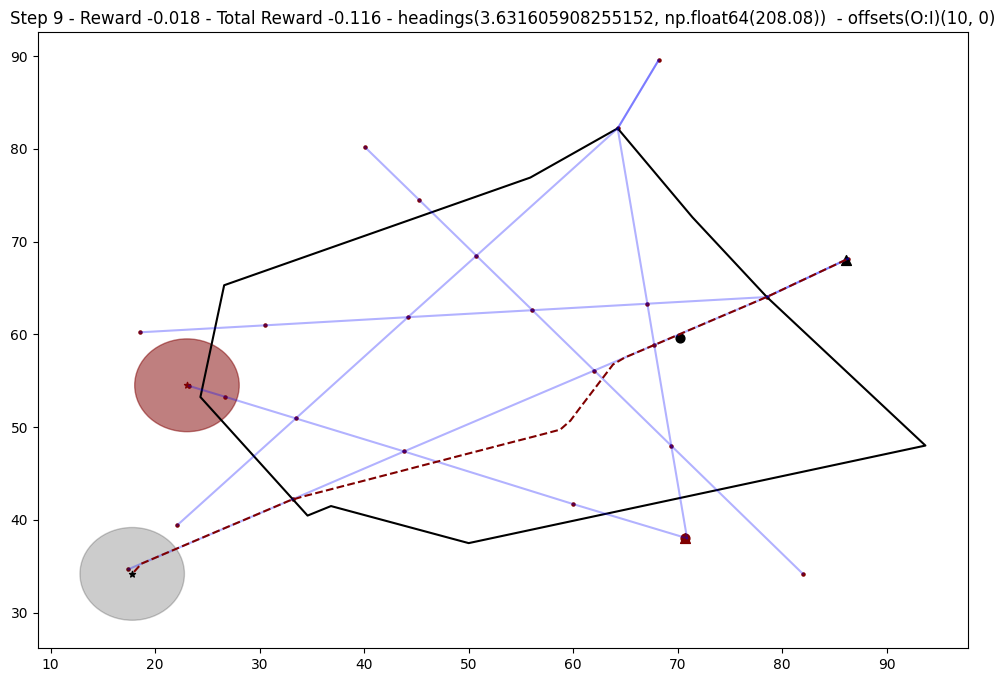

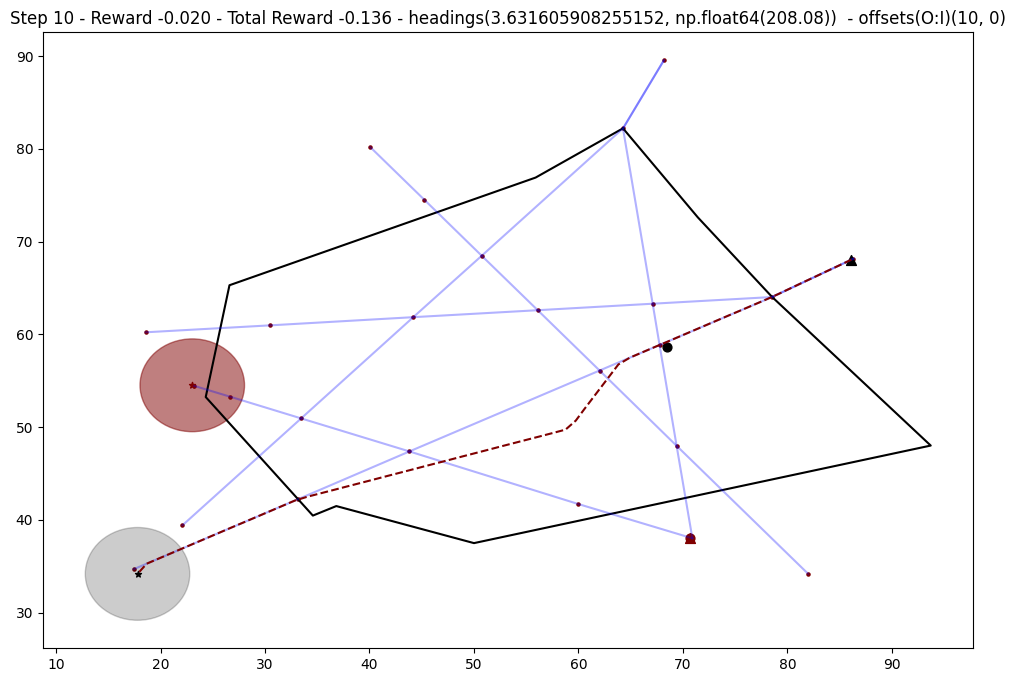

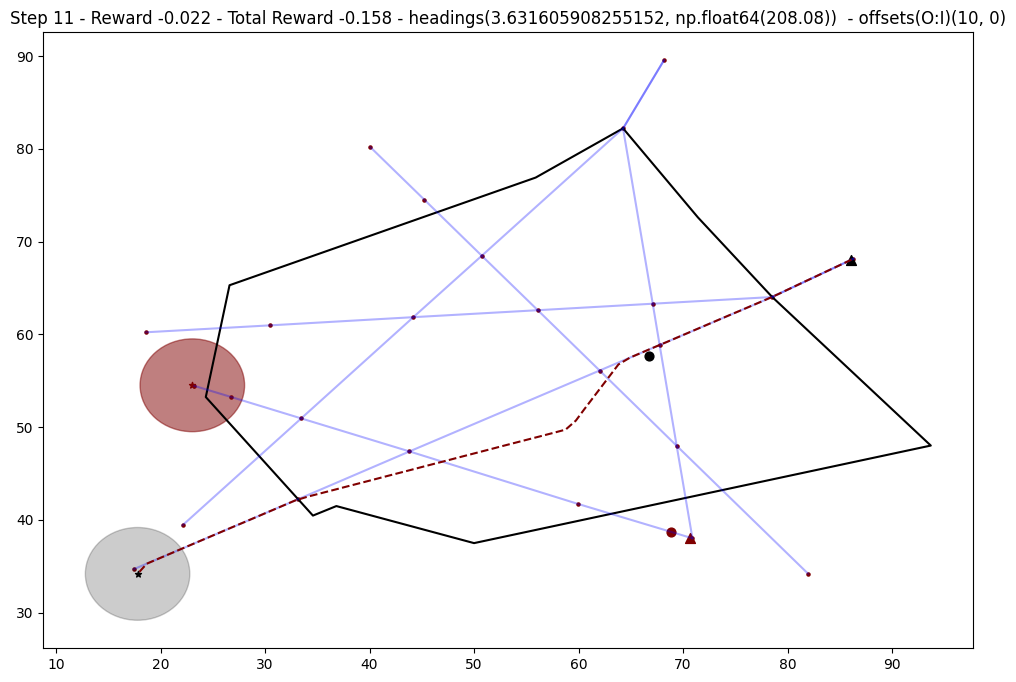

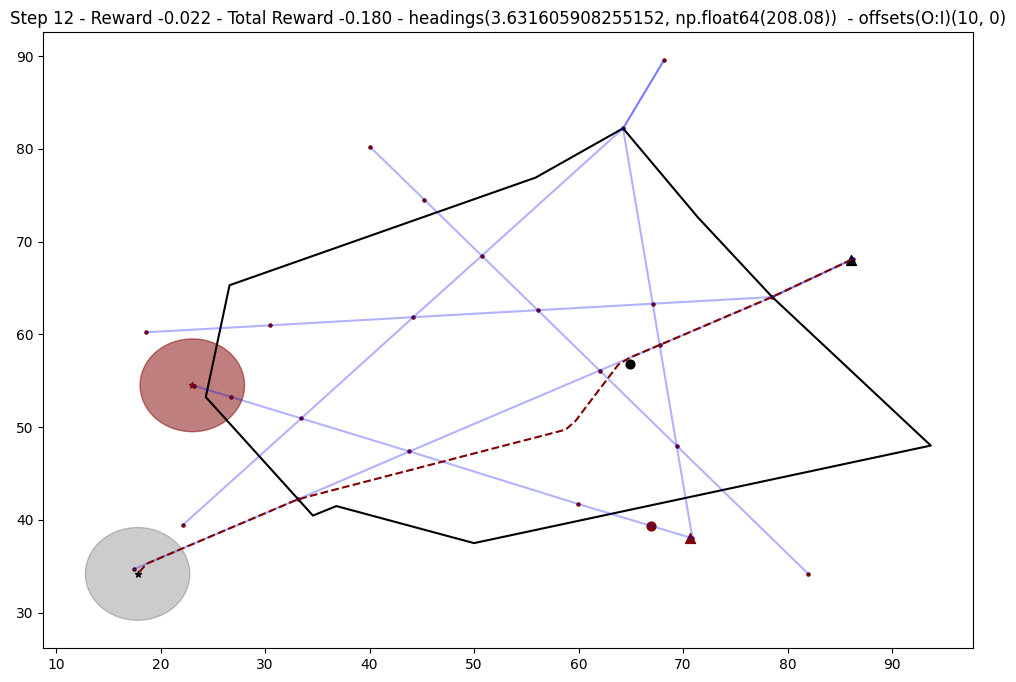

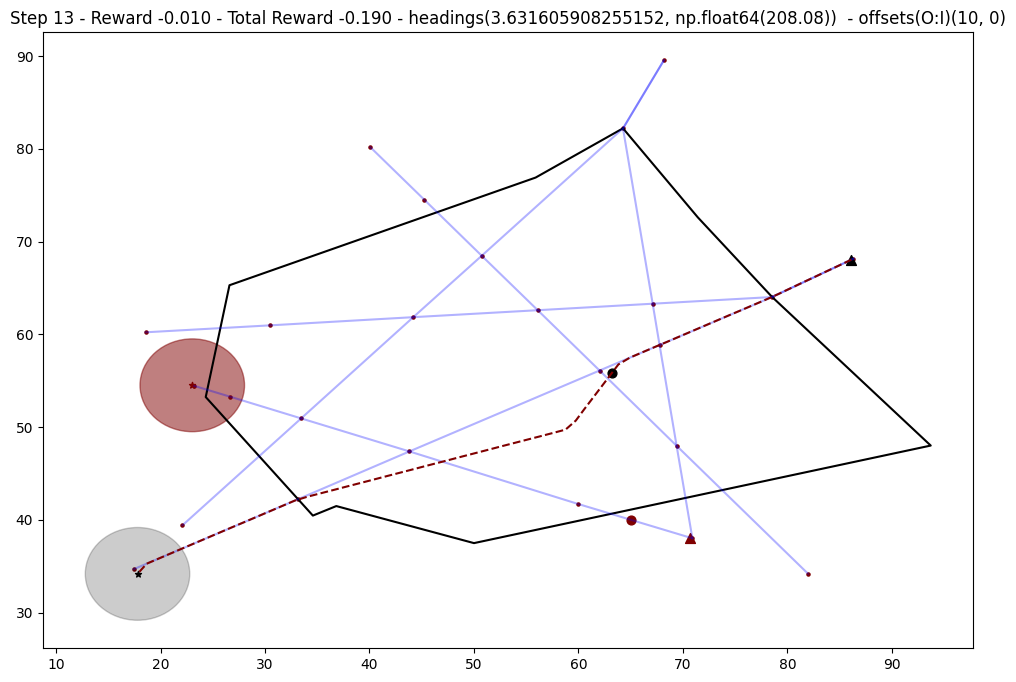

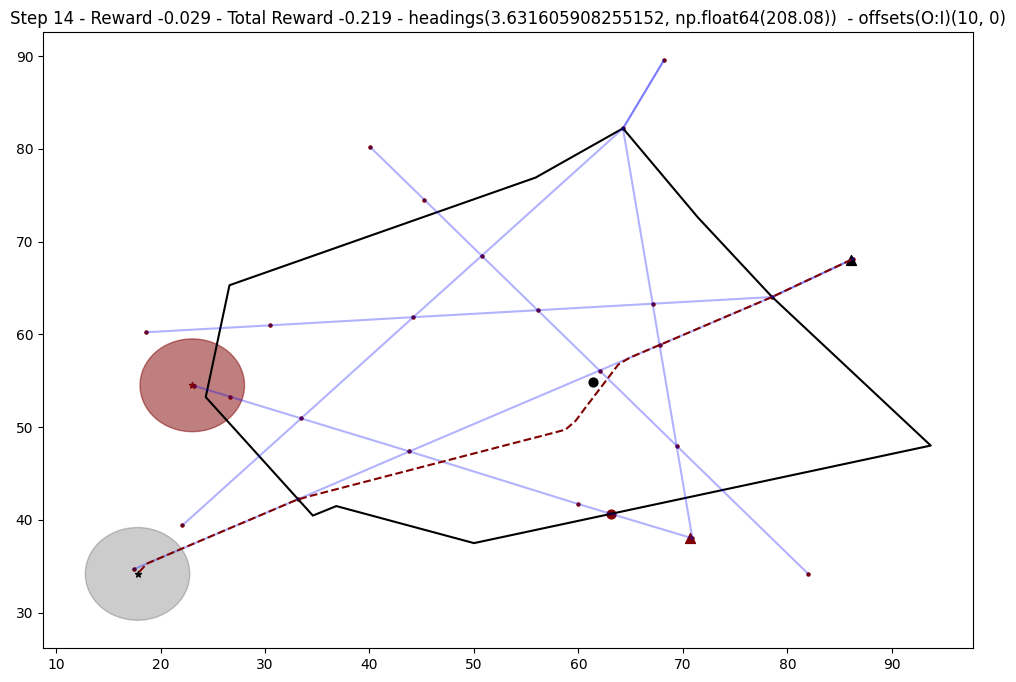

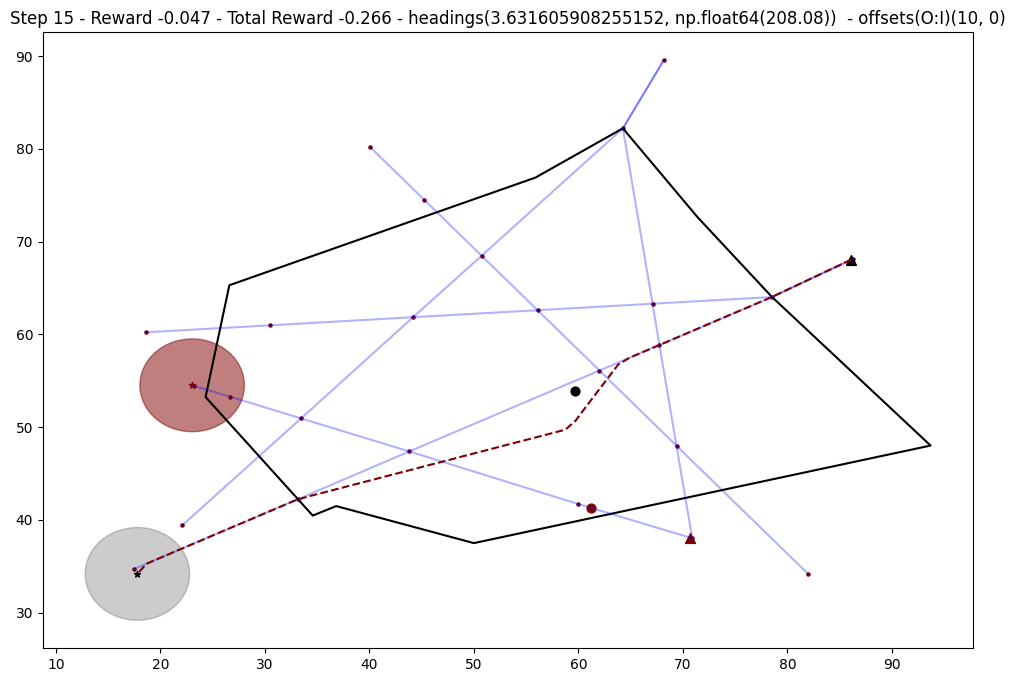

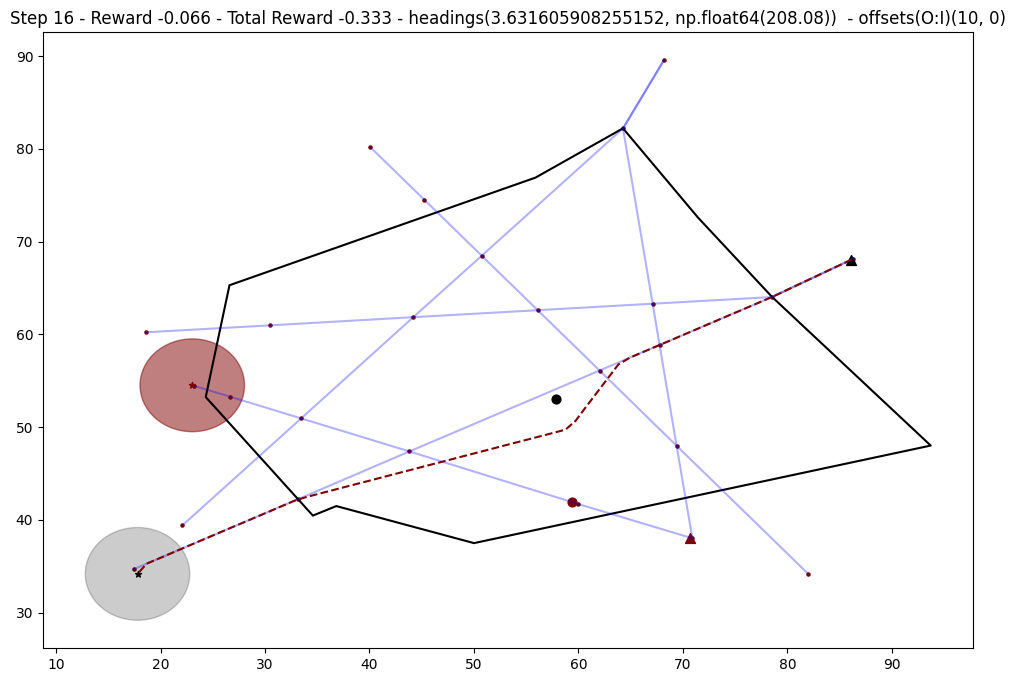

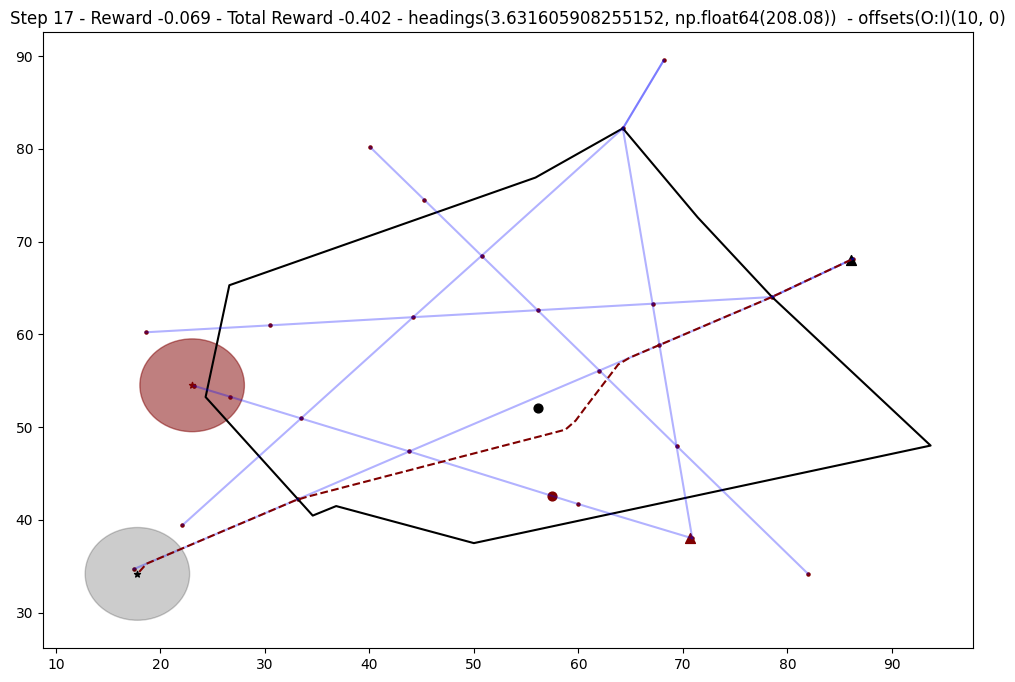

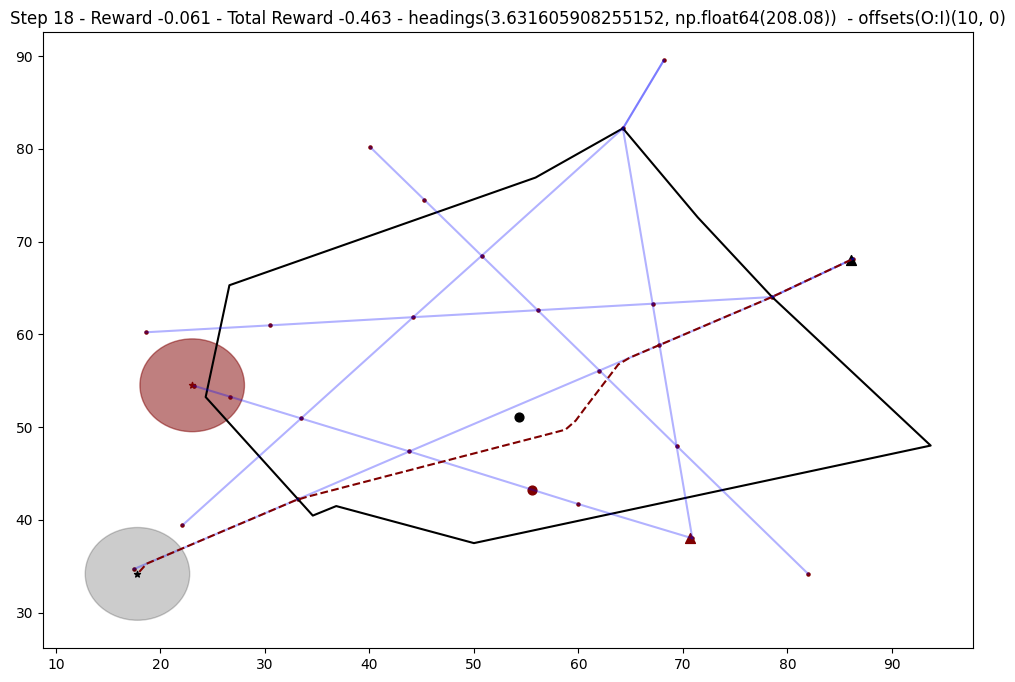

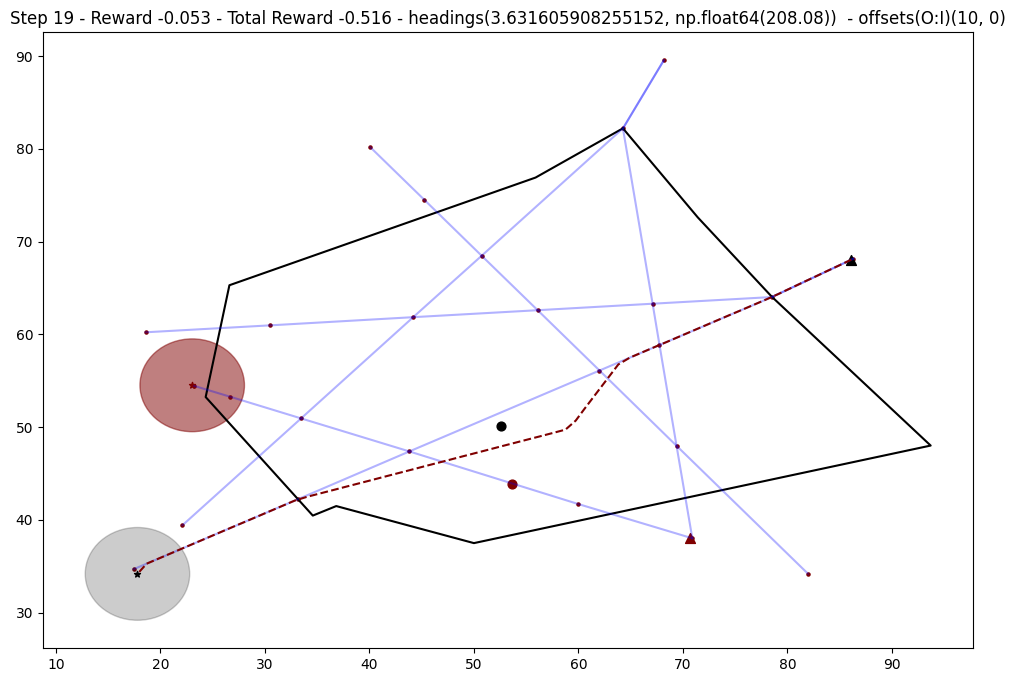

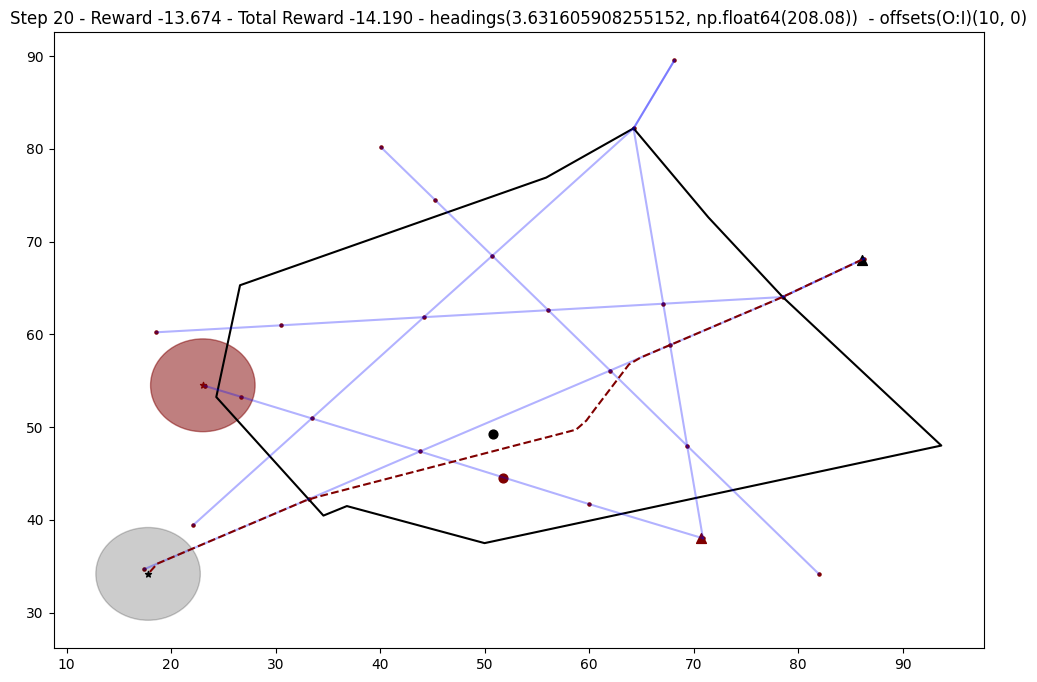

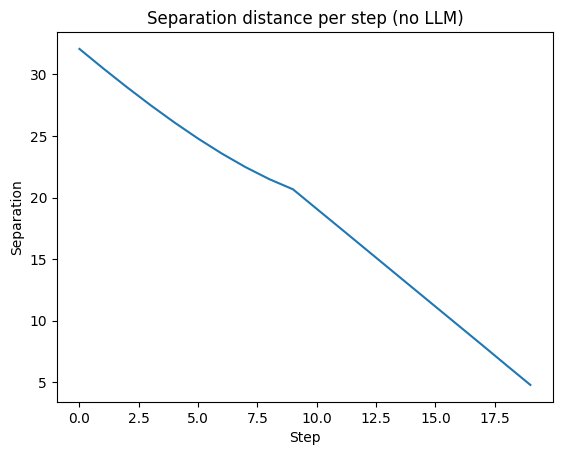

In [17]:
# === Baseline simulation with NO LLM actions (always fly straight) ===
# Drop this in a new cell after StructuredEnv and its helpers are defined.

import os, glob
from datetime import datetime, timezone

# If imageio isn't installed in your env: pip install imageio
import imageio.v2 as imageio
import matplotlib.pyplot as plt

def _ensure_clean_dir(path: str):
    os.makedirs(path, exist_ok=True)
    # Remove only previously rendered frames to keep folder tidy
    for p in glob.glob(os.path.join(path, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

def run_no_llm_episode_and_gif(
    *,
    max_steps: int = None,        # default = env.MAX_STEP
    gif_root: str = "NoLLM",      # output folder for GIF + frames/
    fps: float = 5.0              # playback speed
):
    frames_dir = os.path.join(gif_root, "frames")
    os.makedirs(gif_root, exist_ok=True)
    _ensure_clean_dir(frames_dir)

    # --- build env and reset ---
    env = StructuredEnv()
    obs, _info = env.reset()
    step_cap = max_steps if max_steps is not None else env.MAX_STEP

    terminated = False
    truncated  = False
    separations = []

    # NOTE: action=0 corresponds to "no heading change" in your env
    while not (terminated or truncated):
        action_idx = 0  # keep flying straight
        obs, reward, terminated, truncated, info = env.step(action_idx)

        # Log separation distance; per your observation_func this is obs[6]
        separations.append(float(obs[6]))

        # Save a frame
        env.render(show=False, folder=frames_dir + "/")

        if env.n_step >= step_cap:
            truncated = True

    # --- write GIF ---
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    out_gif = os.path.join(gif_root, f"{ts}_no_llm.gif")

    frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
    if not frames:
        raise RuntimeError("No frames found; did env.render() run?")
    images = [imageio.imread(f) for f in frames]
    imageio.mimsave(out_gif, images, duration=1.0 / max(1e-6, fps))
    print(f"GIF saved → {out_gif}")

    return out_gif, separations

# ---- RUN ONCE (creates frames + GIF) ----
gif_path, sep_series = run_no_llm_episode_and_gif(fps=5.0)
print("Done:", gif_path)

# (Optional) quick look at separation over time
plt.figure()
plt.plot(sep_series)
plt.title("Separation distance per step (no LLM)")
plt.xlabel("Step")
plt.ylabel("Separation")
plt.show()


In [71]:
import pandas as pd
from collections import deque

builder = BasePromptBuilder()

# Gather 4 past observations
history = deque(maxlen=5)

obs, _ = env.reset()
step_idx = 0

# fill history with 4 prior snapshots
for _ in range(10):
    history.append(obs.copy())                   # store past obs
    action = env.action_space.sample()           # random step just to create history
    obs, reward, term, trunc, _ = env.step(action)
    step_idx += 1
    if term or trunc:
        break

current_obs = obs
prev_obs    = history[-1]                        # last snapshot before current

history_vectors = list(history)                  # oldest → newest (does NOT include current)
history_steps   = list(range(step_idx - len(history), step_idx))

# Build the prompt (assuming you UNcommented _bc_baseline_text inside build_base_prompt)
prompt = builder.build_base_prompt(
    obs_vector=current_obs,
    step=step_idx,
    prev_obs_vector=prev_obs,
    prev_step=step_idx - 1,
    history_vectors=history_vectors,
    history_steps=history_steps,
)

print(prompt)


ROLE: You are an ATCO planning assistant for a single sector. Read the situation (current observation, recent history, ATCO baseline stats) and:
  (1) summarize the current scenario, and
  (2) recommend ONE discrete heading change and a hold duration for the current phase.

FOUR-PHASE PLAN (controller will provide PHASE STATE below):
- WAIT_TURN (N1): Observe only. Command must be 0°; choose how long to hold (watch) before any turn.
- EXECUTE_TURN (N2): Make a single discrete turn that starts opening separation; then hold it for a few steps.
- MERGE_BACK (N3): Turn to reduce cross-track and rejoin toward route/destination; then hold.
- CRUISE (N4): Fly straight (0°) unless a small correction (±5/±10°) is needed for alignment; then hold.

ASSUMPTIONS:
- Distances are in scenario units. One 'step' is one environment step.
- Headings: 0° = east; positive = left/CCW; negative = right/CW.
- Intruder relative bearing is from ownship’s nose; smaller |bearing| is more nose-on (riskier).

DECIS

In [ ]:

# Create writer AFTER resume so TensorBoard continues correctly
writer = SummaryWriter(log_dir, purge_step=time_step)
print("Starting training...")

# 5. Training Loop (GPU-Compatible)
# Hyperparameters
max_timesteps   = 5000000
update_timestep = 2048
eval_freq       = 5000
n_eval_episodes = 10
save_model_freq = 500000

# --- Resume if last.ckpt exists ---
try:
    while time_step < max_timesteps:
        obs, _ = env.reset()
        done = False
        ep_reward = 0.0

        for t in range(1, env.MAX_STEP + 1):
            action = ppo_agent.select_action(obs)
            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc

            ppo_agent.buffer.rewards.append(reward)
            ppo_agent.buffer.is_terminals.append(done)

            ep_reward += reward
            time_step += 1

            # 3) PPO update
            if time_step % update_timestep == 0:
                ppo_agent.update()
                # ---- save last checkpoint after each update ----
                save_training_checkpoint(last_ckpt_path, ppo_agent, time_step, episode)

            # 4) Periodic evaluation & best-model checkpoint
            if time_step % eval_freq == 0:
                mean_ret, std_ret = evaluate_policy(ppo_agent, env, n_eval_episodes)
                writer.add_scalar("eval/mean_reward", mean_ret, time_step)
                writer.add_scalar("eval/std_reward",  std_ret, time_step)
                # optional: also save last here (cheap)
                save_training_checkpoint(last_ckpt_path, ppo_agent, time_step, episode)
                if mean_ret > best_mean_reward:
                    best_mean_reward = mean_ret
                    ppo_agent.save(best_model_path)
                    print(f"[{time_step}] New best mean reward: {mean_ret:.2f} → saved")

            # 5) Periodic weight-only checkpoint (unchanged)
            if time_step % save_model_freq == 0:
                path = os.path.join(log_dir, f"checkpoint_{time_step}.pth")
                ppo_agent.save(path)
                print(f"[{time_step}] Checkpoint saved to {path}")

            if done:
                break

        episode += 1
        writer.add_scalar("train/episode_reward", ep_reward, episode)
        writer.add_scalar("train/steps_per_episode", t, episode)

        if episode % 10 == 0:
            elapsed = datetime.now() - start_time
            print(f"Episode {episode} | Step {time_step} | Ep Reward {ep_reward:.2f} | Elapsed {elapsed}")

except KeyboardInterrupt:
    # emergency save on manual stop
    emergency = os.path.join(log_dir, "interrupted.ckpt")
    save_training_checkpoint(emergency, ppo_agent, time_step, episode)
    print(f"\nInterrupted — saved {emergency}")
    raise
except Exception as e:
    # save and re-raise unexpected errors
    emergency = os.path.join(log_dir, "interrupted.ckpt")
    save_training_checkpoint(emergency, ppo_agent, time_step, episode)
    print(f"\nCrashed — saved {emergency}")
    raise
finally:
    writer.close()
    print("Training complete in", datetime.now() - start_time)
    print("Best model saved at", best_model_path)

Episode 10 | Step 193 | Ep Reward -24.15 | Elapsed 0:00:03.358118
Episode 20 | Step 344 | Ep Reward -27.34 | Elapsed 0:00:04.707292
Episode 30 | Step 487 | Ep Reward -24.75 | Elapsed 0:00:06.702627
Episode 40 | Step 662 | Ep Reward -14.17 | Elapsed 0:00:08.486979
Episode 50 | Step 828 | Ep Reward -26.71 | Elapsed 0:00:10.633450
Episode 60 | Step 927 | Ep Reward -26.31 | Elapsed 0:00:12.094364
Episode 70 | Step 1091 | Ep Reward -25.15 | Elapsed 0:00:13.980293
Episode 80 | Step 1220 | Ep Reward -25.43 | Elapsed 0:00:15.921302
Episode 90 | Step 1401 | Ep Reward -13.38 | Elapsed 0:00:17.448113
Episode 100 | Step 1643 | Ep Reward -24.37 | Elapsed 0:00:19.993362
Episode 110 | Step 1827 | Ep Reward -25.71 | Elapsed 0:00:22.182996
Episode 120 | Step 1962 | Ep Reward -27.82 | Elapsed 0:00:23.900015
Episode 130 | Step 2092 | Ep Reward -26.69 | Elapsed 0:00:26.743356
Episode 140 | Step 2224 | Ep Reward -16.60 | Elapsed 0:00:28.288664
Episode 150 | Step 2461 | Ep Reward -28.94 | Elapsed 0:00:31.11

Evaluation Code

Loaded checkpoint from /home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v2/best_model.pth
./images2/image_001.png
./images2/image_002.png
./images2/image_003.png
./images2/image_004.png
./images2/image_005.png
./images2/image_006.png
./images2/image_007.png
./images2/image_008.png
./images2/image_009.png
./images2/image_010.png
./images2/image_011.png
./images2/image_012.png
./images2/image_013.png
./images2/image_014.png
Saved evaluation GIF to ./images2/env_PPO_evaluation_11th_august_2025.gif


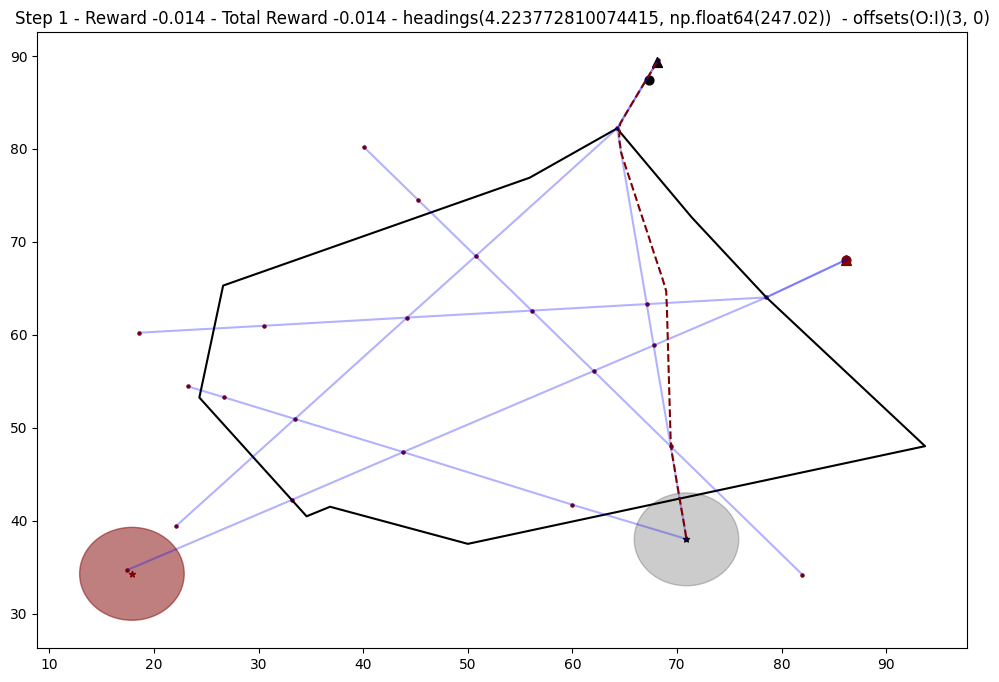

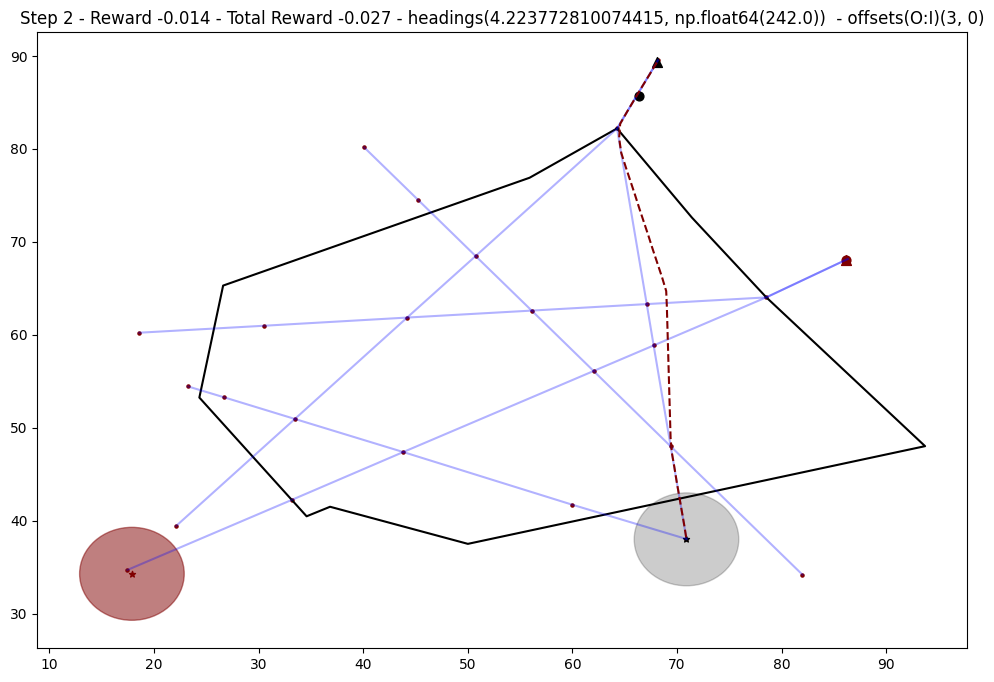

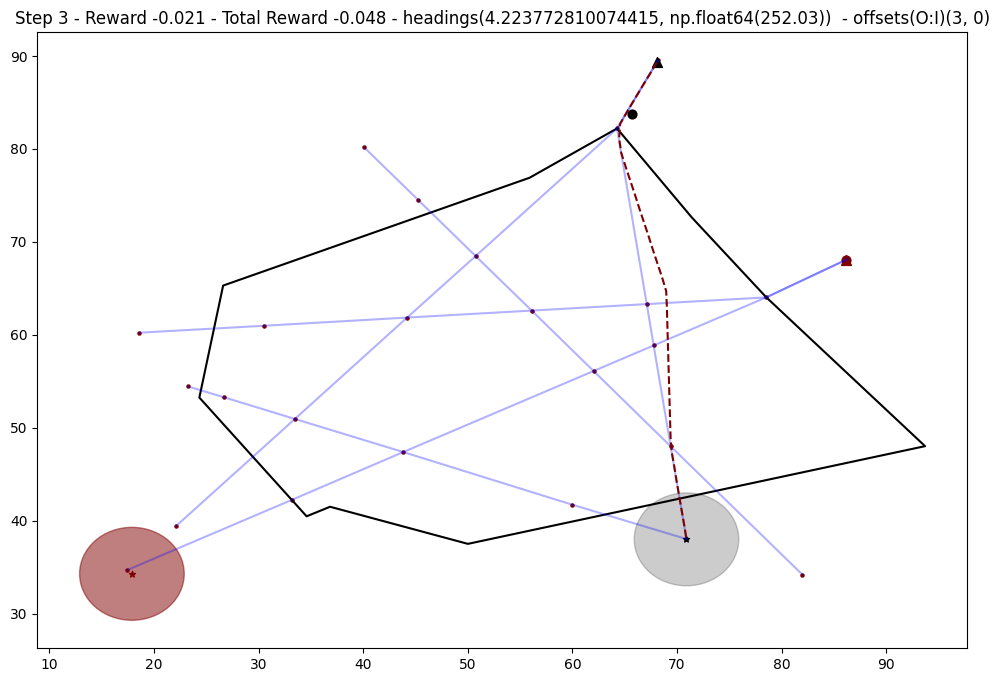

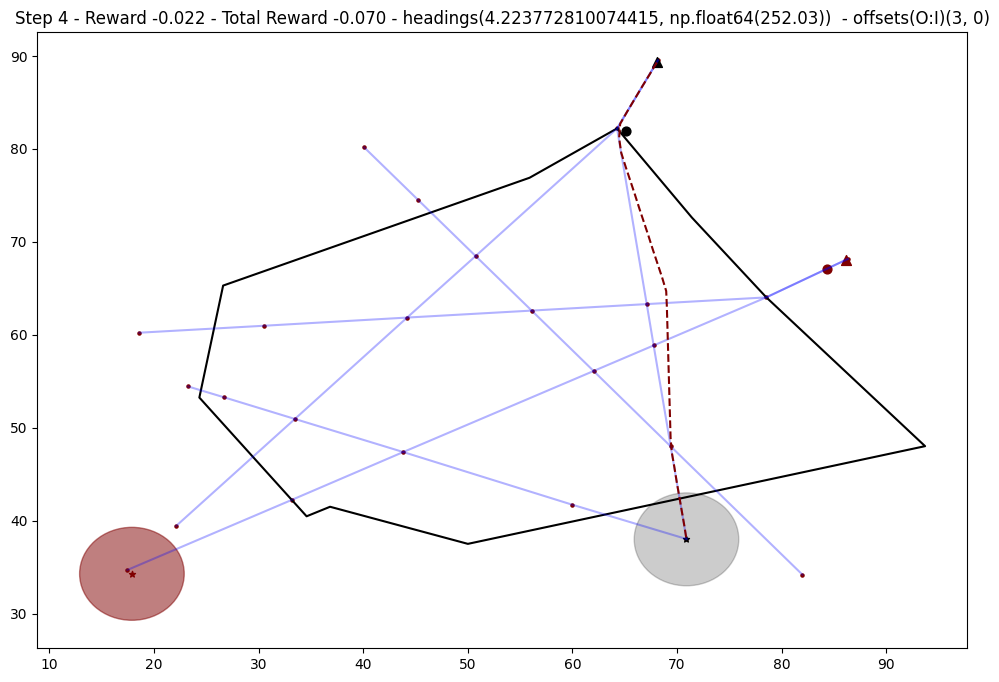

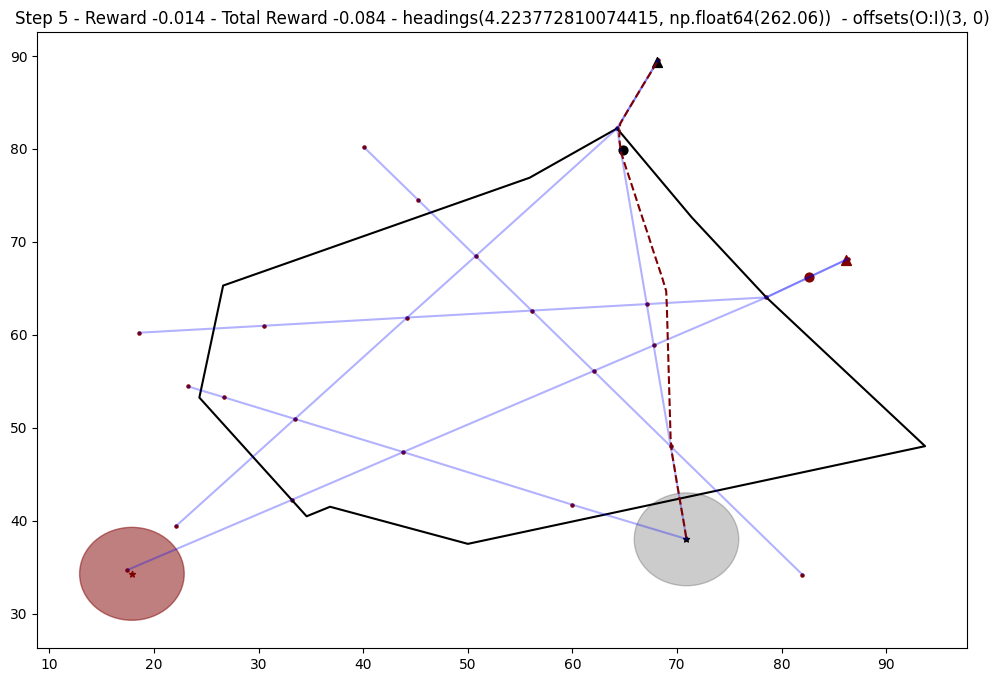

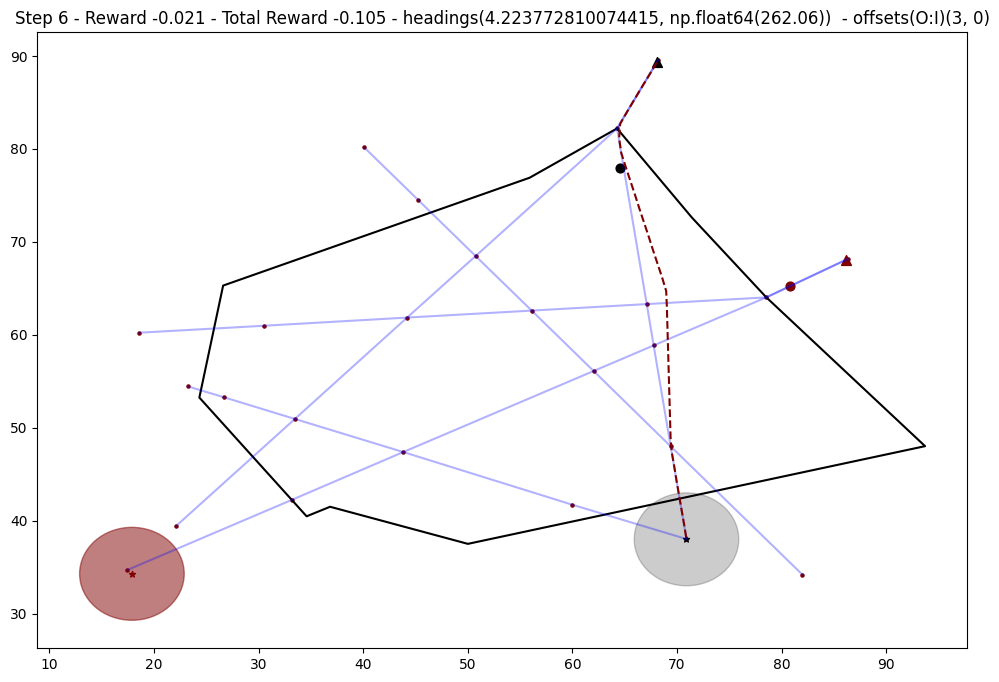

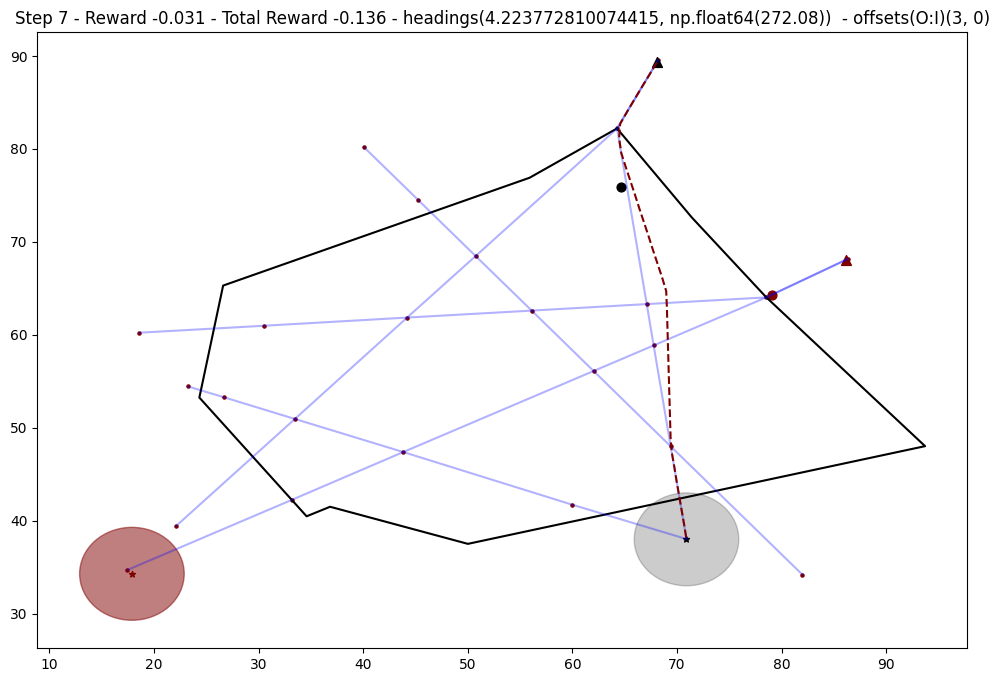

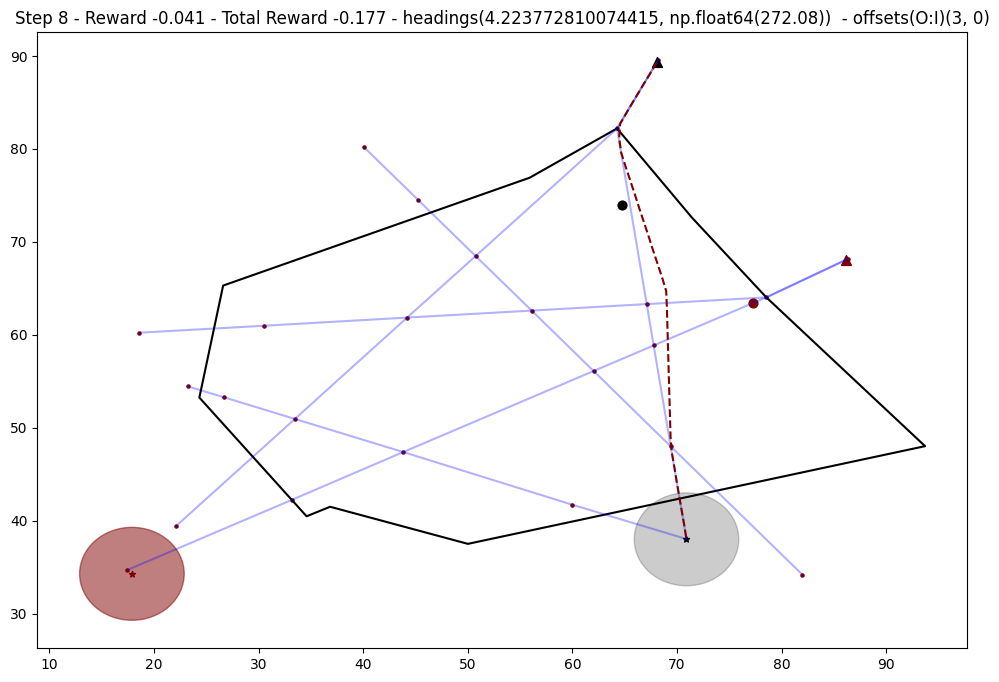

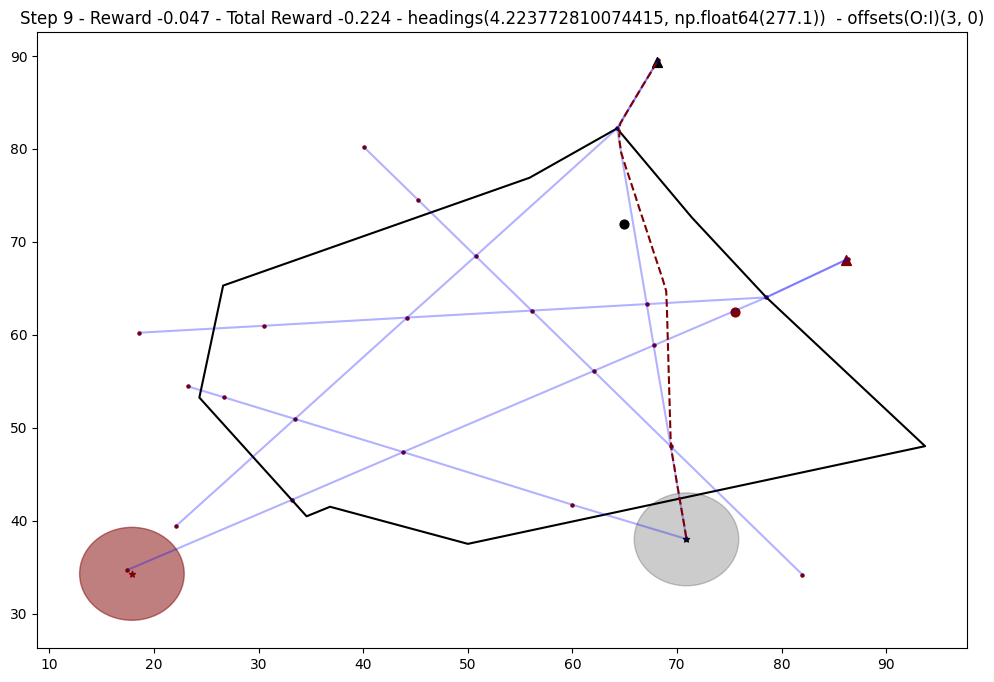

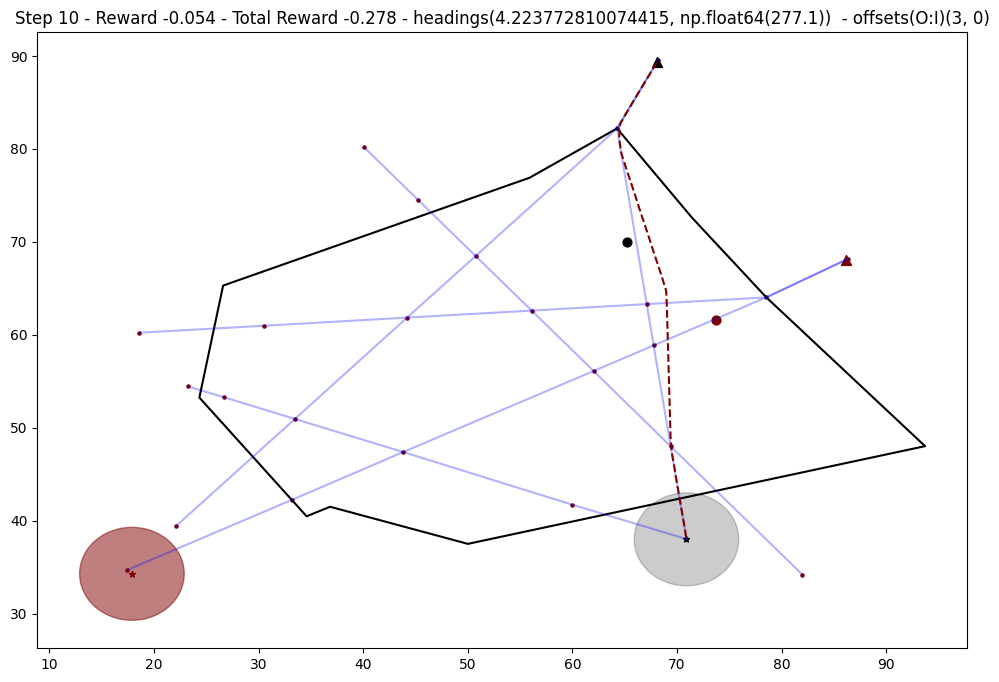

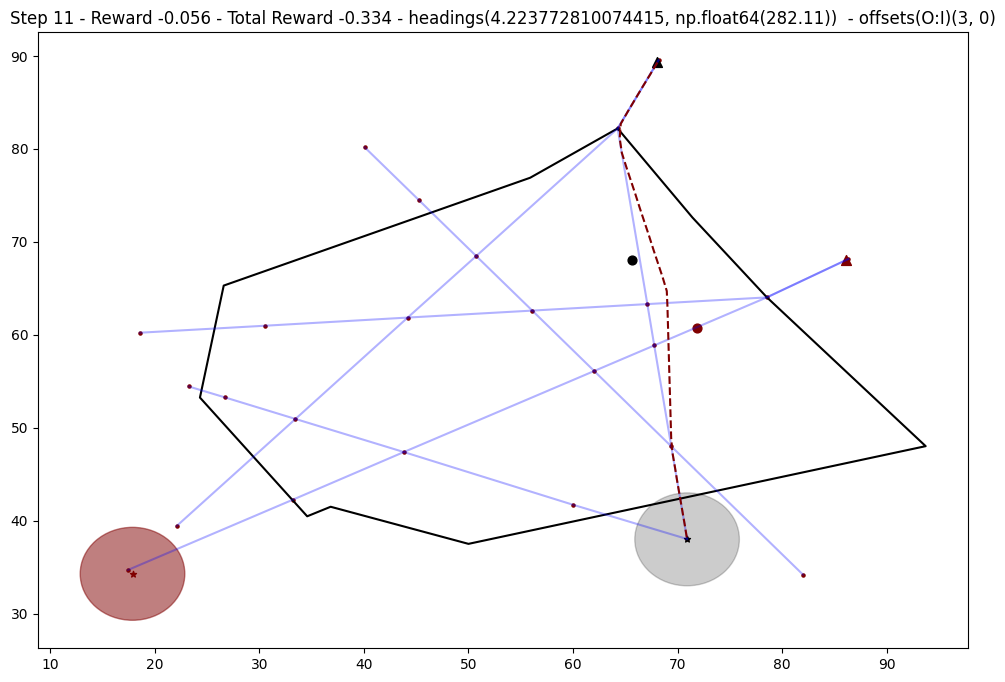

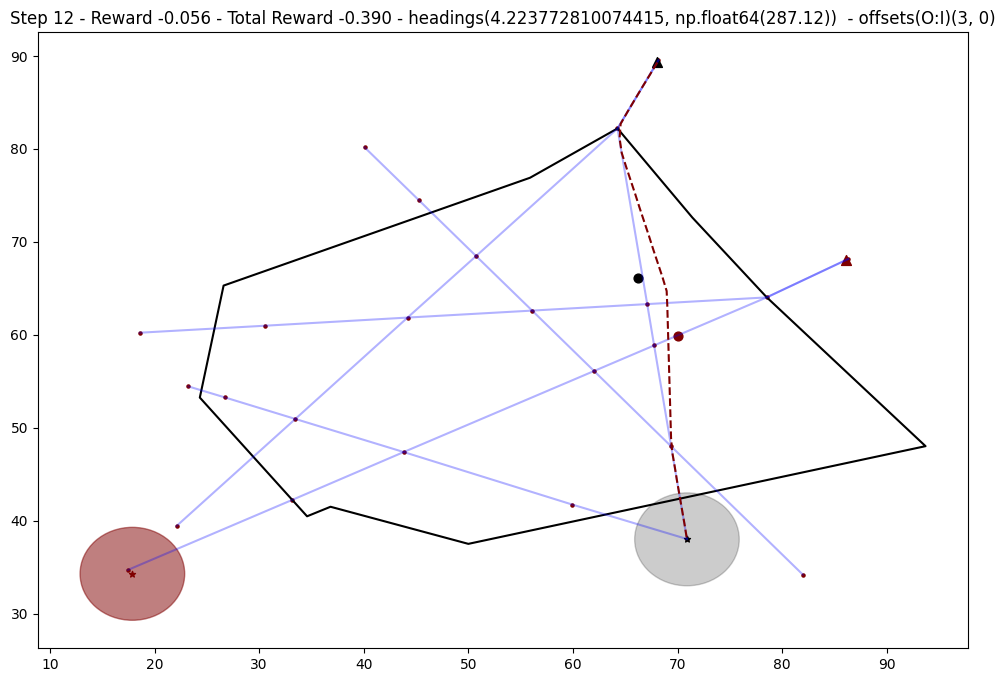

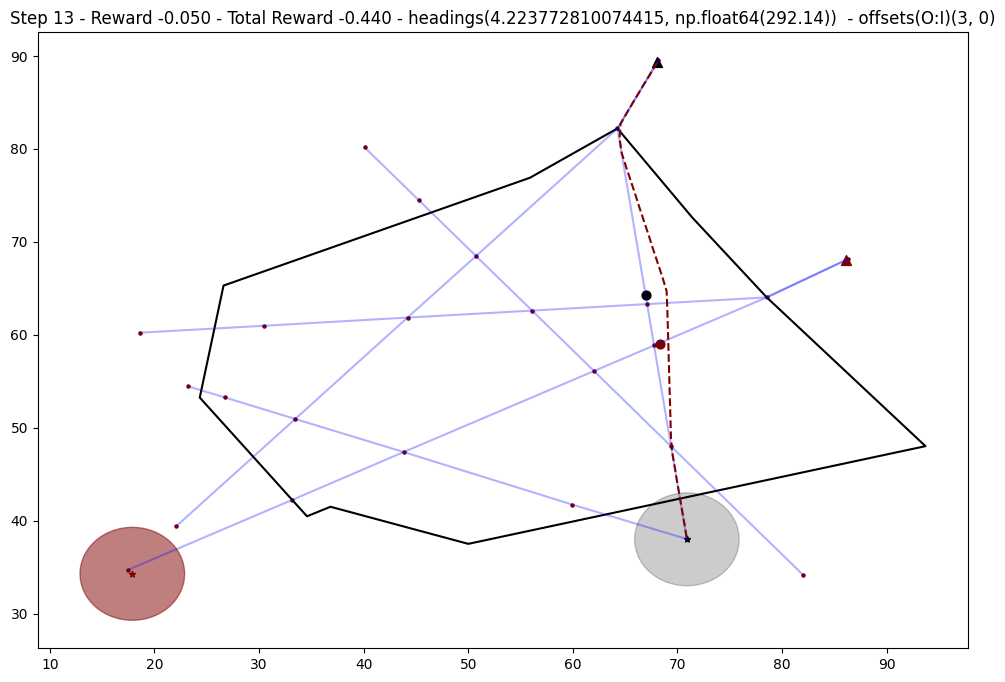

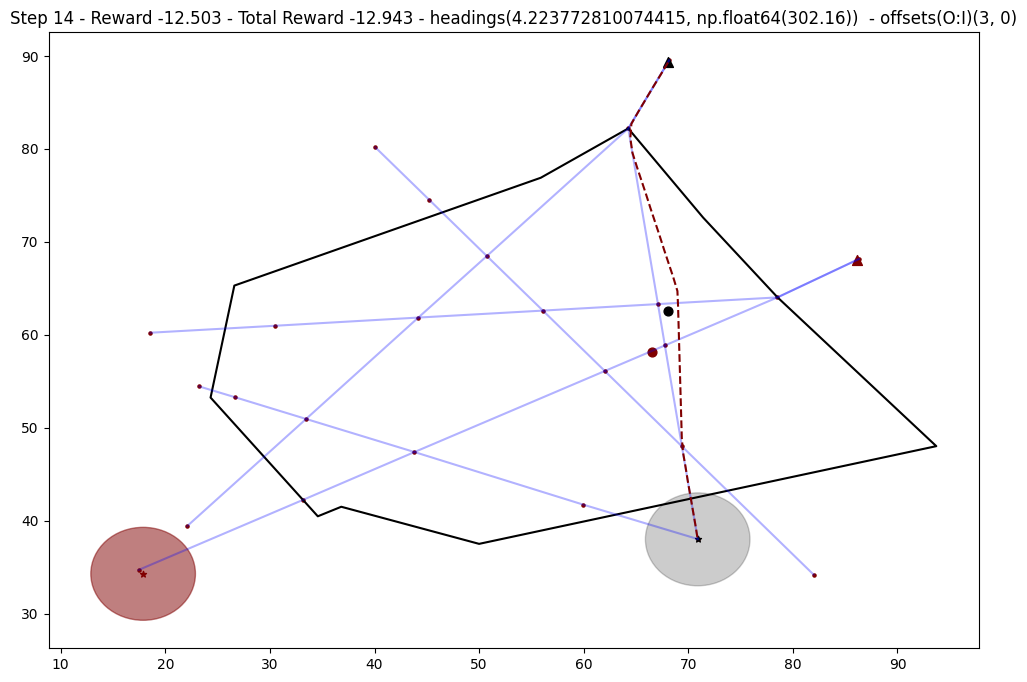

In [ ]:
import glob
from PIL import Image

# --- instantiate the agent exactly as in training ---
env        = StructuredEnv()
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.n
ppo_agent  = PPO(state_dim, action_dim, lr_actor=3e-4, lr_critic=1e-3,
                 gamma=0.99, K_epochs=10, eps_clip=0.2)

# 1) Load the best model we saved during training
best_path = "/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v3/best_model.pth"
ppo_agent.load(best_path)
print("Loaded checkpoint from", best_path)

# 2) Prepare the same env
env = StructuredEnv()
name = "env_PPO_evaluation_11th_august_2025"  # Name for saving images and GIFs

# 3) Rollout loop with rendering to PNGs
obs, _ = env.reset()
for step in range(env.MAX_STEP):
    # Convert obs → tensor on device, sample action deterministically
    state_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
    action, _, _ = ppo_agent.policy_old.act(state_tensor)

    # Step the env
    obs, reward, term, trunc, _ = env.step(action.cpu().item())
    done = term or trunc

    # Render the frame (saved under ./images2/)
    env.render(show=False, folder="./images2/")

    if done:
        break

# 4) Collect PNGs and build a GIF
fp_in  = "./images2/image_*.png"
fp_out = f"./images2/{name}.gif"

imgs = []
for f in sorted(glob.glob(fp_in)):
    imgs.append(Image.open(f))
    os.remove(f)

# Save the animated GIF
imgs[0].save(
    fp=fp_out,
    format="GIF",
    append_images=imgs[1:],
    save_all=True,
    duration=len(imgs)*10,
    loop=0
)

print("Saved evaluation GIF to", fp_out)